# Xây dựng mô hình chấm điểm tín dụng bằng hồi quy logistic và Weight of Evidence

Notebook này trình bày cơ sở lý thuyết và quy trình thực nghiệm để xây dựng mô hình chấm điểm tín dụng có khả năng dự báo, giải thích và chuyển đổi thành bảng điểm tín dụng.

# 1. Giới thiệu

Chấm điểm tín dụng (*credit scoring*) là quá trình sử dụng các phương pháp thống kê hoặc học máy để đánh giá mức độ tín nhiệm và rủi ro tín dụng của khách hàng. Trong thực tế, các tổ chức tài chính sử dụng mô hình chấm điểm tín dụng để hỗ trợ các quyết định như phê duyệt khoản vay, xác định hạn mức tín dụng và quản lý rủi ro của danh mục khách hàng.

Một trong những bài toán phổ biến trong chấm điểm tín dụng là phân loại khách hàng thành hai nhóm: khách hàng tốt (*Good*) và khách hàng xấu (*Bad*). Khách hàng tốt thường được hiểu là những khách hàng có khả năng thực hiện đầy đủ nghĩa vụ thanh toán, trong khi khách hàng xấu là những khách hàng có nguy cơ trễ hạn nghiêm trọng hoặc không hoàn thành nghĩa vụ tín dụng.

Trong bài phân tích này, hồi quy logistic được sử dụng để xây dựng mô hình chấm điểm tín dụng. Đây là phương pháp phù hợp với bài toán phân loại nhị phân và cho phép ước lượng xác suất một khách hàng thuộc nhóm tín dụng xấu dựa trên các đặc trưng quan sát được.

Bên cạnh hồi quy logistic, quy trình xây dựng mô hình còn sử dụng một số kỹ thuật thường gặp trong các mô hình bảng điểm tín dụng truyền thống, bao gồm phân nhóm biến (*binning*), Weight of Evidence, Information Value và chuyển đổi kết quả của mô hình thành điểm tín dụng. Các khái niệm và phương pháp này được trình bày chi tiết trong những phần tiếp theo.

Mục tiêu của bài phân tích là xây dựng một quy trình chấm điểm tín dụng có khả năng dự báo rủi ro của khách hàng, đồng thời bảo đảm tính dễ hiểu và khả năng giải thích của mô hình.

## 1.1. Cấu trúc bài phân tích

Bài phân tích được tổ chức thành các phần chính sau:

1. Trình bày các khái niệm cơ bản về WOE, IV và điểm tín dụng.
2. Khám phá và tiền xử lý dữ liệu.
3. Phân nhóm các biến đầu vào.
4. Tính toán WOE và IV.
5. Lựa chọn biến và xây dựng mô hình hồi quy logistic.
6. Chuyển đổi mô hình thành bảng điểm tín dụng.
7. Đánh giá hiệu quả và tính ổn định của mô hình.

## 1.2. Quy ước biến mục tiêu

Biến `loan_status` được sử dụng làm biến mục tiêu. Trước khi xây dựng mô hình, cần xác nhận ý nghĩa của từng giá trị trong biến này từ tài liệu mô tả dữ liệu.

- `loan_status = 1`: khách hàng xấu (*Bad*);
- `loan_status = 0`: khách hàng tốt (*Good*).

Xác suất được dự báo bởi mô hình là:

$$
p=P(Y=1\mid X),
$$

tức là xác suất khách hàng thuộc nhóm tín dụng xấu khi đã biết các đặc trưng $X$.

# 2. Các khái niệm cơ bản

## 2.1. Weight of Evidence (WOE)

**Weight of Evidence**, viết tắt là **WOE**, là một phương pháp biến đổi biến thường được sử dụng trong xây dựng mô hình chấm điểm tín dụng. Phương pháp này được áp dụng khi biến mục tiêu là biến nhị phân, chẳng hạn như:

- khách hàng tốt (*Good*);
- khách hàng xấu (*Bad*).

WOE phản ánh mức độ khác biệt giữa phân phối của khách hàng tốt và phân phối của khách hàng xấu trong từng nhóm của một biến dự báo.

Trước khi tính WOE, biến dự báo cần được chia thành các nhóm, còn gọi là các *bin*. Đối với biến liên tục, mỗi nhóm thường tương ứng với một khoảng giá trị. Đối với biến phân loại, mỗi nhóm có thể chứa một hoặc nhiều mức của biến.

Trong bài phân tích này, WOE của nhóm thứ $j$ được định nghĩa như sau:

$$
WOE_j
=
\ln\left(
\frac{\operatorname{DistGood}_j}
{\operatorname{DistBad}_j}
\right),
$$

trong đó:

$$
\operatorname{DistGood}_j
=
\frac{G_j}{G},
$$

và

$$
\operatorname{DistBad}_j
=
\frac{B_j}{B}.
$$

Các ký hiệu được hiểu như sau:

- $G_j$: số khách hàng tốt thuộc nhóm $j$;
- $B_j$: số khách hàng xấu thuộc nhóm $j$;
- $G$: tổng số khách hàng tốt trong tập dữ liệu;
- $B$: tổng số khách hàng xấu trong tập dữ liệu.

Do đó, công thức WOE có thể được viết trực tiếp dưới dạng:

$$
WOE_j
=
\ln\left(
\frac{G_j/G}
{B_j/B}
\right).
$$

### Ví dụ

Giả sử trong toàn bộ tập dữ liệu có:

- 100 khách hàng tốt;
- 50 khách hàng xấu.

Xét một nhóm $A$ có:

- 20 khách hàng tốt;
- 5 khách hàng xấu.

Tỷ trọng khách hàng tốt của nhóm $A$ trong toàn bộ khách hàng tốt là:

$$
\operatorname{DistGood}_A
=
\frac{20}{100}
=
0.20.
$$

Tỷ trọng khách hàng xấu của nhóm $A$ trong toàn bộ khách hàng xấu là:

$$
\operatorname{DistBad}_A
=
\frac{5}{50}
=
0.10.
$$

WOE của nhóm $A$ được tính như sau:

$$
WOE_A
=
\ln\left(
\frac{0.20}{0.10}
\right)
=
\ln(2)
\approx 0.693.
$$

WOE của nhóm $A$ mang giá trị dương, cho thấy nhóm này chiếm tỷ trọng lớn hơn trong phân phối của khách hàng tốt so với trong phân phối của khách hàng xấu.

### Diễn giải WOE

Theo quy ước:

$$
WOE_j
=
\ln\left(
\frac{\operatorname{DistGood}_j}
{\operatorname{DistBad}_j}
\right),
$$

giá trị WOE được diễn giải như sau:

- $WOE_j>0$: nhóm $j$ có tỷ trọng tương đối cao hơn trong phân phối của khách hàng tốt;
- $WOE_j<0$: nhóm $j$ có tỷ trọng tương đối cao hơn trong phân phối của khách hàng xấu;
- $WOE_j=0$: tỷ trọng của nhóm $j$ trong toàn bộ khách hàng tốt bằng tỷ trọng của nhóm đó trong toàn bộ khách hàng xấu;
- giá trị tuyệt đối của WOE càng lớn thì sự khác biệt giữa hai phân phối càng rõ ràng.

Tuy nhiên, WOE có giá trị tuyệt đối lớn ở một nhóm có quá ít quan sát có thể không ổn định. Vì vậy, việc diễn giải WOE cần được thực hiện đồng thời với việc kiểm tra kích thước và tỷ lệ quan sát của từng nhóm.

Một số tài liệu hoặc thư viện phần mềm sử dụng quy ước ngược lại:

$$
WOE_j
=
\ln\left(
\frac{\operatorname{DistBad}_j}
{\operatorname{DistGood}_j}
\right).
$$

Khi sử dụng quy ước ngược, dấu của WOE cũng thay đổi. Vì vậy, cần duy trì cùng một quy ước trong toàn bộ quá trình xây dựng mô hình.

### Vai trò của WOE trong chấm điểm tín dụng

Phép biến đổi WOE mang lại một số lợi ích:

1. Biểu diễn mối quan hệ giữa biến dự báo và khả năng khách hàng thuộc nhóm Good hoặc Bad.
2. Chuyển đổi biến phân loại thành biến số để có thể đưa vào hồi quy logistic.
3. Cho phép biểu diễn quan hệ phi tuyến thông qua quá trình chia nhóm.
4. Giảm ảnh hưởng của giá trị ngoại lai do các quan sát trong cùng một nhóm được gán chung một giá trị WOE.
5. Cho phép xem giá trị thiếu như một nhóm riêng và đánh giá mức độ rủi ro của nhóm đó.
6. Hỗ trợ xây dựng bảng điểm tín dụng có khả năng giải thích.

### Hạn chế của WOE

WOE cũng có một số hạn chế:

1. Quá trình chia nhóm có thể làm mất một phần thông tin của biến ban đầu.
2. Kết quả WOE phụ thuộc nhiều vào cách xác định các nhóm.
3. Chia quá nhiều nhóm có thể làm mô hình quá khớp với dữ liệu huấn luyện.
4. Chia quá ít nhóm có thể che khuất các khác biệt quan trọng trong dữ liệu.
5. Biến sau khi chuyển đổi WOE thay đổi theo từng nhóm nên có dạng bậc thang thay vì liên tục.
6. Nếu một nhóm không có khách hàng Good hoặc không có khách hàng Bad, công thức WOE sẽ chứa phép chia cho 0 và cần sử dụng phương pháp hiệu chỉnh phù hợp.

### Lưu ý về rò rỉ dữ liệu

Ranh giới các nhóm và giá trị WOE phải được xác định chỉ từ tập huấn luyện. Sau đó, các ranh giới và giá trị WOE đã học được mới được áp dụng nguyên trạng cho tập validation và tập kiểm tra.

Việc sử dụng toàn bộ dữ liệu để xây dựng nhóm hoặc tính WOE trước khi chia tập có thể gây ra rò rỉ dữ liệu (*data leakage*) và làm cho kết quả đánh giá mô hình trở nên lạc quan hơn thực tế.

## 2.2. Information Value (IV)

**Information Value**, viết tắt là **IV**, là một chỉ số thường được sử dụng để đánh giá khả năng phân biệt đơn biến giữa khách hàng tốt và khách hàng xấu của một biến dự báo.

IV được tính dựa trên kết quả chia nhóm và các giá trị WOE. Đối với nhóm thứ $j$, giá trị IV thành phần được xác định bởi:

$$
IV_j
=
\left(
\operatorname{DistGood}_j
-
\operatorname{DistBad}_j
\right)WOE_j.
$$

IV của toàn bộ biến được tính bằng tổng IV thành phần của tất cả các nhóm:

$$
IV
=
\sum_{j=1}^{m}
\left(
\operatorname{DistGood}_j
-
\operatorname{DistBad}_j
\right)WOE_j,
$$

trong đó $m$ là số nhóm của biến.

Do:

$$
\operatorname{DistGood}_j=\frac{G_j}{G},
\qquad
\operatorname{DistBad}_j=\frac{B_j}{B},
$$

và:

$$
WOE_j
=
\ln\left(
\frac{\operatorname{DistGood}_j}
{\operatorname{DistBad}_j}
\right),
$$

công thức IV có thể được viết dưới dạng:

$$
IV
=
\sum_{j=1}^{m}
\left(
\frac{G_j}{G}
-
\frac{B_j}{B}
\right)
\ln\left(
\frac{G_j/G}
{B_j/B}
\right).
$$

### Ví dụ

Tiếp tục xét nhóm $A$ trong ví dụ trước:

$$
\operatorname{DistGood}_A=0.20,
$$

$$
\operatorname{DistBad}_A=0.10,
$$

và:

$$
WOE_A=\ln(2)\approx0.693.
$$

Khi đó, IV thành phần của nhóm $A$ là:

$$
IV_A
=
(0.20-0.10)\times0.693
=
0.0693.
$$

IV của toàn bộ biến được tính bằng cách cộng IV thành phần của tất cả các nhóm.

### Diễn giải IV

Một quy tắc kinh nghiệm thường được sử dụng để diễn giải IV như sau:

| Giá trị IV | Khả năng phân biệt đơn biến |
|---|---|
| $IV<0.02$ | Hầu như không có khả năng phân biệt |
| $0.02\leq IV<0.10$ | Yếu |
| $0.10\leq IV<0.30$ | Trung bình |
| $0.30\leq IV<0.50$ | Mạnh |
| $IV\geq0.50$ | Rất mạnh, cần kiểm tra thêm |

Các ngưỡng trên chỉ mang tính kinh nghiệm và không phải là tiêu chuẩn thống kê tuyệt đối.

Một biến có IV rất cao không phải lúc nào cũng là một biến dự báo phù hợp. Cần kiểm tra xem biến có chứa thông tin từ tương lai, thông tin xuất hiện sau khi khách hàng đã vỡ nợ hoặc thông tin có quan hệ trực tiếp với cách định nghĩa biến mục tiêu hay không. Những trường hợp này có thể dẫn đến rò rỉ dữ liệu.

### Vai trò của IV trong lựa chọn biến

IV thường được sử dụng như một công cụ sàng lọc ban đầu nhằm:

1. Loại bỏ những biến gần như không có khả năng phân biệt Good và Bad.
2. Xếp hạng sơ bộ các biến theo khả năng phân biệt đơn biến.
3. Hỗ trợ lựa chọn các biến tiềm năng trước khi xây dựng mô hình.

Tuy nhiên, IV chỉ đánh giá từng biến riêng lẻ và không xem xét:

- mối tương quan giữa các biến;
- hiện tượng đa cộng tuyến;
- tác động đồng thời của nhiều biến;
- mức độ ổn định của biến theo thời gian;
- ý nghĩa nghiệp vụ của biến.

Vì vậy, việc lựa chọn biến không nên chỉ dựa vào IV mà cần kết hợp thêm các tiêu chí thống kê, nghiệp vụ và khả năng giải thích của mô hình.

Tương tự WOE, IV và quyết định lựa chọn biến phải được xác định trên tập huấn luyện. Không được sử dụng biến mục tiêu của tập kiểm tra để tính IV hoặc lựa chọn biến.

## 2.3. Điểm tín dụng và bảng điểm tín dụng

Sau khi mô hình hồi quy logistic được xây dựng, kết quả dự báo có thể được chuyển đổi thành một thang điểm tín dụng. Mục đích của quá trình này là biểu diễn mức độ rủi ro của khách hàng dưới dạng điểm số dễ sử dụng và dễ diễn giải.

Giả sử:

$$
p=P(Y=1\mid X)
$$

là xác suất khách hàng thuộc nhóm tín dụng xấu. Mô hình hồi quy logistic được biểu diễn bởi:

$$
\ln\left(\frac{p}{1-p}\right)
=
\beta_0+\sum_{i=1}^{k}\beta_iX_i.
$$

Trong đó:

$$
\frac{p}{1-p}
$$

là odds của sự kiện khách hàng xấu.

Trong thực tế, điểm tín dụng thường được thiết kế sao cho:

$$
\text{Điểm cao}
\quad\Longleftrightarrow\quad
\text{Rủi ro thấp}.
$$

Do đó, điểm tín dụng có thể được xác định bằng một phép biến đổi tuyến tính từ log-odds của khách hàng xấu:

$$
Score
=
A-B\ln\left(\frac{p}{1-p}\right),
$$

trong đó:

- $A$ là hằng số xác định vị trí của thang điểm;
- $B$ là hệ số xác định độ dốc của thang điểm;
- $p$ là xác suất khách hàng thuộc nhóm xấu.

Dấu trừ bảo đảm rằng khi xác suất khách hàng xấu tăng thì điểm tín dụng giảm.

### Mối liên hệ giữa hồi quy logistic và điểm tín dụng

Do:

$$
\ln\left(\frac{p}{1-p}\right)
=
\beta_0+\sum_{i=1}^{k}\beta_iX_i,
$$

nên điểm tín dụng có thể được viết thành:

$$
Score
=
A
-
B\left(
\beta_0+\sum_{i=1}^{k}\beta_iX_i
\right).
$$

Khi các biến đầu vào đã được chuyển đổi bằng WOE:

$$
Score
=
A
-
B\left(
\beta_0+\sum_{i=1}^{k}\beta_iWOE_i
\right).
$$

Công thức trên thể hiện trực tiếp mối liên hệ giữa phép biến đổi WOE, mô hình hồi quy logistic và hệ thống điểm tín dụng.

### Base score và PDO

Thang điểm tín dụng thường được xác định thông qua hai đại lượng:

- **Base score**: mức điểm được gán cho một giá trị odds tham chiếu;
- **Points to Double the Odds (PDO)**: số điểm tăng thêm khi odds Good so với Bad tăng gấp đôi.

Giả sử odds Good so với Bad được định nghĩa là:

$$
Odds
=
\frac{1-p}{p}.
$$

Khi đó, điểm tín dụng có thể được viết dưới dạng:

$$
Score
=
Offset+Factor\ln(Odds).
$$

Hệ số $Factor$ được xác định bởi:

$$
Factor
=
\frac{PDO}{\ln(2)}.
$$

Nếu điểm cơ sở là $Score_0$ tại mức odds cơ sở $Odds_0$, thì:

$$
Offset
=
Score_0-Factor\ln(Odds_0).
$$

Do đó:

$$
Score
=
Score_0
+
\frac{PDO}{\ln(2)}
\ln\left(
\frac{Odds}{Odds_0}
\right).
$$

Công thức này bảo đảm rằng khi odds Good so với Bad tăng gấp đôi thì điểm tín dụng tăng đúng bằng PDO.

### Ví dụ

Giả sử hệ thống điểm được thiết kế với:

- điểm cơ sở bằng 600;
- odds Good so với Bad tại điểm cơ sở là $50:1$;
- PDO bằng 20.

Khi đó:

$$
Factor
=
\frac{20}{\ln(2)}
\approx28.85.
$$

Nếu odds của một khách hàng tăng từ $50:1$ lên $100:1$, tức là tăng gấp đôi, điểm tín dụng tăng từ 600 lên:

$$
600+20=620.
$$

Ngược lại, nếu odds giảm từ $50:1$ xuống $25:1$, điểm tín dụng giảm từ 600 xuống:

$$
600-20=580.
$$

### Bảng điểm tín dụng

Trong bảng điểm tín dụng, mỗi nhóm của mỗi biến được gán một số điểm cụ thể. Điểm tổng của khách hàng được tính bằng tổng điểm từ các nhóm mà khách hàng thuộc vào:

$$
Score_{\text{total}}
=
Score_{\text{base}}
+
\sum_{i=1}^{k}Score_i.
$$

Bảng dưới đây chỉ nhằm minh họa cách biểu diễn điểm; các giá trị chưa được suy ra từ một mô hình hồi quy logistic cụ thể.

| Nhóm tuổi | Điểm minh họa |
|---|---:|
| 18–25 | -30 |
| 26–35 | -10 |
| 36–50 | 15 |
| Trên 50 | 25 |

Một khách hàng 22 tuổi thuộc nhóm 18–25 và nhận $-30$ điểm minh họa từ biến tuổi. Điểm này được cộng với điểm của các biến khác để tạo thành điểm tín dụng tổng thể.

Điểm tín dụng là một phép biến đổi từ kết quả của mô hình và không nhất thiết tuân theo phân phối chuẩn.

# 3. Quy trình xây dựng mô hình

Quy trình xây dựng mô hình trong notebook được tổ chức như sau:

$$
\text{Chia tập dữ liệu}
\rightarrow
\text{Khám phá và tiền xử lý dữ liệu}
\rightarrow
\text{Chia nhóm trên tập huấn luyện}
\rightarrow
\text{Tính WOE và IV}
\rightarrow
\text{Lựa chọn biến}
\rightarrow
\text{Hồi quy logistic}
\rightarrow
\text{Đánh giá mô hình}
\rightarrow
\text{Chuyển đổi điểm}
\rightarrow
\text{Đánh giá tính ổn định}.
$$

Ranh giới bin và giá trị WOE được học từ tập huấn luyện, sau đó được áp dụng nguyên trạng cho tập validation và tập kiểm tra.

# 4. Chuẩn bị dữ liệu

## 4.1. Thiết lập môi trường

In [2]:
%pip install -q kagglehub optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 26.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


In [3]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from optbinning import OptimalBinning
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split

## 4.2. Tải và đọc dữ liệu

In [4]:
# Tải phiên bản mới nhất của bộ dữ liệu từ Kaggle.
dataset_path = Path(
    kagglehub.dataset_download("omarc4gk/credit-risk-dataset")
)

# Tìm tệp CSV trong thư mục vừa tải xuống.
csv_files = list(dataset_path.rglob("credit_risk_dataset.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Không tìm thấy tệp credit_risk_dataset.csv trong thư mục dữ liệu."
    )

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print(f"Đường dẫn dữ liệu: {csv_path}")
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột")

df.head()

100%|██████████| 368k/368k [00:00<00:00, 72.9MB/s]

Extracting files...
Đường dẫn dữ liệu: /root/.cache/kagglehub/datasets/omarc4gk/credit-risk-dataset/versions/1/credit_risk_dataset.csv
Kích thước dữ liệu: 32,581 dòng × 12 cột


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 4.3. Kiểm tra biến mục tiêu

Trước khi gán nhãn Good và Bad, cần kiểm tra các giá trị xuất hiện trong biến `loan_status` và đối chiếu với tài liệu mô tả dữ liệu.

In [5]:
target_col = "loan_status"

if target_col not in df.columns:
    raise KeyError(f"Không tìm thấy biến mục tiêu: {target_col}")

target_summary = pd.DataFrame(
    {
        "Số quan sát": df[target_col].value_counts(dropna=False),
        "Tỷ lệ": df[target_col].value_counts(
            dropna=False, normalize=True
        ),
    }
).sort_index()

target_summary

,Số quan sát,Tỷ lệ
loan_status,,
0,25473,0.781836
1,7108,0.218164


# 5. Khám phá dữ liệu

## 5.1. Nguồn và mô tả tập dữ liệu

Bộ dữ liệu được sử dụng trong nghiên cứu là **Credit Risk Dataset**, được cung
cấp công khai trên nền tảng Kaggle. Dữ liệu được tải trực tiếp vào Google Colab
thông qua thư viện `kagglehub`.

Tập dữ liệu chứa các thông tin liên quan đến đặc điểm cá nhân, điều kiện tài
chính, đặc điểm khoản vay và lịch sử tín dụng của khách hàng. Biến
`loan_status` được sử dụng làm biến mục tiêu trong bài toán phân loại rủi ro tín
dụng, với quy ước:

- `loan_status = 0`: khoản vay không vỡ nợ (*non-default*);
- `loan_status = 1`: khoản vay vỡ nợ (*default*).

Mục tiêu của quá trình phân tích là sử dụng các biến dự báo để ước lượng xác suất
khách hàng thuộc nhóm vỡ nợ.

In [6]:
variable_description = {
    "person_age": {
        "type": "Định lượng",
        "description": "Tuổi của khách hàng, tính theo năm."
    },
    "person_income": {
        "type": "Định lượng",
        "description": (
            "Thu nhập hằng năm của khách hàng, "
            "giả định đơn vị là đô la Mỹ."
        )
    },
    "person_home_ownership": {
        "type": "Định tính",
        "description": (
            "Hình thức sở hữu nơi ở của khách hàng, chẳng hạn "
            "RENT, OWN, MORTGAGE hoặc OTHER."
        )
    },
    "person_emp_length": {
        "type": "Định lượng",
        "description": (
            "Thời gian làm việc của khách hàng, tính theo năm."
        )
    },
    "loan_intent": {
        "type": "Định tính",
        "description": "Mục đích sử dụng khoản vay."
    },
    "loan_grade": {
        "type": "Thứ bậc",
        "description": (
            "Xếp hạng tín dụng của khoản vay từ A đến G; "
            "hạng A biểu thị mức rủi ro thấp nhất và "
            "hạng G biểu thị mức rủi ro cao nhất."
        )
    },
    "loan_amnt": {
        "type": "Định lượng",
        "description": "Số tiền khách hàng đề nghị vay."
    },
    "loan_int_rate": {
        "type": "Định lượng",
        "description": "Lãi suất của khoản vay."
    },
    "loan_status": {
        "type": "Nhị phân",
        "description": (
            "Trạng thái khoản vay; 0 là không vỡ nợ và "
            "1 là vỡ nợ."
        )
    },
    "loan_percent_income": {
        "type": "Định lượng",
        "description": (
            "Tỷ lệ giữa số tiền vay và thu nhập hằng năm "
            "của khách hàng."
        )
    },
    "cb_person_default_on_file": {
        "type": "Nhị phân",
        "description": (
            "Thông tin lịch sử vỡ nợ trong hồ sơ tín dụng; "
            "Y là từng vỡ nợ và N là chưa từng vỡ nợ."
        )
    },
    "cb_person_cred_hist_length": {
        "type": "Định lượng",
        "description": (
            "Độ dài lịch sử tín dụng của khách hàng, "
            "tính theo năm."
        )
    }
}

data_dictionary = pd.DataFrame([
    {
        "Biến": variable,
        "Loại biến": information["type"],
        "Mô tả": information["description"]
    }
    for variable, information in variable_description.items()
])

display(data_dictionary)

,Biến,Loại biến,Mô tả
0,person_age,Định lượng,"Tuổi của khách hàng, tính theo năm."
1,person_income,Định lượng,"Thu nhập hằng năm của khách hàng, giả định đơn..."
2,person_home_ownership,Định tính,"Hình thức sở hữu nơi ở của khách hàng, chẳng h..."
3,person_emp_length,Định lượng,"Thời gian làm việc của khách hàng, tính theo năm."
4,loan_intent,Định tính,Mục đích sử dụng khoản vay.
5,loan_grade,Thứ bậc,Xếp hạng tín dụng của khoản vay từ A đến G; hạ...
6,loan_amnt,Định lượng,Số tiền khách hàng đề nghị vay.
7,loan_int_rate,Định lượng,Lãi suất của khoản vay.
8,loan_status,Nhị phân,Trạng thái khoản vay; 0 là không vỡ nợ và 1 là...
9,loan_percent_income,Định lượng,Tỷ lệ giữa số tiền vay và thu nhập hằng năm củ...


### Phân loại các biến

Các biến trong tập dữ liệu có thể được chia thành bốn nhóm chính:

1. **Đặc điểm cá nhân:** `person_age`, `person_income`,
   `person_home_ownership` và `person_emp_length`.

2. **Đặc điểm khoản vay:** `loan_intent`, `loan_grade`, `loan_amnt`,
   `loan_int_rate` và `loan_percent_income`.

3. **Lịch sử tín dụng:** `cb_person_default_on_file` và
   `cb_person_cred_hist_length`.

4. **Biến mục tiêu:** `loan_status`.

Trong đó, `loan_status` là biến nhị phân được sử dụng để xác định khách hàng có
vỡ nợ hay không. Các biến còn lại được xem là những biến dự báo tiềm năng cho
mô hình chấm điểm tín dụng.

In [8]:
print(f"Số quan sát: {df.shape[0]:,}")
print(f"Số biến: {df.shape[1]}")

dataset_overview = pd.DataFrame({
    "Kiểu dữ liệu": df.dtypes.astype(str),
    "Số giá trị khác nhau": df.nunique(dropna=True),
    "Số giá trị thiếu": df.isna().sum(),
    "Tỷ lệ thiếu (%)": df.isna().mean().mul(100).round(2)
})

dataset_overview.index.name = "Biến"

display(dataset_overview)

Số quan sát: 32,581
Số biến: 12


,Kiểu dữ liệu,Số giá trị khác nhau,Số giá trị thiếu,Tỷ lệ thiếu (%)
Biến,,,,
person_age,int64,58,0,0.00
person_income,int64,4295,0,0.00
person_home_ownership,object,4,0,0.00
person_emp_length,float64,36,895,2.75
loan_intent,object,6,0,0.00
loan_grade,object,7,0,0.00
loan_amnt,int64,753,0,0.00
loan_int_rate,float64,348,3116,9.56
loan_status,int64,2,0,0.00


## 5.2. Phân tích đơn biến




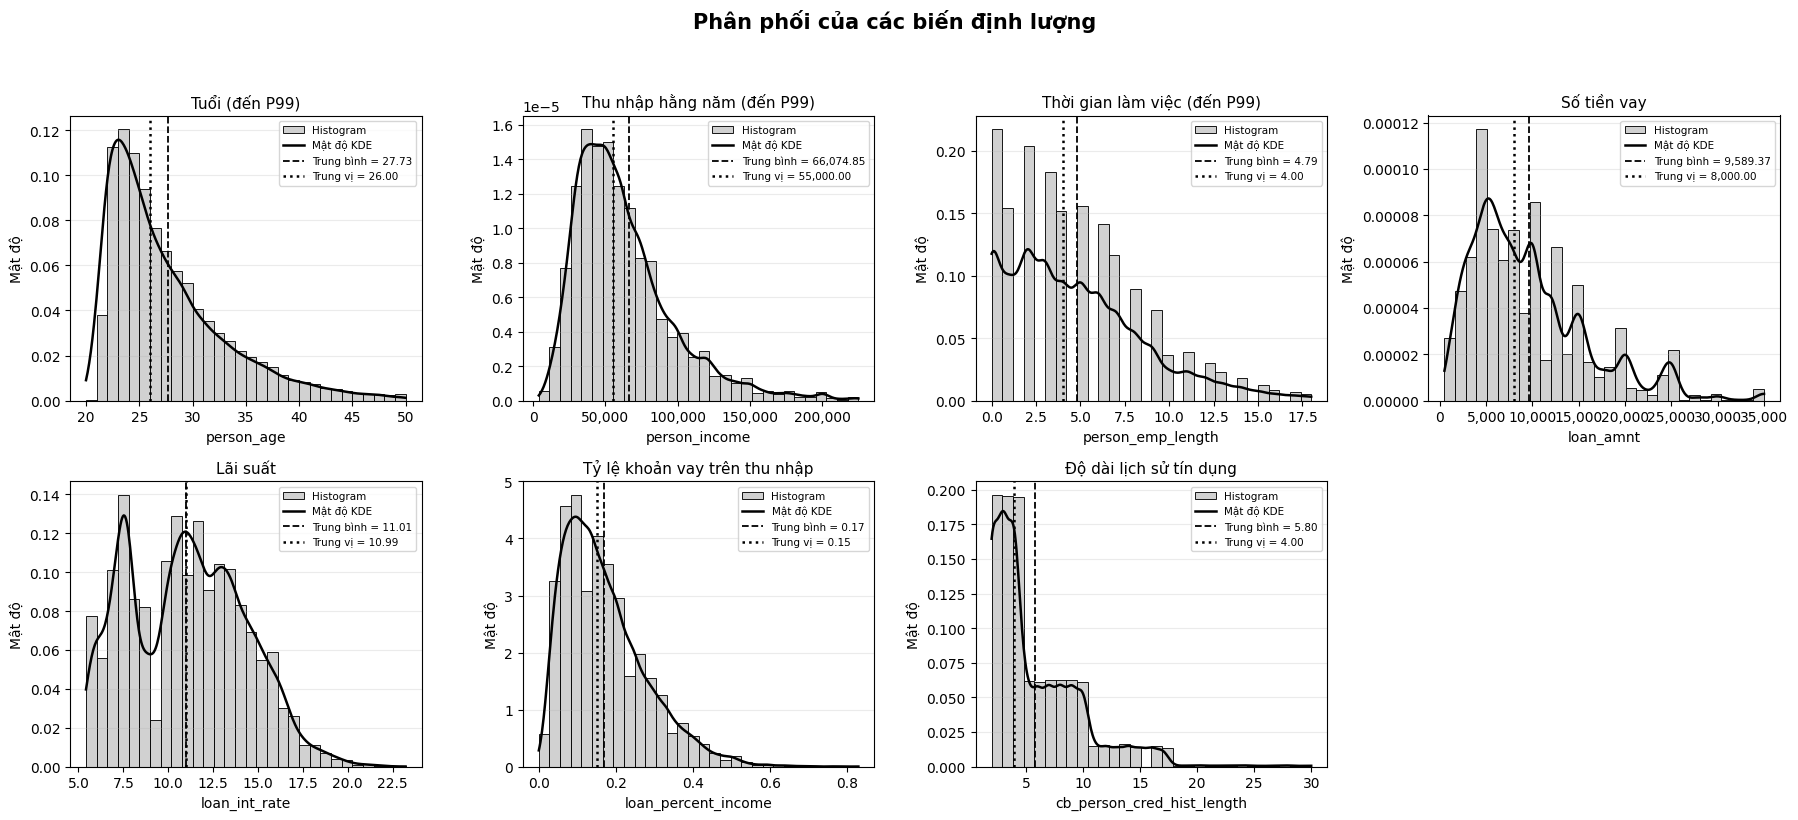

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde


numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

feature_labels = {
    "person_age": "Tuổi",
    "person_income": "Thu nhập hằng năm",
    "person_emp_length": "Thời gian làm việc",
    "loan_amnt": "Số tiền vay",
    "loan_int_rate": "Lãi suất",
    "loan_percent_income": "Tỷ lệ khoản vay trên thu nhập",
    "cb_person_cred_hist_length": "Độ dài lịch sử tín dụng"
}

# Chỉ giới hạn phạm vi hiển thị đối với các biến
# có một số giá trị đặc biệt lớn.
limit_to_p99 = {
    "person_age",
    "person_income",
    "person_emp_length"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(18, 8)
)

axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):

    values = df[feature].dropna()

    # Trung bình và trung vị được tính trên toàn bộ dữ liệu.
    mean_value = values.mean()
    median_value = values.median()

    if feature in limit_to_p99:
        upper_limit = values.quantile(0.99)
        plot_values = values[values <= upper_limit]
        title_suffix = " (đến P99)"
    else:
        plot_values = values
        title_suffix = ""

    # Histogram chuẩn hóa về mật độ.
    ax.hist(
        plot_values,
        bins=30,
        density=True,
        facecolor="0.80",
        edgecolor="black",
        linewidth=0.7,
        alpha=0.9,
        label="Histogram"
    )

    # Đường mật độ KDE.
    if plot_values.nunique() > 1:
        x_grid = np.linspace(
            plot_values.min(),
            plot_values.max(),
            400
        )

        kde = gaussian_kde(plot_values)

        ax.plot(
            x_grid,
            kde(x_grid),
            color="black",
            linewidth=1.8,
            label="Mật độ KDE"
        )

    # Đường trung bình.
    ax.axvline(
        mean_value,
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=f"Trung bình = {mean_value:,.2f}"
    )

    # Đường trung vị.
    ax.axvline(
        median_value,
        color="black",
        linestyle=":",
        linewidth=1.8,
        label=f"Trung vị = {median_value:,.2f}"
    )

    ax.set_title(
        feature_labels[feature] + title_suffix,
        fontsize=11
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Mật độ")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=7.5)

    # Định dạng số tiền.
    if feature in {"person_income", "loan_amnt"}:
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

# Ẩn ô còn thừa.
for ax in axes[len(numeric_features):]:
    ax.axis("off")

fig.suptitle(
    "Phân phối của các biến định lượng",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

fig.savefig(
    "numeric_feature_distributions_kde.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "numeric_feature_distributions_kde.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét biến định lượng

Phân tích đơn biến cho thấy phần lớn các biến định lượng có phân phối lệch phải,
thể hiện qua việc giá trị trung bình lớn hơn giá trị trung vị. Hiện tượng này
đặc biệt rõ đối với các biến `person_income`, `loan_amnt`,
`loan_percent_income` và `cb_person_cred_hist_length`.

Khách hàng trong tập dữ liệu chủ yếu còn trẻ, với tuổi trung vị là 26. Thu nhập
hằng năm có trung vị khoảng 55.000, trong khi số tiền vay có trung vị khoảng
8.000. Tỷ lệ khoản vay trên thu nhập có trung vị 0,15, cho thấy đối với một
khách hàng điển hình, số tiền vay tương đương khoảng 15% thu nhập hằng năm.

Biến `loan_int_rate` có trung bình và trung vị gần bằng nhau, nhưng phân phối
xuất hiện nhiều đỉnh. Điều này có thể phản ánh việc lãi suất được xác định theo
các nhóm rủi ro hoặc hạng khoản vay khác nhau.

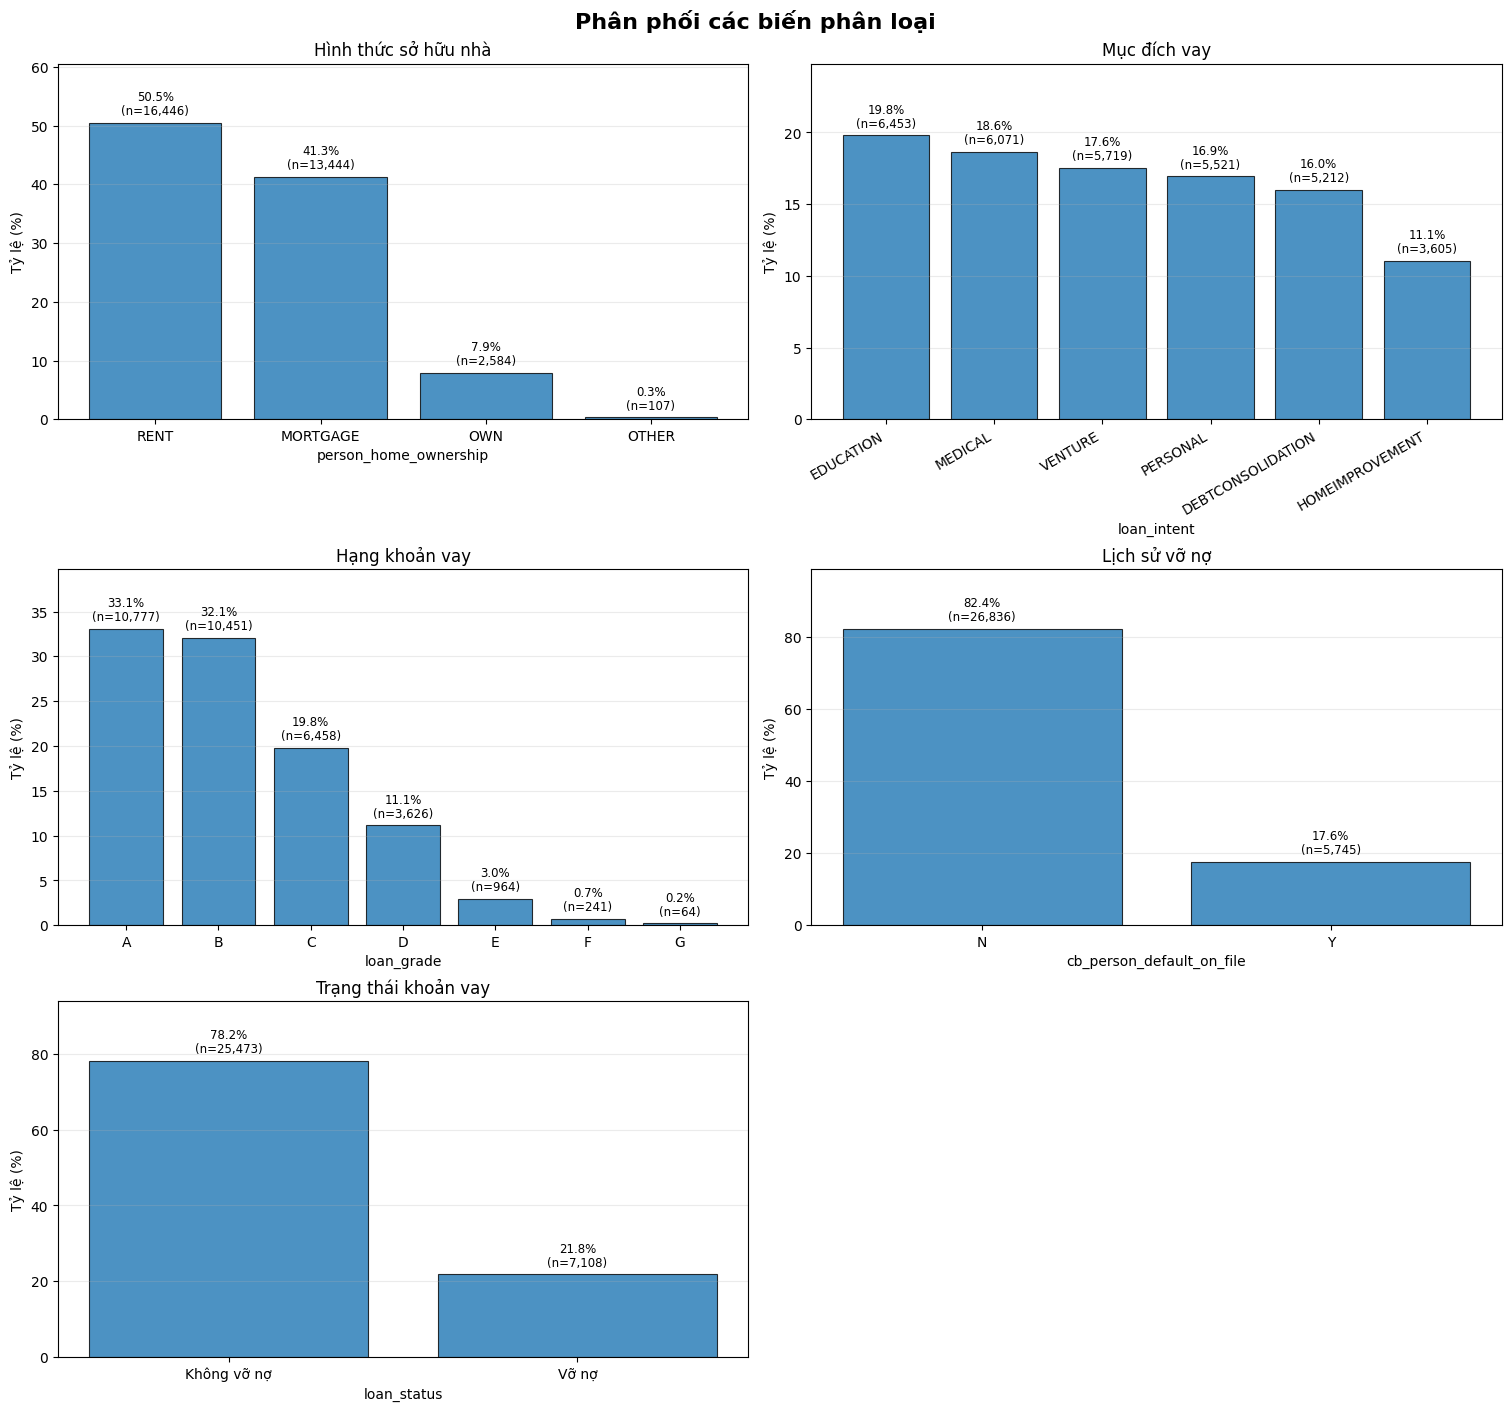

In [28]:
import matplotlib.pyplot as plt

categorical_orders = {
    "person_home_ownership": [
        "RENT", "MORTGAGE", "OWN", "OTHER"
    ],
    "loan_intent": [
        "EDUCATION",
        "MEDICAL",
        "VENTURE",
        "PERSONAL",
        "DEBTCONSOLIDATION",
        "HOMEIMPROVEMENT"
    ],
    "loan_grade": [
        "A", "B", "C", "D", "E", "F", "G"
    ],
    "cb_person_default_on_file": [
        "N", "Y"
    ],
    "loan_status": [
        0, 1
    ]
}

categorical_labels = {
    "person_home_ownership": "Hình thức sở hữu nhà",
    "loan_intent": "Mục đích vay",
    "loan_grade": "Hạng khoản vay",
    "cb_person_default_on_file": "Lịch sử vỡ nợ",
    "loan_status": "Trạng thái khoản vay"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(15, 14),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (feature, order) in zip(
    axes,
    categorical_orders.items()
):
    counts = (
        df[feature]
        .value_counts(dropna=False)
        .reindex(order, fill_value=0)
    )

    percentages = counts / counts.sum() * 100

    # Nhãn hiển thị trên trục x
    if feature == "loan_status":
        x_labels = ["Không vỡ nợ", "Vỡ nợ"]
    else:
        x_labels = percentages.index.astype(str)

    bars = ax.bar(
        x_labels,
        percentages.values,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8
    )

    ax.set_title(
        categorical_labels[feature],
        fontsize=12
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Tỷ lệ (%)")
    ax.grid(axis="y", alpha=0.25)

    # Chừa khoảng trống phía trên cho nhãn số.
    max_percentage = percentages.max()

    upper_limit = max_percentage * 1.20

    # Trường hợp cột lớn gần 100%.
    upper_limit = min(max(upper_limit, max_percentage + 5), 105)

    ax.set_ylim(0, upper_limit)

    # Khoảng cách giữa đỉnh cột và chú thích.
    annotation_offset = upper_limit * 0.015

    for bar, percentage, count in zip(
        bars,
        percentages.values,
        counts.values
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + annotation_offset,
            f"{percentage:.1f}%\n"
            f"(n={count:,})",
            ha="center",
            va="bottom",
            fontsize=8.5,
            linespacing=1.1,
            clip_on=False
        )

    # Xoay nhãn dài để không chồng lấn.
    if feature == "loan_intent":
        ax.tick_params(
            axis="x",
            labelrotation=30
        )

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

# Ẩn ô còn thừa.
for ax in axes[len(categorical_orders):]:
    ax.axis("off")

fig.suptitle(
    "Phân phối các biến phân loại",
    fontsize=16,
    fontweight="bold"
)

fig.savefig(
    "categorical_feature_distributions.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "categorical_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Nhận xét biến định tính

Phân phối của các biến phân loại cho thấy dữ liệu không được phân bố đồng đều
giữa các nhóm.

- Đối với biến `person_home_ownership`, phần lớn khách hàng đang thuê nhà
(`RENT`), chiếm 50,5%, tiếp theo là nhóm có khoản vay thế chấp
(`MORTGAGE`) với 41,3%. Nhóm sở hữu nhà hoàn toàn (`OWN`) chỉ chiếm 7,9%,
trong khi nhóm `OTHER` có tỷ lệ rất nhỏ, khoảng 0,3%. Do số quan sát trong
nhóm `OTHER` thấp, giá trị WOE của nhóm này có thể không ổn định và cần được
xem xét khi thực hiện phân nhóm.

- Các mục đích vay trong biến `loan_intent` được phân bố tương đối đồng đều hơn.
Vay cho giáo dục (`EDUCATION`) là nhóm phổ biến nhất, chiếm 19,8%, trong khi
vay để cải thiện nhà ở (`HOMEIMPROVEMENT`) là nhóm ít phổ biến nhất, chiếm
11,1%. Không có một mục đích vay nào chiếm ưu thế tuyệt đối trong tập dữ liệu.

- Đối với biến `loan_grade`, hai hạng A và B chiếm phần lớn số quan sát, lần lượt
là 33,1% và 32,1%. Tỷ lệ quan sát giảm dần theo các hạng rủi ro cao hơn. Các
hạng F và G chỉ chiếm lần lượt 0,7% và 0,2%, cho thấy số quan sát trong hai
nhóm này tương đối thấp. Khi tính WOE, cần kiểm tra số lượng khách hàng vỡ nợ
và không vỡ nợ trong từng hạng; các hạng có quá ít quan sát có thể cần được
gộp để bảo đảm tính ổn định.

- Biến `cb_person_default_on_file` cho thấy 82,4% khách hàng không có lịch sử vỡ
nợ được ghi nhận (`N`), trong khi 17,6% khách hàng từng có lịch sử vỡ nợ
(`Y`). Đây có thể là một biến dự báo quan trọng, tuy nhiên khả năng phân biệt
chỉ có thể được đánh giá rõ hơn sau khi so sánh tỷ lệ vỡ nợ hiện tại giữa hai
nhóm.

- Đối với biến mục tiêu `loan_status`, nhóm không vỡ nợ chiếm 78,2%, trong khi
nhóm vỡ nợ chiếm 21,8%. Như vậy, dữ liệu có sự mất cân bằng lớp ở mức nhất
định. Vì vậy, khi đánh giá mô hình, không nên chỉ dựa vào độ chính xác
(*accuracy*) mà cần kết hợp các chỉ số như AUC, precision, recall, specificity
và KS.

Cần lưu ý rằng các biểu đồ trên chỉ mô tả tần suất xuất hiện của từng nhóm,
chưa phản ánh trực tiếp mối quan hệ giữa các biến phân loại và khả năng vỡ nợ.
Bước tiếp theo cần tính tỷ lệ vỡ nợ trong từng nhóm của mỗi biến để xác định
những nhóm có mức độ rủi ro khác biệt.

**Nhận xét tổng quát**

Phần lớn khách hàng trong tập dữ liệu thuộc nhóm thuê nhà hoặc đang trả khoản
vay thế chấp. Các mục đích vay được phân bố tương đối đồng đều, trong khi hạng
khoản vay tập trung chủ yếu ở hai mức A và B. Các nhóm hiếm như hình thức sở
hữu nhà `OTHER` và các hạng khoản vay F, G có ít quan sát, do đó có thể tạo ra
các ước lượng WOE không ổn định và cần được xem xét trong quá trình phân nhóm.

Khoảng 17,6% khách hàng có lịch sử vỡ nợ, trong khi tỷ lệ vỡ nợ của khoản vay
hiện tại là 21,8%. Biến mục tiêu có sự mất cân bằng giữa hai lớp, với nhóm
không vỡ nợ chiếm 78,2% số quan sát. Tuy nhiên, phân phối tần suất đơn thuần
chưa cho biết nhóm nào có rủi ro cao hơn; cần tiếp tục phân tích tỷ lệ vỡ nợ
theo từng mức của các biến phân loại.

## 5.3. Mối quan hệ giữa các biến phân loại và trạng thái vỡ nợ

Phân phối tần suất của các biến phân loại chưa phản ánh trực tiếp mức độ rủi ro
của từng nhóm. Vì vậy, tỷ lệ vỡ nợ được tính riêng cho từng mức của mỗi biến
phân loại.

Đối với nhóm thứ $j$, tỷ lệ vỡ nợ được xác định bởi:

$$
\text{Default rate}_j
=
\frac{\text{Số khách hàng vỡ nợ trong nhóm }j}
{\text{Tổng số khách hàng trong nhóm }j}.
$$

Sự khác biệt về tỷ lệ vỡ nợ giữa các nhóm giúp đánh giá sơ bộ khả năng phân
biệt của từng biến trước khi thực hiện binning và chuyển đổi WOE.

In [29]:
def categorical_default_summary(data, feature, target="loan_status"):
    summary = (
        data.groupby(feature, dropna=False)[target]
        .agg(
            total="count",
            default_count="sum",
            default_rate="mean"
        )
        .reset_index()
    )

    summary["non_default_count"] = (
        summary["total"] - summary["default_count"]
    )

    summary["default_rate_pct"] = (
        summary["default_rate"] * 100
    )

    return summary

In [30]:
loan_grade_summary = categorical_default_summary(
    df,
    "loan_grade"
)

display(loan_grade_summary)

,loan_grade,total,default_count,default_rate,non_default_count,default_rate_pct
0,A,10777,1073,0.099564,9704,9.956389
1,B,10451,1701,0.162760,8750,16.275954
2,C,6458,1339,0.207340,5119,20.733973
3,D,3626,2141,0.590458,1485,59.045780
4,E,964,621,0.644191,343,64.419087
5,F,241,170,0.705394,71,70.539419
6,G,64,63,0.984375,1,98.437500


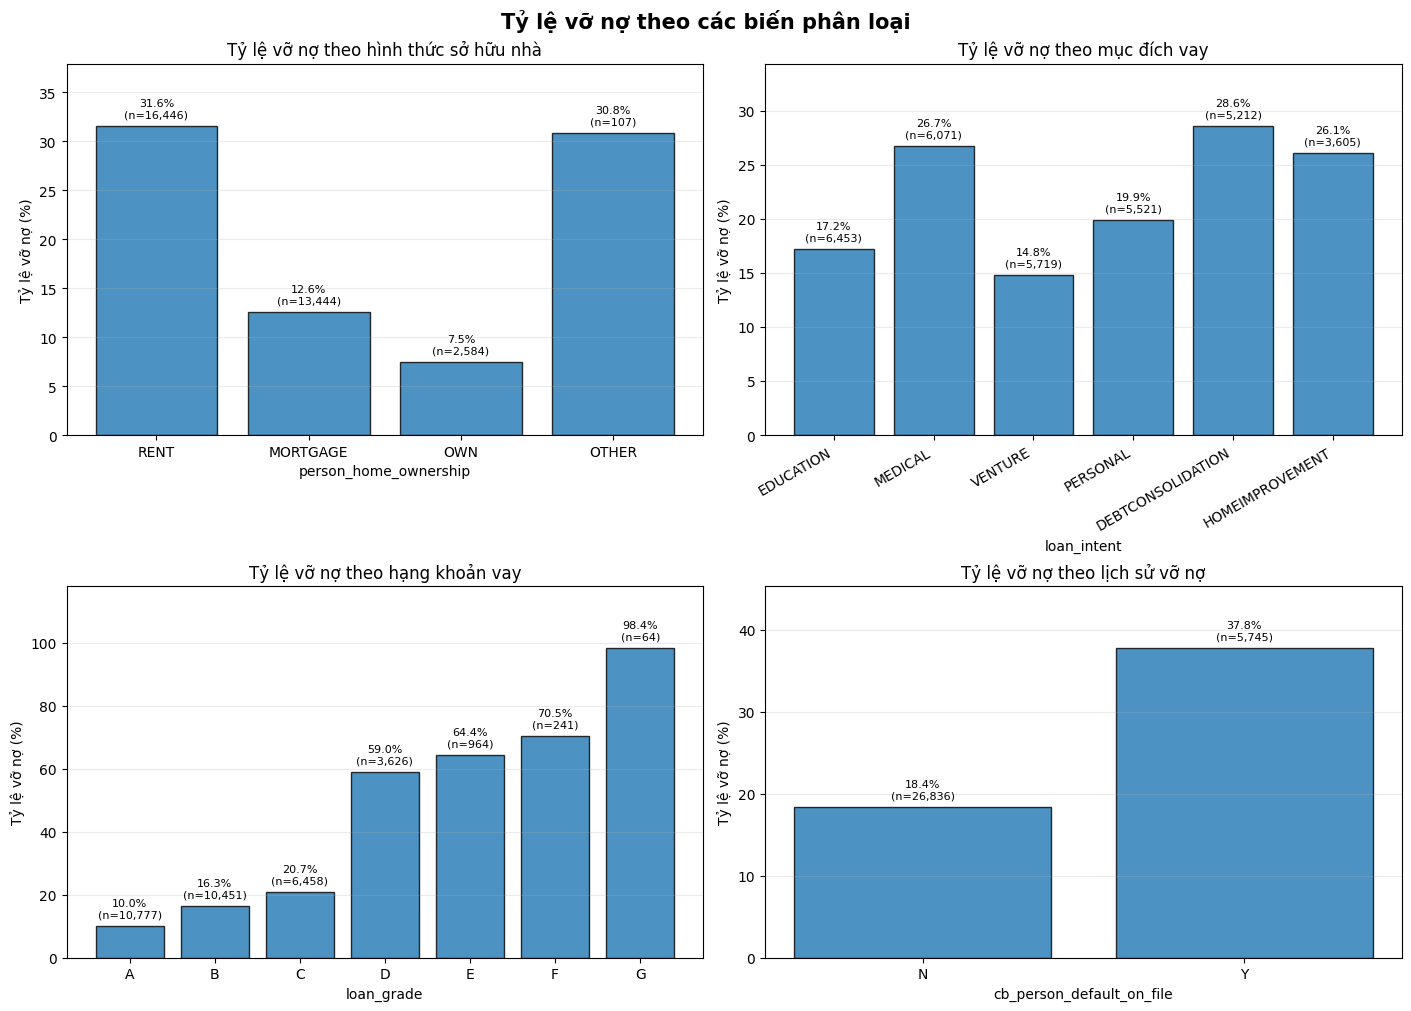

In [31]:
import matplotlib.pyplot as plt

category_orders = {
    "person_home_ownership": [
        "RENT", "MORTGAGE", "OWN", "OTHER"
    ],
    "loan_intent": [
        "EDUCATION",
        "MEDICAL",
        "VENTURE",
        "PERSONAL",
        "DEBTCONSOLIDATION",
        "HOMEIMPROVEMENT"
    ],
    "loan_grade": [
        "A", "B", "C", "D", "E", "F", "G"
    ],
    "cb_person_default_on_file": [
        "N", "Y"
    ]
}

titles = {
    "person_home_ownership": "Tỷ lệ vỡ nợ theo hình thức sở hữu nhà",
    "loan_intent": "Tỷ lệ vỡ nợ theo mục đích vay",
    "loan_grade": "Tỷ lệ vỡ nợ theo hạng khoản vay",
    "cb_person_default_on_file": "Tỷ lệ vỡ nợ theo lịch sử vỡ nợ"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (feature, order) in zip(
    axes,
    category_orders.items()
):
    summary = categorical_default_summary(
        df,
        feature
    )

    summary[feature] = pd.Categorical(
        summary[feature],
        categories=order,
        ordered=True
    )

    summary = summary.sort_values(feature)

    bars = ax.bar(
        summary[feature].astype(str),
        summary["default_rate_pct"],
        edgecolor="black",
        alpha=0.8
    )

    max_rate = summary["default_rate_pct"].max()
    ax.set_ylim(0, max_rate * 1.20)

    for bar, rate, total in zip(
        bars,
        summary["default_rate_pct"],
        summary["total"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_rate * 0.02,
            f"{rate:.1f}%\n(n={total:,})",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(titles[feature])
    ax.set_xlabel(feature)
    ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
    ax.grid(axis="y", alpha=0.25)

    if feature == "loan_intent":
        ax.tick_params(axis="x", rotation=30)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

fig.suptitle(
    "Tỷ lệ vỡ nợ theo các biến phân loại",
    fontsize=15,
    fontweight="bold"
)

fig.savefig(
    "categorical_default_rates.pdf",
    bbox_inches="tight"
)

plt.show()

### Nhận xét

Tỷ lệ vỡ nợ có sự khác biệt đáng kể giữa các nhóm của hầu hết biến phân loại.

Đối với biến `person_home_ownership`, nhóm khách hàng thuê nhà (`RENT`) có tỷ
lệ vỡ nợ cao nhất, đạt 31,6%. Tỷ lệ này
thấp hơn đáng kể ở nhóm đang trả khoản vay thế chấp (`MORTGAGE`), với 12,6%,
và thấp nhất ở nhóm sở hữu nhà hoàn toàn (`OWN`), với 7,5%. Nhóm `OTHER` có
tỷ lệ vỡ nợ 30,8%, nhưng chỉ gồm 107 quan sát nên kết quả của nhóm này có thể
không ổn định và cần được diễn giải thận trọng.

Đối với biến `loan_intent`, tỷ lệ vỡ nợ cao nhất thuộc về nhóm vay để hợp nhất
nợ (`DEBTCONSOLIDATION`), đạt 28,6%. Các khoản vay cho mục đích y tế
(`MEDICAL`) và cải thiện nhà ở (`HOMEIMPROVEMENT`) cũng có tỷ lệ vỡ nợ tương
đối cao, lần lượt là 26,7% và 26,1%. Ngược lại, nhóm vay để đầu tư kinh doanh
(`VENTURE`) có tỷ lệ vỡ nợ thấp nhất, khoảng 14,8%.

Biến `loan_grade` thể hiện mối quan hệ rất rõ với trạng thái vỡ nợ. Tỷ lệ vỡ
nợ tăng gần như đơn điệu từ hạng A đến hạng G: từ 10,0% ở hạng A lên 16,3% ở
hạng B, 20,7% ở hạng C và tăng mạnh lên 59,0% ở hạng D. Các hạng E, F và G
có tỷ lệ vỡ nợ lần lượt là 64,4%, 70,5% và 98,4%. Kết quả này cho thấy
`loan_grade` có khả năng phân biệt rất mạnh giữa khách hàng rủi ro thấp và rủi
ro cao.

Tuy nhiên, các hạng F và G có số lượng quan sát tương đối nhỏ, đặc biệt hạng G
chỉ có 64 quan sát. Vì vậy, tỷ lệ vỡ nợ rất cao của các nhóm này có thể không
ổn định. Khi thực hiện WOE, cần kiểm tra số lượng Good và Bad trong từng nhóm
và cân nhắc gộp các hạng có ít quan sát nếu cần thiết.

Đối với biến `cb_person_default_on_file`, nhóm khách hàng từng có lịch sử vỡ
nợ (`Y`) có tỷ lệ vỡ nợ hiện tại là 37,8%, cao hơn đáng kể so với mức 18,4%
của nhóm không có lịch sử vỡ nợ (`N`). Điều này cho thấy lịch sử vỡ nợ có thể
là một biến dự báo quan trọng đối với rủi ro tín dụng hiện tại.

Nhìn chung, `loan_grade` và `cb_person_default_on_file` thể hiện sự khác biệt
rủi ro rõ ràng nhất giữa các nhóm. `person_home_ownership` và `loan_intent`
cũng cho thấy khả năng phân biệt nhất định.

## 5.4. Tỷ lệ vỡ nợ theo các biến định lượng

Để khảo sát mối quan hệ giữa các biến định lượng và trạng thái khoản vay, mỗi
biến được chia tạm thời thành các nhóm dựa trên phân vị. Sau đó, tỷ lệ vỡ nợ
được tính riêng cho từng nhóm.

Đối với nhóm thứ $j$, tỷ lệ vỡ nợ được xác định bởi:

$$
\text{Tỷ lệ vỡ nợ}_j
=
\frac{\text{Số quan sát vỡ nợ trong nhóm }j}
{\text{Tổng số quan sát trong nhóm }j}.
$$

Các khoảng phân vị trong phần này chỉ phục vụ phân tích khám phá dữ liệu và
không phải là các khoảng chính thức được sử dụng để tính WOE.

In [34]:
import numpy as np
import pandas as pd


def numeric_default_summary(
    data,
    feature,
    target="loan_status",
    n_bins=10
):
    """
    Chia một biến định lượng thành các nhóm phân vị và
    tính tỷ lệ vỡ nợ trong từng nhóm.
    """

    working_data = data[[feature, target]].copy()

    missing_mask = working_data[feature].isna()
    non_missing = working_data.loc[~missing_mask].copy()

    # Chia thành các nhóm có số quan sát gần bằng nhau.
    non_missing["bin"] = pd.qcut(
        non_missing[feature],
        q=n_bins,
        duplicates="drop"
    )

    summary = (
        non_missing
        .groupby("bin", observed=True)
        .agg(
            total=(target, "count"),
            default_count=(target, "sum"),
            default_rate=(target, "mean"),
            mean_feature=(feature, "mean"),
            median_feature=(feature, "median")
        )
        .reset_index()
    )

    summary["non_default_count"] = (
        summary["total"]
        - summary["default_count"]
    )

    summary["default_rate_pct"] = (
        summary["default_rate"] * 100
    )

    # Xử lý giá trị thiếu như một nhóm riêng.
    if missing_mask.any():
        missing_data = working_data.loc[missing_mask]

        missing_row = pd.DataFrame({
            "bin": ["Missing"],
            "total": [len(missing_data)],
            "default_count": [missing_data[target].sum()],
            "default_rate": [missing_data[target].mean()],
            "mean_feature": [np.nan],
            "median_feature": [np.nan],
            "non_default_count": [
                len(missing_data)
                - missing_data[target].sum()
            ],
            "default_rate_pct": [
                missing_data[target].mean() * 100
            ]
        })

        summary = pd.concat(
            [summary, missing_row],
            ignore_index=True
        )

    summary["bin_label"] = summary["bin"].astype(str)

    return summary

In [35]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

feature_titles = {
    "person_age": "Tuổi",
    "person_income": "Thu nhập hằng năm",
    "person_emp_length": "Thời gian làm việc",
    "loan_amnt": "Số tiền vay",
    "loan_int_rate": "Lãi suất",
    "loan_percent_income": "Tỷ lệ khoản vay trên thu nhập",
    "cb_person_cred_hist_length": "Độ dài lịch sử tín dụng"
}

numeric_default_tables = {}

for feature in numeric_features:
    numeric_default_tables[feature] = numeric_default_summary(
        data=df,
        feature=feature,
        target="loan_status",
        n_bins=10
    )

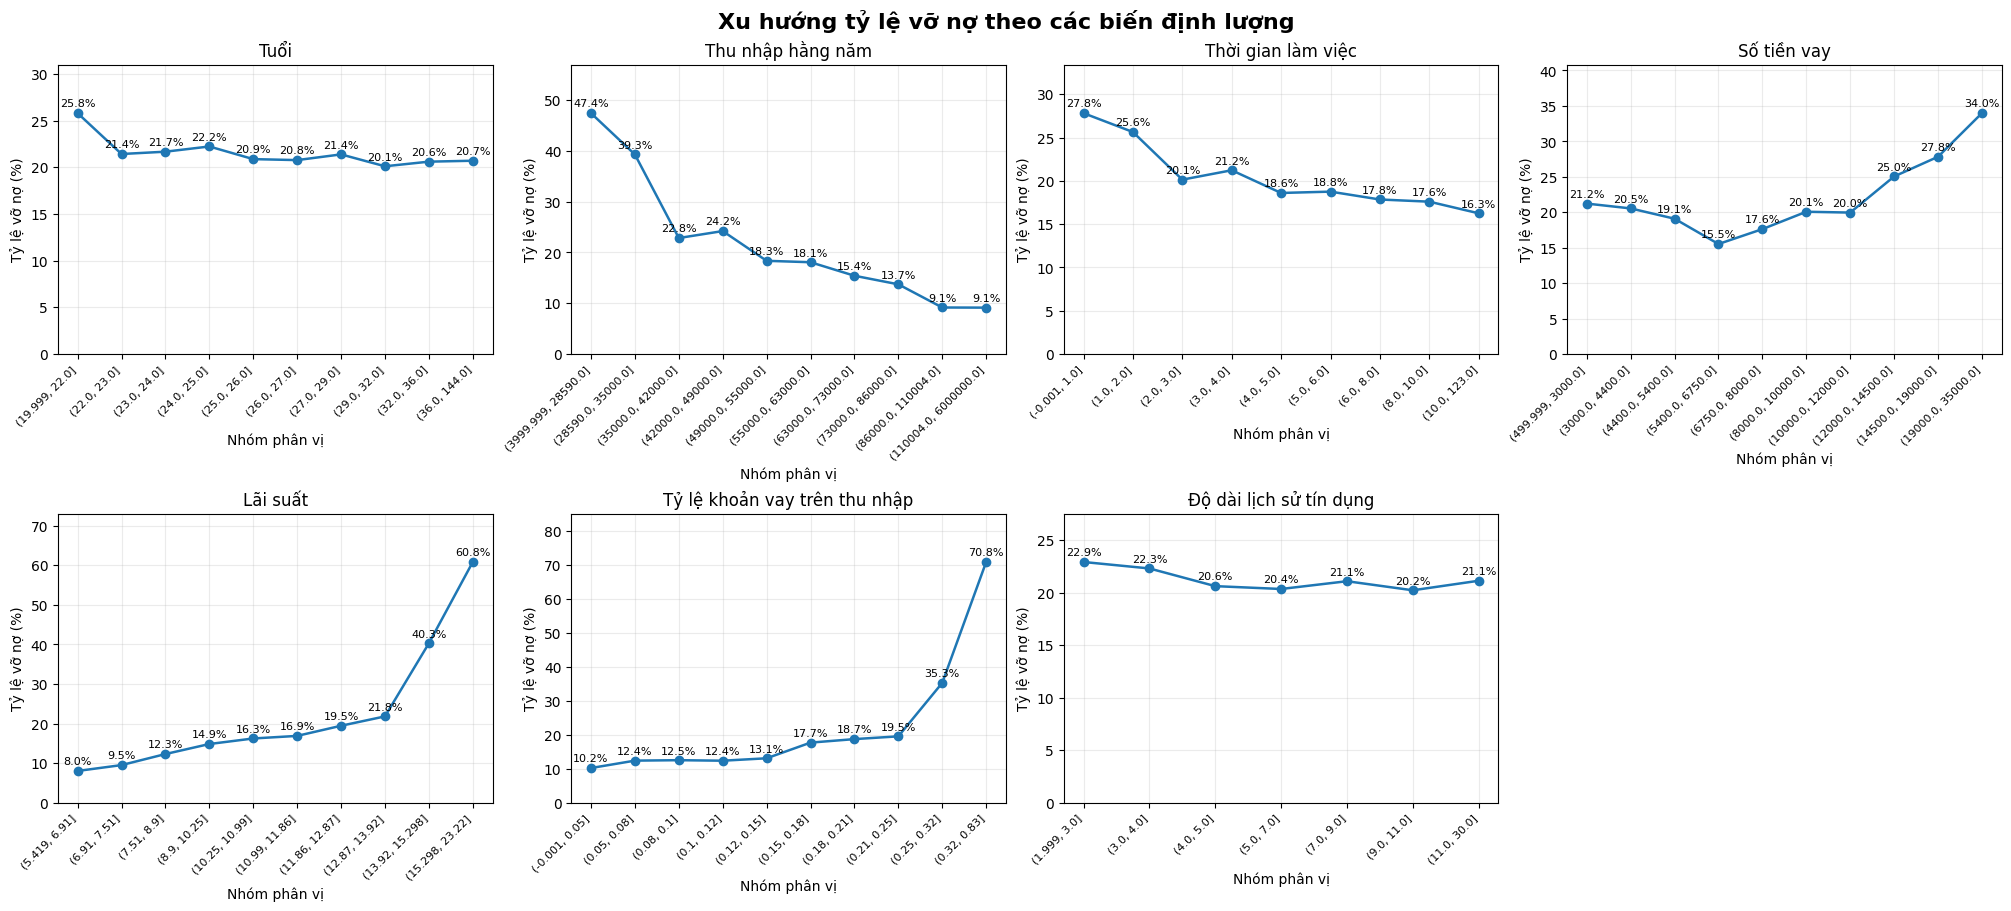

In [36]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 9),
    constrained_layout=True
)

axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):

    summary = numeric_default_tables[feature]

    # Không nối nhóm Missing vào đường xu hướng.
    plot_summary = summary[
        summary["bin_label"] != "Missing"
    ].copy()

    x_positions = np.arange(len(plot_summary))

    ax.plot(
        x_positions,
        plot_summary["default_rate_pct"],
        marker="o",
        linewidth=1.8
    )

    ax.set_xticks(x_positions)

    ax.set_xticklabels(
        plot_summary["bin_label"],
        rotation=45,
        ha="right",
        fontsize=8
    )

    upper_limit = max(
        plot_summary["default_rate_pct"].max() * 1.20,
        plot_summary["default_rate_pct"].max() + 3
    )

    ax.set_ylim(0, upper_limit)

    for x, rate in zip(
        x_positions,
        plot_summary["default_rate_pct"]
    ):
        ax.text(
            x,
            rate + upper_limit * 0.015,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(feature_titles[feature])
    ax.set_xlabel("Nhóm phân vị")
    ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
    ax.grid(alpha=0.25)

for ax in axes[len(numeric_features):]:
    ax.axis("off")

fig.suptitle(
    "Xu hướng tỷ lệ vỡ nợ theo các biến định lượng",
    fontsize=16,
    fontweight="bold"
)

fig.savefig(
    "numeric_default_rate_trends.pdf",
    bbox_inches="tight"
)

plt.show()

### Nhận xét

Tỷ lệ vỡ nợ thay đổi đáng kể giữa các nhóm phân vị của một số biến định lượng.

Đối với `person_age`, nhóm khách hàng trẻ nhất có tỷ lệ vỡ nợ cao nhất, khoảng
25,8%. Sau đó, tỷ lệ này giảm và dao động tương đối ổn định quanh mức 20%–22%
ở các nhóm tuổi còn lại. Điều này cho thấy tuổi có mối liên hệ với trạng thái
vỡ nợ, nhưng khả năng phân biệt đơn biến nhìn chung không quá mạnh. Khoảng cuối
cùng chứa các giá trị lên tới 144 tuổi, vì vậy cần kiểm tra các quan sát tuổi
không hợp lý trước khi xử lý dữ liệu.

Biến `person_income` thể hiện quan hệ nghịch tương đối rõ với rủi ro tín dụng.
Tỷ lệ vỡ nợ giảm từ 47,4% ở nhóm thu nhập thấp nhất xuống khoảng 9,1% ở hai
nhóm thu nhập cao nhất. Mặc dù có một dao động nhỏ giữa một số nhóm liền kề,
xu hướng tổng thể cho thấy khách hàng có thu nhập cao hơn thường có tỷ lệ vỡ
nợ thấp hơn.

Đối với `person_emp_length`, tỷ lệ vỡ nợ nhìn chung giảm khi thời gian làm việc
tăng. Nhóm có thời gian làm việc ngắn nhất có tỷ lệ vỡ nợ khoảng 27,8%, trong
khi nhóm có thời gian làm việc dài nhất có tỷ lệ khoảng 16,3%. Mối quan hệ này
không hoàn toàn đơn điệu do có một số dao động nhỏ giữa các nhóm kế tiếp. Ngoài
ra, khoảng cuối cùng chứa giá trị lên tới 123 năm, cho thấy cần kiểm tra các
giá trị thời gian làm việc bất hợp lý.

Biến `loan_amnt` thể hiện mối quan hệ phi tuyến, gần với dạng chữ U. Tỷ lệ vỡ
nợ giảm từ 21,2% ở nhóm khoản vay thấp nhất xuống mức thấp nhất là 15,5% ở
nhóm khoản vay khoảng 5.400–6.750. Sau đó, tỷ lệ vỡ nợ tăng dần và đạt 34,0%
ở nhóm có số tiền vay cao nhất. Kết quả này cho thấy cả khoản vay rất nhỏ và
đặc biệt là khoản vay lớn đều có thể gắn với mức rủi ro cao hơn, trong khi các
khoản vay trung bình có tỷ lệ vỡ nợ thấp hơn.

`loan_int_rate` có mối quan hệ thuận rất rõ với trạng thái vỡ nợ. Tỷ lệ vỡ nợ
tăng gần như đơn điệu từ 8,0% ở nhóm lãi suất thấp nhất lên 60,8% ở nhóm lãi
suất cao nhất. Mức tăng đặc biệt mạnh khi lãi suất vượt khoảng 13,9%. Đây có
thể là một biến có khả năng phân biệt rủi ro rất mạnh. Tuy nhiên, lãi suất có
thể đã được xác định dựa trên kết quả thẩm định tín dụng trước đó, nên vai trò
của biến này cần được xem xét phù hợp với thời điểm dự báo của mô hình.

Tương tự, `loan_percent_income` thể hiện quan hệ thuận mạnh và có tính tuyến tính. Tỷ lệ vỡ nợ tương đối thấp và ổn định ở các nhóm có tỷ lệ khoản vay trên
thu nhập dưới 0,15, sau đó tăng dần. Tỷ lệ vỡ nợ tăng lên 35,7% trong nhóm
0,25–0,32 và đạt 70,8% ở nhóm lớn hơn 0,32. Điều này cho thấy rủi ro tăng mạnh
khi số tiền vay chiếm tỷ trọng lớn so với thu nhập hằng năm của khách hàng.

Ngược lại, `cb_person_cred_hist_length` có tỷ lệ vỡ nợ dao động trong phạm vi
hẹp, khoảng 20,2%–22,9%, và không thể hiện xu hướng tăng hoặc giảm rõ ràng.
Do đó, độ dài lịch sử tín dụng có vẻ có khả năng phân biệt đơn biến tương đối
hạn chế trong tập dữ liệu này.

Nhìn chung, `loan_int_rate`, `loan_percent_income` và `person_income` thể hiện
mối quan hệ rõ nhất với trạng thái vỡ nợ. `person_emp_length` cho thấy xu hướng
giảm tương đối, trong khi `loan_amnt` có quan hệ phi tuyến. Các biến
`person_age` và `cb_person_cred_hist_length` có mức độ phân biệt trực quan thấp
hơn.

## 5.5 Mối quan hệ giữa các biến dự báo

Sau khi khảo sát mối quan hệ giữa từng biến và trạng thái vỡ nợ, bước tiếp theo
là xem xét mối quan hệ giữa các biến dự báo. Phân tích này nhằm phát hiện các
biến có thông tin trùng lặp hoặc có mối liên hệ mạnh, từ đó hỗ trợ quá trình
lựa chọn biến và hạn chế hiện tượng đa cộng tuyến trong mô hình hồi quy
logistic.

Do phần lớn các biến định lượng có phân phối lệch và một số mối quan hệ có thể
không hoàn toàn tuyến tính, hệ số tương quan Spearman được sử dụng.

In [43]:
numeric_predictors = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

spearman_corr = (
    df[numeric_predictors]
    .corr(method="spearman")
)

display(spearman_corr.round(3))

Biến,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
Biến,,,,,,,
person_age,1.000,0.145,0.107,0.064,0.012,-0.058,0.806
person_income,0.145,1.000,0.213,0.407,-0.034,-0.367,0.092
person_emp_length,0.107,0.213,1.000,0.110,-0.066,-0.058,0.070
loan_amnt,0.064,0.407,0.110,1.000,0.106,0.654,0.042
loan_int_rate,0.012,-0.034,-0.066,0.106,1.000,0.124,0.014
loan_percent_income,-0.058,-0.367,-0.058,0.654,0.124,1.000,-0.037
cb_person_cred_hist_length,0.806,0.092,0.070,0.042,0.014,-0.037,1.000


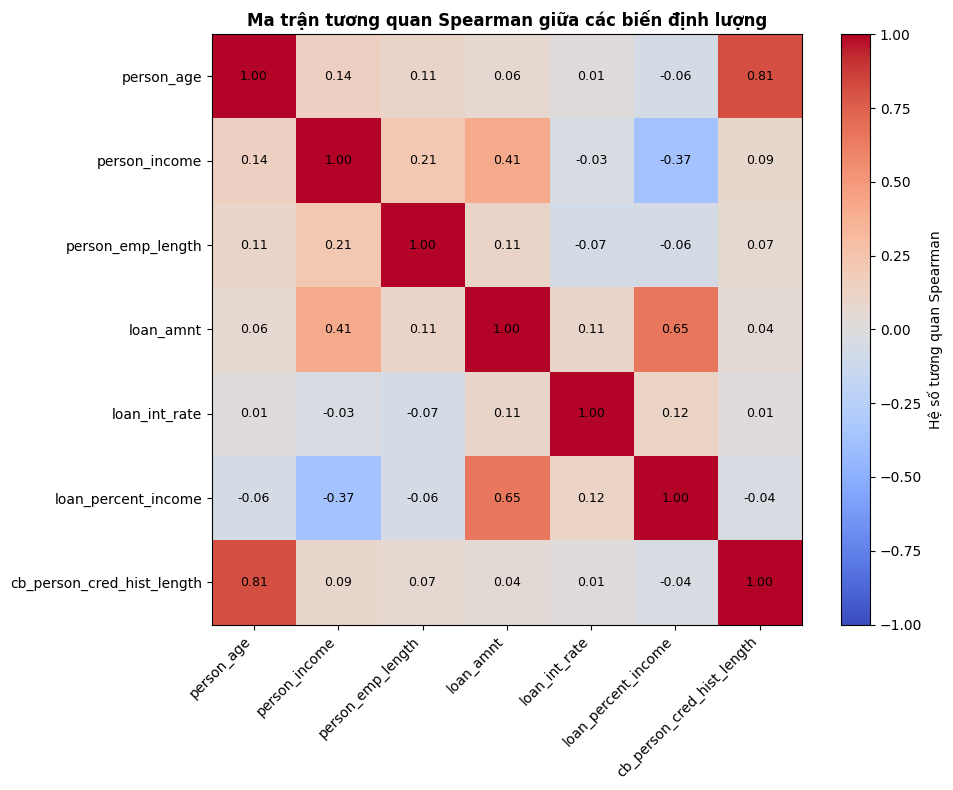

In [38]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    spearman_corr,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(
    np.arange(len(spearman_corr.columns))
)

ax.set_yticks(
    np.arange(len(spearman_corr.index))
)

ax.set_xticklabels(
    spearman_corr.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    spearman_corr.index
)

for i in range(len(spearman_corr.index)):
    for j in range(len(spearman_corr.columns)):
        value = spearman_corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title(
    "Ma trận tương quan Spearman giữa các biến định lượng",
    fontweight="bold"
)

fig.colorbar(
    image,
    ax=ax,
    label="Hệ số tương quan Spearman"
)

plt.tight_layout()

fig.savefig(
    "spearman_correlation_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

In [39]:
correlation_pairs = []

for i in range(len(spearman_corr.columns)):
    for j in range(i + 1, len(spearman_corr.columns)):

        variable_1 = spearman_corr.columns[i]
        variable_2 = spearman_corr.columns[j]
        correlation = spearman_corr.iloc[i, j]

        correlation_pairs.append({
            "Biến 1": variable_1,
            "Biến 2": variable_2,
            "Spearman correlation": correlation,
            "|Correlation|": abs(correlation)
        })

correlation_pairs = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "|Correlation|",
        ascending=False
    )
)

display(correlation_pairs.round(3))

,Biến 1,Biến 2,Spearman correlation,|Correlation|
5,person_age,cb_person_cred_hist_length,0.806,0.806
16,loan_amnt,loan_percent_income,0.654,0.654
7,person_income,loan_amnt,0.407,0.407
9,person_income,loan_percent_income,-0.367,0.367
6,person_income,person_emp_length,0.213,0.213
0,person_age,person_income,0.145,0.145
18,loan_int_rate,loan_percent_income,0.124,0.124
11,person_emp_length,loan_amnt,0.110,0.110
1,person_age,person_emp_length,0.107,0.107
15,loan_amnt,loan_int_rate,0.106,0.106


In [40]:
display(
    correlation_pairs[
        correlation_pairs["|Correlation|"] >= 0.5
    ].round(3)
)

,Biến 1,Biến 2,Spearman correlation,|Correlation|
5,person_age,cb_person_cred_hist_length,0.806,0.806
16,loan_amnt,loan_percent_income,0.654,0.654


In [41]:
calculated_loan_ratio = (
    df["loan_amnt"]
    / df["person_income"]
)

ratio_difference = (
    df["loan_percent_income"]
    - calculated_loan_ratio
).abs()

ratio_check = pd.DataFrame({
    "loan_percent_income": df["loan_percent_income"],
    "Tỷ lệ tính lại": calculated_loan_ratio,
    "Chênh lệch tuyệt đối": ratio_difference
})

display(ratio_check.head())
display(ratio_difference.describe())

,loan_percent_income,Tỷ lệ tính lại,Chênh lệch tuyệt đối
0,0.59,0.593220,0.003220
1,0.10,0.104167,0.004167
2,0.57,0.572917,0.002917
3,0.53,0.534351,0.004351
4,0.55,0.643382,0.093382


,0
count,32581.000000
mean,0.002762
std,0.004094
min,0.000000
25%,0.001111
50%,0.002500
75%,0.003674
max,0.093382


In [42]:
tolerance = 0.01

inconsistent_ratio = (
    ratio_difference > tolerance
)

print(
    "Số quan sát chênh lệch lớn hơn 0.01:",
    inconsistent_ratio.sum()
)

print(
    "Tỷ lệ:",
    f"{inconsistent_ratio.mean() * 100:.2f}%"
)

Số quan sát chênh lệch lớn hơn 0.01: 388
Tỷ lệ: 1.19%


### Nhận xét về mối quan hệ giữa các biến dự báo

Ma trận tương quan Spearman cho thấy phần lớn các cặp biến định lượng có hệ số
tương quan tuyệt đối thấp hơn 0,5. Nhìn chung, dữ liệu chưa cho thấy hiện tượng
các biến định lượng đồng biến hoặc nghịch biến . Tuy nhiên,
một số mối quan hệ cần được xem xét kỹ trước khi xây dựng mô hình.

#### Tuổi và độ dài lịch sử tín dụng

Cặp biến `person_age` và `cb_person_cred_hist_length` có hệ số tương quan
Spearman bằng 0,806, là mức tương quan thuận mạnh nhất trong số các cặp biến
định lượng.

Kết quả này phù hợp về mặt nghiệp vụ vì khách hàng lớn tuổi thường có nhiều thời
gian hơn để hình thành lịch sử tín dụng. Do đó, hai biến có thể chứa một phần
thông tin trùng lặp.

Tuy nhiên, không nên loại ngay một trong hai biến chỉ dựa trên hệ số tương quan.
Ở bước xây dựng mô hình, cần xem xét thêm khả năng phân biệt của từng biến,
Information Value, độ ổn định của các nhóm WOE và sự ổn định của hệ số hồi quy.
Nếu việc đưa đồng thời hai biến vào mô hình làm hệ số không ổn định hoặc không
cải thiện hiệu quả dự báo, có thể cân nhắc chỉ giữ lại biến phù hợp hơn.

#### Số tiền vay và tỷ lệ khoản vay trên thu nhập

Cặp `loan_amnt` và `loan_percent_income` có hệ số tương quan Spearman bằng
0,654, cho thấy mối tương quan thuận tương đối mạnh. Khi số tiền vay tăng, tỷ lệ
khoản vay trên thu nhập cũng có xu hướng tăng.


$$
\texttt{loan_percent_income}
\approx
\frac{\texttt{loan_amnt}}
{\texttt{person_income}}.
$$

Kết quả kiểm tra cho thấy chênh lệch tuyệt đối trung bình giữa tỷ lệ có sẵn và
tỷ lệ tính lại chỉ khoảng 0,0028, trong khi trung vị của chênh lệch là 0,0025.
Chỉ có 388 quan sát, tương ứng 1,19% dữ liệu, có chênh lệch lớn hơn 0,01. Vì
vậy, `loan_percent_income` về cơ bản là một biến được tạo từ
`loan_amnt` và `person_income`, có thể kèm theo sai số làm tròn.

Việc sử dụng đồng thời cả ba biến có thể tạo ra sự dư thừa thông tin. Tuy nhiên,
do quan hệ giữa chúng là quan hệ tỷ số chứ không phải tổ hợp tuyến tính đơn giản,
đây không nhất thiết là đa cộng tuyến  trong hồi quy logistic. Quyết
định giữ hoặc loại biến nên dựa thêm trên IV, hiệu quả mô hình và tính ổn định
của các hệ số.

#### Thu nhập và các đặc điểm khoản vay

`person_income` có tương quan thuận mức trung bình với `loan_amnt`, với hệ số
0,407. Điều này cho thấy khách hàng có thu nhập cao hơn thường có khả năng vay
số tiền lớn hơn.

Ngược lại, `person_income` có tương quan âm với `loan_percent_income`, với hệ số
-0,367. Với cùng một mức vay hoặc mức vay không tăng tương ứng với thu nhập,
khách hàng có thu nhập cao hơn sẽ có tỷ lệ khoản vay trên thu nhập thấp hơn.

Hai kết quả này phù hợp với cách định nghĩa của `loan_percent_income`.

#### Các mối tương quan còn lại

Các cặp biến còn lại có hệ số tương quan tương đối thấp. Đặc biệt,
`loan_int_rate` gần như không tương quan mạnh với các biến định lượng khác;
hệ số lớn nhất của biến này chỉ khoảng 0,124 với `loan_percent_income`.

Điều này không có nghĩa là `loan_int_rate` không quan trọng đối với trạng thái
vỡ nợ. Phân tích trước đó cho thấy tỷ lệ vỡ nợ tăng rất mạnh theo lãi suất.
Kết quả hiện tại chỉ cho biết lãi suất không có mối quan hệ đơn điệu mạnh với
các biến định lượng còn lại.

### Mối quan hệ giữa hạng khoản vay và lãi suất

Hạng khoản vay phản ánh mức độ rủi ro tín dụng được gán cho khoản vay, trong
khi `loan_int_rate` biểu thị mức lãi suất áp dụng. Do `loan_grade` có thứ tự từ
A đến G theo chiều rủi ro tăng dần, phần này khảo sát liệu lãi suất có xu hướng
tăng theo hạng rủi ro hay không.

Phân tích được thực hiện thông qua thống kê mô tả theo từng hạng, biểu đồ
boxplot và hệ số tương quan Spearman sau khi mã hóa thứ tự của các hạng.

In [47]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_rate_data = (
    df[["loan_grade", "loan_int_rate"]]
    .dropna()
    .copy()
)

print("Số quan sát được sử dụng:", len(grade_rate_data))
print("\nPhân phối hạng khoản vay:")
print(
    grade_rate_data["loan_grade"]
    .value_counts()
    .reindex(grade_order)
)

Số quan sát được sử dụng: 29465

Phân phối hạng khoản vay:
loan_grade
A    9774
B    9395
C    5828
D    3314
E     881
F     214
G      59
Name: count, dtype: int64


In [48]:
grade_interest_summary = (
    grade_rate_data
    .groupby("loan_grade")["loan_int_rate"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        maximum="max"
    )
    .reindex(grade_order)
)

display(grade_interest_summary.round(2))

,count,mean,median,std,minimum,q1,q3,maximum
loan_grade,,,,,,,,
A,9774,7.33,7.49,1.04,5.42,6.62,7.90,9.63
B,9395,11.00,10.99,0.91,6.00,10.36,11.71,12.69
C,5828,13.46,13.48,0.96,6.00,12.98,13.99,16.11
D,3314,15.36,15.31,1.11,6.00,14.74,16.00,18.49
E,881,17.01,16.82,1.32,6.00,16.32,17.93,20.69
F,214,18.61,18.54,1.38,15.01,18.09,19.38,22.06
G,59,20.25,20.16,1.07,17.34,19.82,20.88,23.22


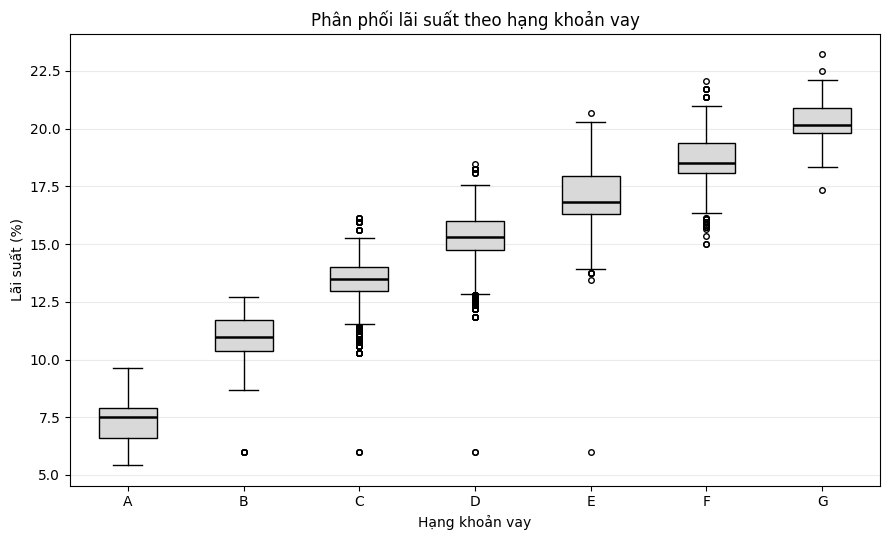

In [49]:
import matplotlib.pyplot as plt

interest_by_grade = [
    grade_rate_data.loc[
        grade_rate_data["loan_grade"] == grade,
        "loan_int_rate"
    ]
    for grade in grade_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.boxplot(
    interest_by_grade,
    tick_labels=grade_order,
    showfliers=True,
    patch_artist=True,
    boxprops={
        "facecolor": "0.85",
        "edgecolor": "black"
    },
    medianprops={
        "color": "black",
        "linewidth": 1.8
    },
    whiskerprops={
        "color": "black"
    },
    capprops={
        "color": "black"
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "none",
        "markeredgecolor": "black",
        "markersize": 4
    }
)

ax.set_title("Phân phối lãi suất theo hạng khoản vay")
ax.set_xlabel("Hạng khoản vay")
ax.set_ylabel("Lãi suất (%)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig.savefig(
    "interest_rate_by_loan_grade.pdf",
    bbox_inches="tight"
)

plt.show()

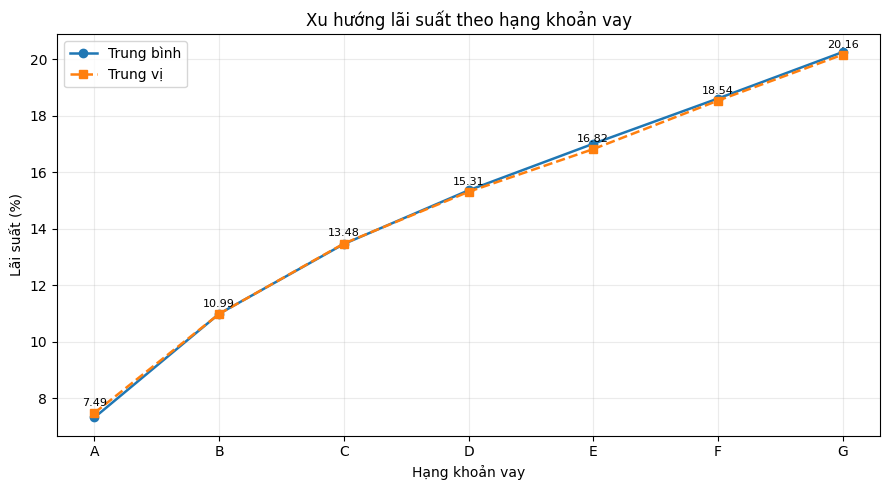

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    grade_order,
    grade_interest_summary["mean"],
    marker="o",
    linewidth=1.8,
    label="Trung bình"
)

ax.plot(
    grade_order,
    grade_interest_summary["median"],
    marker="s",
    linestyle="--",
    linewidth=1.8,
    label="Trung vị"
)

for grade, value in zip(
    grade_order,
    grade_interest_summary["median"]
):
    ax.text(
        grade,
        value + 0.25,
        f"{value:.2f}",
        ha="center",
        fontsize=8
    )

ax.set_title("Xu hướng lãi suất theo hạng khoản vay")
ax.set_xlabel("Hạng khoản vay")
ax.set_ylabel("Lãi suất (%)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét về mối quan hệ giữa hạng khoản vay và lãi suất**

Lãi suất có xu hướng tăng rõ rệt và nhất quán khi hạng khoản vay chuyển từ A
đến G. Trung vị lãi suất tăng từ 7,49% ở hạng A lên 10,99% ở hạng B, 13,48%
ở hạng C, 15,31% ở hạng D, 16,82% ở hạng E, 18,54% ở hạng F và 20,16% ở
hạng G.

Giá trị trung bình và trung vị trong mỗi hạng gần như trùng nhau, cho thấy phân
phối lãi suất trong từng nhóm không bị lệch mạnh. Đồng thời, khoảng tứ phân vị
của các hạng nhìn chung dịch chuyển dần lên trên và chỉ chồng lấn ở mức hạn chế.
Sự biến động lãi suất trong từng hạng nhỏ hơn đáng kể so với mức chênh lệch
lãi suất giữa các hạng.

Kết quả này cho thấy `loan_grade` và `loan_int_rate` chứa lượng thông tin trùng
lặp đáng kể. Hạng khoản vay có thể được sử dụng như một cơ sở để xác định mức
lãi suất: các khoản vay được đánh giá có rủi ro cao hơn thường được áp dụng lãi
suất cao hơn.

Tuy nhiên, số lượng quan sát giảm mạnh ở các hạng rủi ro cao. Sau khi loại các
quan sát thiếu lãi suất, hạng F chỉ còn 214 quan sát và hạng G chỉ còn 59 quan
sát. Vì vậy, các thống kê của hai nhóm này có mức độ bất định cao hơn và cần
được diễn giải thận trọng.

Một số giá trị lãi suất khoảng 6% xuất hiện như ngoại lệ trong các hạng B, C,
D và E. Các quan sát này nên được kiểm tra riêng để xác định liệu chúng là
những mức lãi suất hợp lệ hay biểu hiện của vấn đề chất lượng dữ liệu.

Nhìn chung, kết quả trực quan cung cấp bằng chứng mạnh rằng lãi suất tăng theo
mức rủi ro của hạng khoản vay. Tuy nhiên, mối quan hệ này chỉ phản ánh sự liên
kết giữa hai biến và không chứng minh rằng sự thay đổi hạng khoản vay trực tiếp
gây ra thay đổi lãi suất.

## 5.6.  Phân tích giá trị thiếu

Giá trị thiếu được kiểm tra về số lượng, tỷ lệ và mối liên hệ với biến mục
tiêu. Đối với mỗi biến có dữ liệu thiếu, tỷ lệ vỡ nợ của nhóm thiếu được so
sánh với nhóm có quan sát đầy đủ.

Nếu hai nhóm có tỷ lệ vỡ nợ khác biệt đáng kể, trạng thái thiếu có thể mang
thông tin dự báo và cần được xem xét như một nhóm riêng trong quá trình
binning và chuyển đổi WOE.

In [54]:
missing_summary = pd.DataFrame({
    "Số giá trị thiếu": df.isna().sum(),
    "Tỷ lệ thiếu (%)": df.isna().mean().mul(100)
})

missing_summary = (
    missing_summary[
        missing_summary["Số giá trị thiếu"] > 0
    ]
    .sort_values(
        "Tỷ lệ thiếu (%)",
        ascending=False
    )
)

display(missing_summary.round(2))

,Số giá trị thiếu,Tỷ lệ thiếu (%)
Biến,,
loan_int_rate,3116,9.56
person_emp_length,895,2.75


In [55]:
missing_default_results = []

for feature in missing_summary.index:

    missing_indicator = df[feature].isna()

    missing_default_results.append({
        "Biến": feature,
        "Nhóm": "Thiếu",
        "Số quan sát": missing_indicator.sum(),
        "Tỷ lệ vỡ nợ (%)": (
            df.loc[
                missing_indicator,
                "loan_status"
            ].mean() * 100
        )
    })

    missing_default_results.append({
        "Biến": feature,
        "Nhóm": "Không thiếu",
        "Số quan sát": (~missing_indicator).sum(),
        "Tỷ lệ vỡ nợ (%)": (
            df.loc[
                ~missing_indicator,
                "loan_status"
            ].mean() * 100
        )
    })

missing_default_table = pd.DataFrame(
    missing_default_results
)

display(
    missing_default_table.round(2)
)

,Biến,Nhóm,Số quan sát,Tỷ lệ vỡ nợ (%)
0,loan_int_rate,Thiếu,3116,20.67
1,loan_int_rate,Không thiếu,29465,21.94
2,person_emp_length,Thiếu,895,31.51
3,person_emp_length,Không thiếu,31686,21.54


In [56]:
quality_checks = {
    "Tuổi nhỏ hơn 18": (
        df["person_age"] < 18
    ),

    "Tuổi lớn hơn 100": (
        df["person_age"] > 100
    ),

    "Thu nhập không dương": (
        df["person_income"] <= 0
    ),

    "Thời gian làm việc âm": (
        df["person_emp_length"] < 0
    ),

    "Thời gian làm việc lớn hơn tuổi": (
        df["person_emp_length"]
        > df["person_age"]
    ),

    "Thời gian làm việc lớn hơn tuổi trừ 14": (
        df["person_emp_length"]
        > df["person_age"] - 14
    ),

    "Số tiền vay không dương": (
        df["loan_amnt"] <= 0
    ),

    "Lãi suất không dương": (
        df["loan_int_rate"] <= 0
    ),

    "Tỷ lệ khoản vay trên thu nhập âm": (
        df["loan_percent_income"] < 0
    ),

    "Lịch sử tín dụng dài hơn tuổi": (
        df["cb_person_cred_hist_length"]
        > df["person_age"]
    )
}

quality_check_table = pd.DataFrame({
    "Vấn đề": quality_checks.keys(),
    "Số quan sát": [
        condition.fillna(False).sum()
        for condition in quality_checks.values()
    ]
})

quality_check_table["Tỷ lệ (%)"] = (
    quality_check_table["Số quan sát"]
    .div(len(df))
    .mul(100)
)

display(
    quality_check_table
    .sort_values(
        "Số quan sát",
        ascending=False
    )
    .round(3)
)

,Vấn đề,Số quan sát,Tỷ lệ (%)
1,Tuổi lớn hơn 100,5,0.015
5,Thời gian làm việc lớn hơn tuổi trừ 14,2,0.006
4,Thời gian làm việc lớn hơn tuổi,2,0.006
0,Tuổi nhỏ hơn 18,0,0.000
3,Thời gian làm việc âm,0,0.000
2,Thu nhập không dương,0,0.000
6,Số tiền vay không dương,0,0.000
7,Lãi suất không dương,0,0.000
8,Tỷ lệ khoản vay trên thu nhập âm,0,0.000
9,Lịch sử tín dụng dài hơn tuổi,0,0.000


In [57]:
duplicate_count = df.duplicated().sum()

print(
    f"Số dòng trùng lặp hoàn toàn: "
    f"{duplicate_count:,}"
)

print(
    f"Tỷ lệ trùng lặp: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

Số dòng trùng lặp hoàn toàn: 165
Tỷ lệ trùng lặp: 0.51%


In [58]:
suspicious_rows = df[
    (df["person_age"] > 100)
    | (
        df["person_emp_length"]
        > df["person_age"] - 14
    )
]

display(suspicious_rows)

Biến,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


### Nhận xét về chất lượng dữ liệu

Kết quả kiểm tra cho thấy dữ liệu có giá trị thiếu tại hai biến
`loan_int_rate` và `person_emp_length`.

Biến `loan_int_rate` có 3.116 giá trị thiếu, tương ứng 9,56% tổng số quan sát.
Tỷ lệ vỡ nợ của nhóm thiếu lãi suất là 20,67%, trong khi nhóm có thông tin lãi
suất là 21,94%. Mức chênh lệch 1,27 điểm phần trăm tương đối nhỏ, cho thấy
trạng thái thiếu của biến này chưa thể hiện khả năng phân biệt rõ ràng đối với
trạng thái vỡ nợ.

Biến `person_emp_length` có 895 giá trị thiếu, tương ứng 2,75% dữ liệu. Nhóm
thiếu thông tin về thời gian làm việc có tỷ lệ vỡ nợ 31,51%, cao hơn đáng kể
so với mức 21,54% của nhóm không thiếu. Chênh lệch khoảng 9,97 điểm phần trăm
cho thấy việc thiếu thông tin về thời gian làm việc có thể mang thông tin liên
quan đến rủi ro tín dụng. Do đó, trong quá trình binning và tính WOE, nhóm giá
trị thiếu của biến này nên được xem xét như một nhóm riêng thay vì chỉ được
điền bằng một giá trị trung tâm.

Ngoài giá trị thiếu, tập dữ liệu xuất hiện một số giá trị không hợp lý. Có 5
quan sát có tuổi lớn hơn 100, tương ứng 0,015% dữ liệu. Các giá trị bất thường
này gồm tuổi 123 và 144. Đồng thời, có 2 quan sát có thời gian làm việc bằng
123 năm, lớn hơn tuổi của khách hàng và vượt quá phạm vi có thể xảy ra trong
thực tế.

Do không có thông tin để xác định giá trị đúng của những quan sát này, phương
án phù hợp là chuyển riêng các giá trị không hợp lý thành giá trị thiếu thay
vì thay thế bằng một giá trị tùy ý. Các thông tin hợp lệ còn lại trong cùng
bản ghi vẫn có thể được giữ lại.

Các kiểm tra khác không phát hiện thu nhập hoặc số tiền vay không dương, lãi
suất không dương, tỷ lệ khoản vay trên thu nhập âm hay độ dài lịch sử tín dụng
lớn hơn tuổi của khách hàng.

Tập dữ liệu có 165 dòng trùng lặp hoàn toàn, chiếm 0,51% số quan sát. Tuy
nhiên, do dữ liệu không chứa mã định danh khách hàng, chưa thể khẳng định các
dòng này chắc chắn là cùng một khách hàng bị ghi nhận nhiều lần. Chúng có thể
là các hồ sơ khác nhau nhưng có cùng toàn bộ đặc điểm quan sát được. Vì vậy,
các dòng trùng lặp được ghi nhận như một vấn đề tiềm năng và sẽ được xử lý
thận trọng trong bước tiền xử lý dữ liệu.

In [59]:
model_data = df.copy()

# Chuyển tuổi không hợp lý thành giá trị thiếu.
model_data.loc[
    model_data["person_age"] > 100,
    "person_age"
] = np.nan

# Chuyển thời gian làm việc không hợp lý thành giá trị thiếu.
invalid_emp_length = (
    (model_data["person_emp_length"] > model_data["person_age"])
    | (
        model_data["person_emp_length"]
        > model_data["person_age"] - 14
    )
)

model_data.loc[
    invalid_emp_length,
    "person_emp_length"
] = np.nan

In [60]:
duplicate_frequency = (
    df.groupby(df.columns.tolist(), dropna=False)
    .size()
    .reset_index(name="frequency")
    .query("frequency > 1")
    .sort_values("frequency", ascending=False)
)

display(duplicate_frequency.head(20))

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,frequency
21,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2,2
101,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4,2
125,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2,2
171,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3,2
205,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3,2
305,21,26000,RENT,5.0,DEBTCONSOLIDATION,A,6000,7.49,0,0.23,N,2,2
316,21,26400,RENT,5.0,PERSONAL,C,4750,12.23,0,0.18,N,3,2
337,21,27600,RENT,4.0,EDUCATION,A,7500,6.76,0,0.27,N,4,2
355,21,28692,MORTGAGE,5.0,EDUCATION,B,3000,10.75,0,0.10,N,2,2
501,21,33009,OWN,5.0,VENTURE,B,12000,11.48,0,0.36,N,4,2


# Data Preprocessing

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Phương pháp chia nhóm dữ liệu và Optimal Binning

## 1. Khái niệm binning

Binning là quá trình chuyển các giá trị của một biến dự báo thành một số lượng hữu hạn các nhóm, được gọi là các **bin**.

Đối với biến định lượng, mỗi bin thường là một khoảng giá trị. Ví dụ, biến `person_income` có thể được chia thành các khoảng:

$$
(-\infty, 24\,228),\qquad
[24\,228, 34\,999.5),\qquad
[34\,999.5, 39\,937.5),\ldots
$$

Những khách hàng có thu nhập nằm trong cùng một khoảng sẽ được xếp vào cùng một nhóm rủi ro.

Đối với biến phân loại, mỗi bin có thể là một giá trị phân loại riêng hoặc là tập hợp của nhiều giá trị có đặc điểm rủi ro tương tự. Ví dụ, biến `loan_grade` có thể gồm các bin:

$$
A,\quad B,\quad C,\quad D,\quad E,\quad F,\quad G.
$$

Binning thường được sử dụng trong mô hình điểm tín dụng nhằm:

- giảm ảnh hưởng của nhiễu và giá trị ngoại lệ;
- biểu diễn các mối quan hệ phi tuyến giữa biến dự báo và rủi ro vỡ nợ;
- tăng khả năng giải thích của mô hình;
- tạo cơ sở để tính Weight of Evidence (WOE);
- tạo cơ sở để tính Information Value (IV);
- chuyển các biến có thang đo khác nhau về cùng một dạng biểu diễn.

---

## 2. Quy ước biến mục tiêu

Trong tập dữ liệu, biến mục tiêu `loan_status` được quy ước như sau:

$$
Y=
\begin{cases}
0, & \text{khách hàng không vỡ nợ, gọi là Good hoặc No hit},\\
1, & \text{khách hàng vỡ nợ, gọi là Bad hoặc Hit}.
\end{cases}
$$

Với bin thứ $j$, ký hiệu:

- $G_j$: số khách hàng không vỡ nợ trong bin;
- $B_j$: số khách hàng vỡ nợ trong bin;
- $N_j=G_j+B_j$: tổng số quan sát trong bin.

Tỷ lệ vỡ nợ trong bin thứ $j$ được xác định bởi:

$$
\operatorname{DefaultRate}_j
=
\frac{B_j}{N_j}.
$$

Trong biểu đồ binning:

- chiều cao của cột biểu diễn số quan sát $N_j$;
- đường biểu diễn tỷ lệ vỡ nợ của từng bin.

Việc trình bày đồng thời hai đại lượng này giúp tránh diễn giải quá mức đối với những bin có tỷ lệ vỡ nợ cao nhưng số lượng quan sát quá nhỏ.

---

## 3. Các phương pháp chia bin phổ biến

### 3.1. Chia khoảng có độ rộng bằng nhau

Phương pháp này chia miền giá trị của biến thành các khoảng có cùng độ rộng.

Ví dụ, nếu thu nhập nằm trong khoảng từ 10.000 đến 100.000 và được chia thành ba bin, ta có thể thu được:

$$
[10\,000,40\,000),\qquad
[40\,000,70\,000),\qquad
[70\,000,100\,000].
$$

Phương pháp này đơn giản nhưng không xem xét:

- số lượng quan sát trong mỗi bin;
- tỷ lệ vỡ nợ trong từng bin;
- khả năng phân biệt giữa nhóm Good và Bad.

### 3.2. Chia theo phân vị

Phương pháp chia theo phân vị tạo ra các bin có số lượng quan sát gần bằng nhau.

Ví dụ, khi chia thành bốn bin, các điểm cắt có thể được xác định tại các phân vị:

$$
25\%,\qquad 50\%,\qquad 75\%.
$$

Cách chia này kiểm soát được kích thước bin nhưng không tối ưu trực tiếp khả năng phân biệt giữa khách hàng vỡ nợ và không vỡ nợ.

### 3.3. Optimal binning

Optimal binning là phương pháp chia bin có giám sát. Phương pháp này sử dụng đồng thời:

- giá trị của biến dự báo;
- biến mục tiêu `loan_status`;
- phân phối Good và Bad;
- tỷ lệ vỡ nợ trong các nhóm;
- các ràng buộc về số lượng và kích thước bin.

Mục tiêu của optimal binning là tìm các điểm cắt sao cho các bin cuối cùng phân biệt tốt nhất giữa khách hàng vỡ nợ và không vỡ nợ, đồng thời vẫn bảo đảm tính ổn định và khả năng giải thích.

---

## 4. Quy trình xác định optimal bin

Quá trình optimal binning đối với một biến định lượng thường gồm hai giai đoạn:

$$
\text{Pre-binning}
\longrightarrow
\text{Optimization}.
$$

### 4.1. Giai đoạn pre-binning

Trước tiên, miền giá trị của biến được chia thành nhiều nhóm nhỏ, gọi là **pre-bin**.

Phương pháp pre-binning thường sử dụng cây quyết định để tìm các điểm cắt ban đầu. Cây quyết định sử dụng biến mục tiêu để xác định những vị trí mà tỷ lệ vỡ nợ thay đổi đáng kể.

Giả sử các điểm cắt sơ bộ được xác định là:

$$
s_1<s_2<\cdots<s_m.
$$

Khi đó, các pre-bin được tạo thành:

$$
(-\infty,s_1),\quad
[s_1,s_2),\quad
\ldots,\quad
[s_m,+\infty).
$$

Ví dụ, nếu các điểm cắt sơ bộ của biến tuổi là:

$$
22.5,\quad25.5,\quad28.5,\quad35.5,
$$

thì các pre-bin tương ứng là:

$$
(-\infty,22.5),\quad
[22.5,25.5),\quad
[25.5,28.5),\quad
[28.5,35.5),\quad
[35.5,+\infty).
$$

Các điểm cắt như 22.5 xuất hiện do dữ liệu tuổi thường nhận giá trị nguyên. Ranh giới 22.5 được hiểu là điểm nằm giữa tuổi 22 và tuổi 23.

### 4.2. Tinh chỉnh pre-bin

Một pre-bin có thể chỉ chứa khách hàng Good hoặc chỉ chứa khách hàng Bad.

Trong trường hợp đó:

$$
\operatorname{DistGood}_j=0
$$

hoặc:

$$
\operatorname{DistBad}_j=0.
$$

Khi đó, WOE có thể trở thành vô hạn hoặc không xác định.

Vì vậy, những pre-bin thuần nhất thường được gộp với một pre-bin lân cận trước khi bước tối ưu được thực hiện.

### 4.3. Tối ưu việc gộp pre-bin

Sau khi tạo các pre-bin, thuật toán không tìm thêm các điểm cắt hoàn toàn mới. Thay vào đó, thuật toán quyết định:

- giữ một ranh giới giữa hai pre-bin;
- hoặc loại bỏ ranh giới để gộp hai pre-bin liền kề.

Đối với biến định lượng, chỉ những pre-bin liên tiếp mới được phép gộp.

Giả sử có sáu pre-bin:

$$
P_1,P_2,P_3,P_4,P_5,P_6.
$$

Một phương án gộp hợp lệ có thể là:

$$
B_1=P_1,
$$

$$
B_2=P_2\cup P_3,
$$

$$
B_3=P_4\cup P_5,
$$

$$
B_4=P_6.
$$

Tuy nhiên, không thể tạo một bin có dạng:

$$
P_1\cup P_4,
$$

vì hai khoảng này không nằm liền nhau trên trục số.

---

## 5. Weight of Evidence

Với mỗi bin $j$, tỷ trọng khách hàng không vỡ nợ được tính bởi:

$$
\operatorname{DistGood}_j
=
\frac{G_j}
{\sum_{k=1}^{K}G_k},
$$

trong đó $K$ là tổng số bin.

Tương tự, tỷ trọng khách hàng vỡ nợ được tính bởi:

$$
\operatorname{DistBad}_j
=
\frac{B_j}
{\sum_{k=1}^{K}B_k}.
$$

Weight of Evidence của bin thứ $j$ được xác định bởi:

$$
WOE_j
=
\ln
\left(
\frac{\operatorname{DistGood}_j}
{\operatorname{DistBad}_j}
\right).
$$

Theo quy ước trên:

- $WOE_j>0$ cho thấy bin có tỷ trọng Good lớn hơn tỷ trọng Bad;
- $WOE_j<0$ cho thấy bin có tỷ trọng Bad lớn hơn tỷ trọng Good;
- $WOE_j\approx0$ cho thấy bin không phân biệt rõ hai nhóm.

Dấu của WOE có thể đảo ngược nếu sử dụng công thức:

$$
WOE_j
=
\ln
\left(
\frac{\operatorname{DistBad}_j}
{\operatorname{DistGood}_j}
\right).
$$

Việc lựa chọn quy ước không làm thay đổi IV nếu công thức được sử dụng nhất quán trong toàn bộ quá trình phân tích.

---

## 6. Information Value

IV thành phần của bin thứ $j$ được tính bởi:

$$
IV_j
=
\left(
\operatorname{DistGood}_j
-
\operatorname{DistBad}_j
\right)WOE_j.
$$

IV tổng của biến là:

$$
IV
=
\sum_{j=1}^{K}IV_j.
$$

IV đo lường mức độ khác biệt giữa phân phối Good và phân phối Bad trên toàn bộ các bin.

Giá trị IV thường được diễn giải như sau:

| Khoảng IV | Mức độ phân biệt |
|---:|---|
| $IV<0.02$ | Hầu như không có khả năng phân biệt |
| $0.02\le IV<0.10$ | Khả năng phân biệt yếu |
| $0.10\le IV<0.30$ | Khả năng phân biệt trung bình |
| $0.30\le IV<0.50$ | Khả năng phân biệt mạnh |
| $IV\ge0.50$ | Khả năng phân biệt rất mạnh, cần kiểm tra thêm |

IV rất cao không nhất thiết có nghĩa biến chắc chắn tốt cho mô hình. Nó có thể xuất phát từ:

- khả năng dự báo thực sự mạnh;
- các bin có số quan sát quá nhỏ;
- tỷ lệ vỡ nợ cực đoan;
- điểm cắt quá phù hợp với dữ liệu huấn luyện;
- thông tin trùng lặp với biến khác;
- rò rỉ thông tin;
- biến là kết quả của một quy trình thẩm định đã tồn tại trước đó.

---

## 7. Hàm mục tiêu của optimal binning

Đối với bài toán phân loại nhị phân, optimal binning có thể được mô tả bằng bài toán:

$$
\max_{\mathcal{B}}
\quad
IV(\mathcal{B}),
$$

trong đó $\mathcal{B}$ là một phương án gộp các pre-bin.

Với mỗi phương án chia bin, thuật toán thực hiện:

1. tính số Good và Bad trong từng bin;
2. tính phân phối Good và Bad;
3. tính WOE của từng bin;
4. tính IV thành phần;
5. tính IV tổng;
6. kiểm tra các ràng buộc;
7. so sánh với các phương án chia bin khác.

Phương án được lựa chọn là phương án có giá trị hàm mục tiêu tốt nhất và đồng thời thỏa mãn các ràng buộc đã thiết lập.

Optimal binning vì vậy không đơn giản là chọn riêng lẻ những điểm có tỷ lệ vỡ nợ chênh lệch lớn nhất. Thuật toán tối ưu đồng thời toàn bộ hệ thống bin.

---

## 8. Ví dụ minh họa quá trình lựa chọn bin

Giả sử một biến được chia sơ bộ thành bốn pre-bin:

| Pre-bin | Good | Bad | Tỷ lệ vỡ nợ |
|---|---:|---:|---:|
| $P_1$ | 900 | 100 | 10% |
| $P_2$ | 820 | 180 | 18% |
| $P_3$ | 510 | 490 | 49% |
| $P_4$ | 300 | 700 | 70% |

Thuật toán có thể xem xét nhiều phương án.

### Phương án 1: Giữ nguyên bốn bin

$$
\{P_1\},\{P_2\},\{P_3\},\{P_4\}.
$$

### Phương án 2: Gộp hai bin đầu

$$
\{P_1\cup P_2\},\{P_3\},\{P_4\}.
$$

### Phương án 3: Gộp hai bin giữa

$$
\{P_1\},\{P_2\cup P_3\},\{P_4\}.
$$

### Phương án 4: Chỉ giữ hai bin

$$
\{P_1\cup P_2\},\{P_3\cup P_4\}.
$$

Đối với mỗi phương án, thuật toán tính lại WOE và IV. Sau đó, phương án có IV tốt nhất và thỏa mãn các điều kiện về kích thước bin, số lượng bin và xu hướng rủi ro sẽ được lựa chọn.

---

## 9. Các ràng buộc của bài toán optimal binning

Ngoài việc tối đa hóa IV, quá trình tối ưu có thể chịu các ràng buộc sau.

### 9.1. Giới hạn số bin

Số bin cuối cùng có thể được giới hạn bởi:

$$
K\leq K_{\max}.
$$

Trong nghiên cứu này:

```python
max_n_bins = 6
```

Do đó:

$$
K\leq6.
$$

Tham số này không bắt buộc thuật toán phải tạo đúng sáu bin. Thuật toán có thể tạo ít hơn sáu bin nếu phương án đó phù hợp hơn.

### 9.2. Kích thước tối thiểu của bin

Mỗi bin cần có số lượng quan sát đủ lớn. Một ràng buộc có thể được biểu diễn dưới dạng:

$$
N_j\geq N_{\min}.
$$

Điều này giúp hạn chế các bin nhỏ, vốn có thể tạo ra tỷ lệ vỡ nợ và WOE không ổn định.

### 9.3. Số lượng Good và Bad tối thiểu

Có thể yêu cầu mỗi bin chứa ít nhất một số lượng Good và Bad nhất định:

$$
G_j\geq G_{\min},
$$

$$
B_j\geq B_{\min}.
$$

### 9.4. Ràng buộc đơn điệu

Trong một số trường hợp, tỷ lệ vỡ nợ được yêu cầu tăng hoặc giảm theo giá trị của biến.

Ví dụ:

- thu nhập tăng thì tỷ lệ vỡ nợ giảm;
- tỷ lệ khoản vay trên thu nhập tăng thì tỷ lệ vỡ nợ tăng;
- lãi suất tăng thì tỷ lệ vỡ nợ tăng.

Ràng buộc tăng dần có thể biểu diễn bởi:

$$
\operatorname{DefaultRate}_1
\leq
\operatorname{DefaultRate}_2
\leq
\cdots
\leq
\operatorname{DefaultRate}_K.
$$

Ràng buộc giảm dần được biểu diễn bởi:

$$
\operatorname{DefaultRate}_1
\geq
\operatorname{DefaultRate}_2
\geq
\cdots
\geq
\operatorname{DefaultRate}_K.
$$

Không nên ép xu hướng đơn điệu cho mọi biến. Một số biến, chẳng hạn `loan_amnt`, có thể có mối quan hệ phi tuyến hoặc dạng chữ U với rủi ro vỡ nợ.

---

## 10. Ý nghĩa của `solver="cp"`

Trong đoạn lệnh:

```python
optb = OptimalBinning(
    name=column,
    dtype="numerical",
    solver="cp",
    max_n_bins=6
)
```

tham số:

```python
solver="cp"
```

yêu cầu thư viện sử dụng bộ giải **Constraint Programming**.

Bộ giải sẽ tìm cách giữ hoặc loại bỏ các ranh giới giữa những pre-bin sao cho:

- các ràng buộc được đáp ứng;
- số bin không vượt quá giới hạn;
- hàm mục tiêu đạt giá trị tốt nhất.

Sau khi huấn luyện, có thể kiểm tra trạng thái lời giải bằng:

```python
print(optb.status)
```

Nếu kết quả là:

```text
OPTIMAL
```

thì bộ giải đã tìm được nghiệm tối ưu trong không gian các phương án được xét.

Các điểm cắt cuối cùng có thể được xem bằng:

```python
print(optb.splits)
```

---

## 11. Cách hiểu các khoảng bin

Trong quá trình tạo bin, câu lệnh sau được sử dụng:

```python
pd.cut(
    working_data[column],
    bins=bin_edges,
    right=False,
    include_lowest=True
)
```

Tham số:

```python
right=False
```

tạo các khoảng dạng:

$$
[a,b).
$$

Khoảng này:

- bao gồm cận trái $a$;
- không bao gồm cận phải $b$.

Ví dụ:

$$
[22.5,25.5)
$$

được hiểu là:

$$
22.5\leq x<25.5.
$$

Một khách hàng 25 tuổi thuộc bin này, trong khi giá trị 25.5 thuộc bin kế tiếp.

Hai đầu của miền giá trị được biểu diễn bằng:

$$
-\infty
\quad\text{và}\quad
+\infty.
$$

Việc sử dụng vô cực tốt hơn so với những giá trị nhân tạo rất lớn vì nó bảo đảm dữ liệu mới luôn được gán vào một bin, kể cả khi nằm ngoài phạm vi quan sát của dữ liệu huấn luyện.

---

## 12. Chia bin cho biến phân loại

Trong hàm hiện tại, các biến định lượng được đưa vào `OptimalBinning`, trong khi các biến phân loại được xử lý bằng cách giữ từng category thành một bin riêng.

Các biến phân loại gồm:

- `person_home_ownership`;
- `loan_intent`;
- `loan_grade`;
- `cb_person_default_on_file`.

Ví dụ, biến `loan_grade` được giữ thành các bin:

$$
A,\quad B,\quad C,\quad D,\quad E,\quad F,\quad G.
$$

Biến `person_home_ownership` gồm các bin:

$$
\text{RENT},\quad
\text{MORTGAGE},\quad
\text{OWN},\quad
\text{OTHER}.
$$

Trong cách triển khai hiện tại, thuật toán không tự động gộp các category. Vì vậy, IV của biến phân loại được tính từ các nhóm ban đầu.

Nếu muốn tối ưu việc gộp nhóm phân loại, có thể sử dụng:

```python
OptimalBinning(
    name=column,
    dtype="categorical",
    solver="cp",
    max_n_bins=6
)
```

Khi đó, các category có tỷ lệ vỡ nợ tương tự có thể được gộp vào cùng một bin.

Ví dụ, các hạng `E`, `F` và `G` của `loan_grade` có tỷ lệ vỡ nợ cao nhưng số lượng quan sát nhỏ. Chúng có thể được xem xét gộp nếu WOE tương đối gần nhau và việc gộp phù hợp với ý nghĩa nghiệp vụ.

---

## 13. Xử lý giá trị thiếu

Giá trị thiếu được giữ thành một bin riêng có tên `Missing`.

Đối với biến định lượng, optimal binning được huấn luyện trên các quan sát không thiếu. Sau khi tìm được điểm cắt, những quan sát thiếu được gán vào bin `Missing`.

Cách xử lý này cho phép trạng thái thiếu trở thành một nguồn thông tin dự báo.

Ví dụ, biến `person_emp_length` có nhóm thiếu với tỷ lệ vỡ nợ cao hơn nhóm không thiếu. Nếu điền toàn bộ giá trị thiếu bằng trung bình hoặc trung vị, thông tin này có thể bị mất.

Việc giữ bin `Missing` đặc biệt phù hợp khi:

- trạng thái thiếu có liên hệ với biến mục tiêu;
- không có cơ sở chắc chắn để điền một giá trị cụ thể;
- cần duy trì khả năng giải thích của scorecard.

---

## 14. Smoothing khi tính WOE

Nếu một bin không có Good hoặc không có Bad thì:

$$
\operatorname{DistGood}_j=0
$$

hoặc:

$$
\operatorname{DistBad}_j=0.
$$

Khi đó, WOE có thể không xác định.

Để tránh tình trạng này, một hằng số nhỏ được cộng vào số lượng Good và Bad:

```python
smoothing = 0.5
```

Phân phối Good sau hiệu chỉnh được tính bởi:

$$
\widehat{\operatorname{DistGood}}_j
=
\frac{G_j+0.5}
{G+0.5K},
$$

trong đó:

$$
G=\sum_{j=1}^{K}G_j.
$$

Tương tự:

$$
\widehat{\operatorname{DistBad}}_j
=
\frac{B_j+0.5}
{B+0.5K},
$$

với:

$$
B=\sum_{j=1}^{K}B_j.
$$

Smoothing giúp tránh WOE vô hạn nhưng có thể ảnh hưởng đáng kể đến những bin có ít quan sát. Vì vậy, các bin nhỏ vẫn cần được xem xét gộp lại.

---

## 15. Tiêu chí đánh giá chất lượng bin

Một hệ thống binning tốt không chỉ cần có IV cao mà còn phải đáp ứng các yêu cầu sau.

### Kích thước bin đủ lớn

Mỗi bin cần chứa đủ quan sát để tỷ lệ vỡ nợ và WOE có độ ổn định.

### Có đủ Good và Bad

Một bin chỉ chứa Good hoặc chỉ chứa Bad thường cho thấy bin quá nhỏ hoặc dữ liệu bị chia quá chi tiết.

### Tỷ lệ vỡ nợ có sự khác biệt

Các bin nên thể hiện mức rủi ro khác nhau rõ ràng. Hai bin liên tiếp có tỷ lệ vỡ nợ gần giống nhau có thể được xem xét gộp.

### Xu hướng phù hợp với nghiệp vụ

Ví dụ:

- thu nhập tăng thì rủi ro thường giảm;
- tỷ lệ khoản vay trên thu nhập tăng thì rủi ro thường tăng;
- hạng khoản vay xấu đi thì rủi ro thường tăng.

### Điểm cắt có khả năng giải thích

Các điểm cắt dễ hiểu như 20%, 30% hoặc 40% thường thuận tiện hơn khi triển khai so với các giá trị quá chi tiết.

### Ổn định trên dữ liệu mới

Một binning có IV cao trên dữ liệu huấn luyện nhưng thay đổi mạnh trên dữ liệu mới có thể không phù hợp để triển khai thực tế.

---

## 16. Diễn giải kết quả optimal binning trong nghiên cứu

Trong nghiên cứu này, các biến định lượng được chia thành tối đa sáu bin bằng phương pháp optimal binning.

Các điểm cắt được lựa chọn dựa trên khả năng phân biệt giữa khách hàng vỡ nợ và không vỡ nợ. Sau khi các bin được xác định, tỷ lệ vỡ nợ, WOE và IV được tính cho từng nhóm.

Kết quả cho thấy các biến như:

- `loan_percent_income`;
- `loan_grade`;
- `loan_int_rate`;
- `person_income`;
- `person_home_ownership`;
- `cb_person_default_on_file`;

có khả năng phân biệt cao hơn những biến còn lại.

Đặc biệt, `loan_percent_income` có tỷ lệ vỡ nợ tăng mạnh khi tỷ lệ khoản vay trên thu nhập vượt qua một số ngưỡng. Điều này cho thấy khả năng trả nợ suy giảm rõ rệt khi nghĩa vụ vay trở nên quá lớn so với thu nhập.

Tương tự, tỷ lệ vỡ nợ tăng mạnh khi `loan_grade` chuyển từ các hạng A, B và C sang các hạng D, E, F và G.

Tuy nhiên, IV cao không được sử dụng như tiêu chí duy nhất để lựa chọn biến. Các biến có IV cao vẫn cần được kiểm tra về:

- kích thước bin;
- tính ổn định của WOE;
- mối quan hệ với nghiệp vụ;
- thông tin trùng lặp;
- khả năng rò rỉ thông tin;
- tính sẵn có tại thời điểm chấm điểm.

---

## 17. Tóm tắt quy trình optimal binning

Quy trình chia bin có thể được tóm tắt như sau:

1. Chọn một biến dự báo và biến mục tiêu `loan_status`.
2. Tách giá trị thiếu thành bin `Missing`.
3. Sử dụng cây quyết định để tìm các điểm cắt sơ bộ.
4. Tạo các pre-bin liên tiếp.
5. Tinh chỉnh các pre-bin không có đủ Good hoặc Bad.
6. Sử dụng bộ giải Constraint Programming.
7. Xem xét các phương án giữ hoặc gộp ranh giới giữa những pre-bin.
8. Tối ưu IV với số bin tối đa bằng 6.
9. Tính số quan sát và tỷ lệ vỡ nợ của từng bin.
10. Tính DistGood và DistBad.
11. Tính WOE của từng bin.
12. Tính IV thành phần và IV tổng.
13. Kiểm tra kích thước bin, xu hướng rủi ro và ý nghĩa nghiệp vụ.
14. Điều chỉnh hoặc gộp các bin chưa ổn định khi cần thiết.

Có thể biểu diễn toàn bộ quy trình bằng:

$$
\boxed{
\text{Dữ liệu gốc}
\rightarrow
\text{Pre-binning}
\rightarrow
\text{Tối ưu gộp bin}
\rightarrow
\text{Default Rate}
\rightarrow
\text{WOE}
\rightarrow
\text{IV}
}
$$

Optimal binning vì vậy không chỉ đơn thuần là chia dữ liệu thành một số lượng khoảng cố định. Đây là quá trình sử dụng thông tin của biến mục tiêu và tối ưu toán học để tìm ra hệ thống bin có khả năng phân biệt tốt giữa khách hàng vỡ nợ và không vỡ nợ, đồng thời bảo đảm các yêu cầu về kích thước, tính ổn định và khả năng giải thích.

In [84]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optbinning import OptimalBinning

In [89]:
data = pd.read_csv("/content/drive/MyDrive/AIO 2026/Conquer/Data/cleaned_dataset.csv")

target = "loan_status"

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

features = numerical_features + categorical_features

In [90]:
if target not in data.columns:
    raise KeyError(f"Không tìm thấy biến mục tiêu: {target}")

target_values = set(
    data[target].dropna().unique()
)

if not target_values.issubset({0, 1}):
    raise ValueError(
        "loan_status phải chỉ nhận hai giá trị 0 và 1. "
        f"Giá trị hiện có: {target_values}"
    )

if target_values != {0, 1}:
    raise ValueError(
        "Dữ liệu phải chứa cả khách hàng không vỡ nợ "
        "và khách hàng vỡ nợ."
    )

print(f"Số quan sát: {len(data):,}")
print(f"Số biến dự báo: {len(features)}")
print(f"Tỷ lệ vỡ nợ: {data[target].mean() * 100:.2f}%")

Số quan sát: 31,679
Số biến dự báo: 11
Tỷ lệ vỡ nợ: 21.54%


In [91]:
def fit_optimal_binning(
    data,
    feature,
    target="loan_status",
    categorical_features=None,
    max_n_bins=6,
    max_n_prebins=20,
    min_prebin_size=0.05,
    monotonic_trend="auto",
    time_limit=100
):
    """
    Thực hiện optimal binning cho một biến dự báo.

    Quy trình:
        1. Pre-binning bằng CART.
        2. Tối ưu cách gộp pre-bin bằng Constraint Programming.
        3. Tối đa hóa Information Value.
        4. Tạo bảng Count, Event rate, WOE và IV.

    Parameters
    ----------
    data : pandas.DataFrame
        Tập dữ liệu huấn luyện.

    feature : str
        Tên biến dự báo.

    target : str
        Biến mục tiêu nhị phân:
            0 = không vỡ nợ;
            1 = vỡ nợ.

    categorical_features : list
        Danh sách biến phân loại.

    max_n_bins : int
        Số bin cuối cùng tối đa.

    max_n_prebins : int
        Số pre-bin tối đa trước bước tối ưu.

    min_prebin_size : float
        Tỷ lệ quan sát tối thiểu của một pre-bin.

    monotonic_trend : str
        Xu hướng event rate:
            "auto", "ascending", "descending",
            "peak", "valley" hoặc None.

    time_limit : int
        Thời gian tối đa dành cho bộ giải.

    Returns
    -------
    fitted_model : OptimalBinning
        Mô hình optimal binning đã fit.

    binning_table : pandas.DataFrame
        Bảng thống kê của các bin.

    iv : float
        Information Value tổng của biến.
    """

    if categorical_features is None:
        categorical_features = []

    if feature not in data.columns:
        raise KeyError(
            f"Không tìm thấy biến {feature} trong dữ liệu."
        )

    working_data = (
        data[[feature, target]]
        .dropna(subset=[target])
        .copy()
    )

    y = (
        working_data[target]
        .astype(int)
        .to_numpy()
    )

    # -----------------------------------------------------
    # Xác định kiểu biến
    # -----------------------------------------------------
    if feature in categorical_features:
        variable_type = "categorical"

        # Giữ NaN để thư viện tạo bin Missing.
        x = (
            working_data[feature]
            .astype(object)
            .to_numpy()
        )

        # Với categorical, các category có thể được gộp tối ưu.
        fitted_model = OptimalBinning(
            name=feature,
            dtype=variable_type,
            prebinning_method="cart",
            solver="cp",
            divergence="iv",
            max_n_prebins=max_n_prebins,
            min_prebin_size=min_prebin_size,
            max_n_bins=max_n_bins,
            time_limit=time_limit
        )

    else:
        variable_type = "numerical"

        x = (
            pd.to_numeric(
                working_data[feature],
                errors="coerce"
            )
            .to_numpy()
        )

        fitted_model = OptimalBinning(
            name=feature,
            dtype=variable_type,

            # Bước 1: CART tạo pre-bin.
            prebinning_method="cart",
            max_n_prebins=max_n_prebins,
            min_prebin_size=min_prebin_size,

            # Bước 2: CP tối ưu cách gộp bin.
            solver="cp",

            # Hàm mục tiêu: tối đa hóa IV.
            divergence="iv",

            # Số bin cuối cùng tối đa.
            max_n_bins=max_n_bins,

            # Tự động xác định xu hướng event rate.
            monotonic_trend=monotonic_trend,

            time_limit=time_limit
        )

    # -----------------------------------------------------
    # Fit optimal binning
    # -----------------------------------------------------
    fitted_model.fit(x, y)

    if fitted_model.status not in {
        "OPTIMAL",
        "FEASIBLE"
    }:
        warnings.warn(
            f"{feature}: trạng thái bộ giải là "
            f"{fitted_model.status}."
        )

    # -----------------------------------------------------
    # Tạo bảng binning
    # -----------------------------------------------------
    binning_table_object = (
        fitted_model.binning_table
    )

    binning_table = (
        binning_table_object.build(
            show_digits=4,
            add_totals=True
        )
    )

    iv = float(
        binning_table_object.iv
    )

    return fitted_model, binning_table, iv

In [92]:
binning_models = {}
binning_tables = {}
iv_results = []

for feature in features:

    model, table, iv = fit_optimal_binning(
        data=data,
        feature=feature,
        target=target,
        categorical_features=categorical_features,
        max_n_bins=6,
        max_n_prebins=20,
        min_prebin_size=0.05,
        monotonic_trend="auto",
        time_limit=100
    )

    binning_models[feature] = model
    binning_tables[feature] = table

    iv_results.append({
        "Variable": feature,
        "Type": (
            "Categorical"
            if feature in categorical_features
            else "Numerical"
        ),
        "Status": model.status,
        "Number of bins": (
            len(table) - 3
            if "Totals" in table.index
            else len(table)
        ),
        "IV": iv
    })

    print(
        f"{feature:<35} "
        f"Status = {model.status:<10} "
        f"IV = {iv:.6f}"
    )

person_age                          Status = OPTIMAL    IV = 0.010244
person_income                       Status = OPTIMAL    IV = 0.520162
person_emp_length                   Status = OPTIMAL    IV = 0.061826
loan_amnt                           Status = OPTIMAL    IV = 0.095848
loan_int_rate                       Status = OPTIMAL    IV = 0.709025
loan_percent_income                 Status = OPTIMAL    IV = 0.957392
cb_person_cred_hist_length          Status = OPTIMAL    IV = 0.004768
person_home_ownership               Status = OPTIMAL    IV = 0.374915
loan_intent                         Status = OPTIMAL    IV = 0.096733
loan_grade                          Status = OPTIMAL    IV = 0.876622
cb_person_default_on_file           Status = OPTIMAL    IV = 0.168780


In [93]:
def classify_iv(iv):
    if pd.isna(iv):
        return "Không xác định"
    elif iv < 0.02:
        return "Hầu như không có khả năng phân biệt"
    elif iv < 0.10:
        return "Khả năng phân biệt yếu"
    elif iv < 0.30:
        return "Khả năng phân biệt trung bình"
    elif iv < 0.50:
        return "Khả năng phân biệt mạnh"
    else:
        return "Khả năng phân biệt rất mạnh"

In [94]:
IV_df = (
    pd.DataFrame(iv_results)
    .sort_values(
        "IV",
        ascending=False
    )
    .reset_index(drop=True)
)

IV_df["Assessment"] = (
    IV_df["IV"]
    .apply(classify_iv)
)

display(
    IV_df.round(4)
)

,Variable,Type,Status,Number of bins,IV,Assessment
0,loan_percent_income,Numerical,OPTIMAL,6,0.9574,Khả năng phân biệt rất mạnh
1,loan_grade,Categorical,OPTIMAL,4,0.8766,Khả năng phân biệt rất mạnh
2,loan_int_rate,Numerical,OPTIMAL,6,0.7090,Khả năng phân biệt rất mạnh
3,person_income,Numerical,OPTIMAL,6,0.5202,Khả năng phân biệt rất mạnh
4,person_home_ownership,Categorical,OPTIMAL,3,0.3749,Khả năng phân biệt mạnh
5,cb_person_default_on_file,Categorical,OPTIMAL,2,0.1688,Khả năng phân biệt trung bình
6,loan_intent,Categorical,OPTIMAL,6,0.0967,Khả năng phân biệt yếu
7,loan_amnt,Numerical,OPTIMAL,6,0.0958,Khả năng phân biệt yếu
8,person_emp_length,Numerical,OPTIMAL,6,0.0618,Khả năng phân biệt yếu
9,person_age,Numerical,OPTIMAL,4,0.0102,Hầu như không có khả năng phân biệt


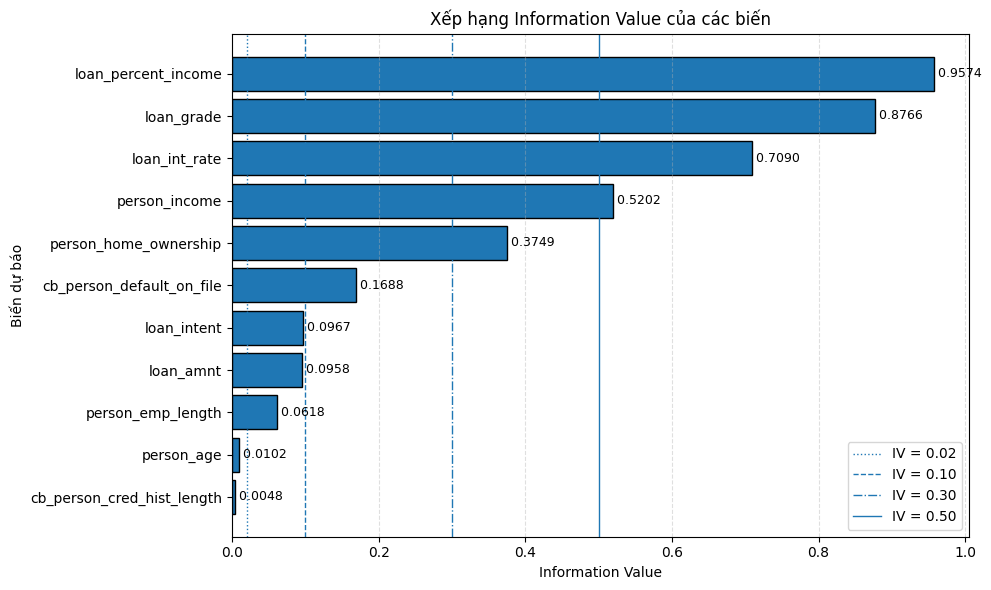

In [109]:
iv_plot = (
    IV_df
    .sort_values(
        "IV",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    iv_plot["Variable"],
    iv_plot["IV"],
    edgecolor="black"
)

for bar, value in zip(
    bars,
    iv_plot["IV"]
):
    ax.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

ax.axvline(
    0.02,
    linestyle=":",
    linewidth=1,
    label="IV = 0.02"
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="IV = 0.10"
)

ax.axvline(
    0.30,
    linestyle="-.",
    linewidth=1,
    label="IV = 0.30"
)

ax.axvline(
    0.50,
    linestyle="-",
    linewidth=1,
    label="IV = 0.50"
)

ax.set_title(
    "Xếp hạng Information Value của các biến"
)

ax.set_xlabel(
    "Information Value"
)

ax.set_ylabel(
    "Biến dự báo"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()

In [95]:
display(
    IV_df[
        [
            "Variable",
            "Number of bins",
            "IV",
            "Assessment"
        ]
    ].round(4)
)

,Variable,Number of bins,IV,Assessment
0,loan_percent_income,6,0.9574,Khả năng phân biệt rất mạnh
1,loan_grade,4,0.8766,Khả năng phân biệt rất mạnh
2,loan_int_rate,6,0.7090,Khả năng phân biệt rất mạnh
3,person_income,6,0.5202,Khả năng phân biệt rất mạnh
4,person_home_ownership,3,0.3749,Khả năng phân biệt mạnh
5,cb_person_default_on_file,2,0.1688,Khả năng phân biệt trung bình
6,loan_intent,6,0.0967,Khả năng phân biệt yếu
7,loan_amnt,6,0.0958,Khả năng phân biệt yếu
8,person_emp_length,6,0.0618,Khả năng phân biệt yếu
9,person_age,4,0.0102,Hầu như không có khả năng phân biệt


In [96]:
display(
    binning_tables[
        "loan_percent_income"
    ].round(4)
)

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.0750)",5978,0.1887,5342,636,0.1064,0.83573,0.1017,0.0124
1,"[0.0750, 0.1550)",10808,0.3412,9424,1384,0.1281,0.625855,0.1104,0.0136
2,"[0.1550, 0.2550)",8854,0.2795,7240,1614,0.1823,0.208479,0.0114,0.0014
3,"[0.2550, 0.3050)",2371,0.0748,1768,603,0.2543,-0.216739,0.0037,0.0005
4,"[0.3050, 0.3750)",2024,0.0639,639,1385,0.6843,-2.065977,0.3661,0.0390
5,"[0.3750, inf)",1644,0.0519,441,1203,0.7318,-2.295955,0.3640,0.0376
6,Special,0,0.0000,0,0,0.0000,0.0,0.0000,0.0000
7,Missing,0,0.0000,0,0,0.0000,0.0,0.0000,0.0000
Totals,,31679,1.0000,24854,6825,0.2154,,0.9574,0.1044


In [97]:
feature = "loan_percent_income"

model = binning_models[feature]

print("Biến:", feature)
print("Trạng thái:", model.status)
print("Điểm cắt tối ưu:")
print(model.splits)

Biến: loan_percent_income
Trạng thái: OPTIMAL
Điểm cắt tối ưu:
[0.075      0.155      0.255      0.30500001 0.375     ]


In [98]:
model.information(
    print_level=1
)

optbinning (Version 0.21.0)
Copyright (c) 2019-2025 Guillermo Navas-Palencia, Apache License 2.0

  Name    : loan_percent_income             
  Status  : OPTIMAL                         

  Pre-binning statistics
    Number of pre-bins                    12
    Number of refinements                  0

  Solver statistics
    Type                                  cp
    Number of booleans                    53
    Number of branches                   194
    Number of conflicts                    6
    Objective value                   957389
    Best objective bound              957389

  Timing
    Total time                          0.14 sec
    Pre-processing                      0.00 sec   (  0.37%)
    Pre-binning                         0.02 sec   ( 14.04%)
    Solver                              0.12 sec   ( 85.16%)
      model generation                  0.08 sec   ( 65.18%)
      optimizer                         0.04 sec   ( 34.82%)
    Post-processing                     0

In [101]:
X_bins = pd.DataFrame(
    index=data.index
)

for feature in features:

    model = binning_models[feature]

    if feature in categorical_features:
        x = (
            data[feature]
            .astype(object)
            .to_numpy()
        )
    else:
        x = (
            pd.to_numeric(
                data[feature],
                errors="coerce"
            )
            .to_numpy()
        )

    X_bins[feature] = model.transform(
        x,
        metric="bins",
        show_digits=4
    )

display(
    X_bins.head()
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,"(-inf, 22.5000)","(-inf, 24228.0000)","[4.5000, 7.5000)","(-inf, 5062.5000)","[9.6350, 12.7650)","[0.0750, 0.1550)","(-inf, 2.5000)",['OWN'],['EDUCATION'],['B'],['N']
1,"[22.5000, 25.5000)","(-inf, 24228.0000)","(-inf, 1.5000)","[5062.5000, 7487.5000)","[12.7650, 14.3650)","[0.3750, inf)","[2.5000, 4.5000)",['MORTGAGE'],['MEDICAL'],['C'],['N']
2,"[22.5000, 25.5000)","[59982.0000, 79993.5000)","[2.5000, 4.5000)","[18087.5000, inf)","[14.3650, 15.2750)","[0.3750, inf)","(-inf, 2.5000)",['OTHER' 'RENT'],['MEDICAL'],['C'],['N']
3,"[22.5000, 25.5000)","[39937.5000, 59982.0000)","[7.5000, 11.5000)","[18087.5000, inf)","[12.7650, 14.3650)","[0.3750, inf)","[2.5000, 4.5000)",['OTHER' 'RENT'],['MEDICAL'],['C'],['Y']
4,"(-inf, 22.5000)","(-inf, 24228.0000)","[1.5000, 2.5000)","(-inf, 5062.5000)","[6.4650, 9.6350)","[0.1550, 0.2550)","(-inf, 2.5000)",['OWN'],['VENTURE'],['A'],['N']


In [102]:
X_woe = pd.DataFrame(
    index=data.index
)

for feature in features:

    model = binning_models[feature]

    if feature in categorical_features:
        x = (
            data[feature]
            .astype(object)
            .to_numpy()
        )
    else:
        x = (
            pd.to_numeric(
                data[feature],
                errors="coerce"
            )
            .to_numpy()
        )

    X_woe[feature] = model.transform(
        x,
        metric="woe",

        # Dùng WOE thực nghiệm của bin Missing,
        # thay vì mặc định gán WOE = 0.
        metric_missing="empirical",

        metric_special="empirical"
    )

display(
    X_woe.head()
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,-0.218013,-1.484134,0.177119,0.105180,0.301308,0.625855,-0.097941,1.305149,0.296541,0.371131,0.218257
1,-0.000338,-1.484134,-0.339044,0.414361,-0.130376,-2.295955,-0.035587,0.657856,-0.274283,0.074985,0.218257
2,-0.000338,0.419236,0.054433,-0.655336,-1.140459,-2.295955,-0.097941,-0.495919,-0.274283,0.074985,0.218257
3,-0.000338,0.031523,0.267067,-0.655336,-0.130376,-2.295955,-0.035587,-0.495919,-0.274283,0.074985,-0.784253
4,-0.218013,-1.484134,-0.228170,0.105180,0.820931,0.208479,-0.097941,1.305149,0.469195,0.955088,0.218257


In [103]:
woe_dataset = pd.concat(
    [
        X_woe,
        data[target]
    ],
    axis=1
)

display(
    woe_dataset.head()
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,loan_status
0,-0.218013,-1.484134,0.177119,0.105180,0.301308,0.625855,-0.097941,1.305149,0.296541,0.371131,0.218257,0
1,-0.000338,-1.484134,-0.339044,0.414361,-0.130376,-2.295955,-0.035587,0.657856,-0.274283,0.074985,0.218257,1
2,-0.000338,0.419236,0.054433,-0.655336,-1.140459,-2.295955,-0.097941,-0.495919,-0.274283,0.074985,0.218257,1
3,-0.000338,0.031523,0.267067,-0.655336,-0.130376,-2.295955,-0.035587,-0.495919,-0.274283,0.074985,-0.784253,1
4,-0.218013,-1.484134,-0.228170,0.105180,0.820931,0.208479,-0.097941,1.305149,0.469195,0.955088,0.218257,1


# Diễn giải kết quả Optimal Binning và Information Value

## 1. Tổng quan kết quả

Optimal binning được thực hiện trên tập dữ liệu gồm **31.679 quan sát** và **11 biến dự báo**. Biến mục tiêu `loan_status` nhận giá trị:

- `0`: khách hàng không vỡ nợ;
- `1`: khách hàng vỡ nợ.

Tỷ lệ vỡ nợ chung của tập dữ liệu là:

$$
\frac{6.825}{31.679}
=
21,54\%.
$$

Đối với mỗi biến, quy trình được thực hiện theo các bước:

1. Tạo các pre-bin bằng phương pháp CART.
2. Sử dụng bộ giải Constraint Programming để lựa chọn cách gộp các pre-bin.
3. Giới hạn số bin thông thường tối đa bằng 6.
4. Tính tỷ lệ vỡ nợ, WOE và IV cho từng bin.
5. Lựa chọn phương án chia bin tối ưu trong phạm vi các pre-bin và ràng buộc đã thiết lập.

Kết quả cho thấy tất cả các biến đều có trạng thái:

```text
OPTIMAL
```

Điều này có nghĩa là bộ giải đã tìm được và chứng minh được phương án tối ưu trong không gian các phương án được tạo ra từ pre-binning và các ràng buộc của bài toán. Trạng thái `OPTIMAL` không có nghĩa đây là cách chia duy nhất có thể tồn tại trên dữ liệu gốc, mà là phương án tốt nhất trong không gian nghiệm mà mô hình tối ưu đang xem xét.

---

## 2. Kết quả xếp hạng Information Value

Kết quả IV của các biến được tổng hợp như sau:

| Thứ hạng | Biến | Số bin | IV | Mức độ phân biệt |
|---:|---|---:|---:|---|
| 1 | `loan_percent_income` | 6 | 0,9574 | Rất mạnh |
| 2 | `loan_grade` | 4 | 0,8766 | Rất mạnh |
| 3 | `loan_int_rate` | 6 | 0,7090 | Rất mạnh |
| 4 | `person_income` | 6 | 0,5202 | Rất mạnh |
| 5 | `person_home_ownership` | 3 | 0,3749 | Mạnh |
| 6 | `cb_person_default_on_file` | 2 | 0,1688 | Trung bình |
| 7 | `loan_intent` | 6 | 0,0967 | Yếu |
| 8 | `loan_amnt` | 6 | 0,0958 | Yếu |
| 9 | `person_emp_length` | 6 | 0,0618 | Yếu |
| 10 | `person_age` | 4 | 0,0102 | Hầu như không có khả năng phân biệt |
| 11 | `cb_person_cred_hist_length` | 6 | 0,0048 | Hầu như không có khả năng phân biệt |

Kết quả trên cho thấy khả năng phân biệt giữa khách hàng vỡ nợ và không vỡ nợ khác nhau đáng kể giữa các biến.

Bốn biến có IV lớn hơn 0,5 là:

- `loan_percent_income`;
- `loan_grade`;
- `loan_int_rate`;
- `person_income`.

Các biến này có khả năng phân biệt đơn biến rất mạnh. Tuy nhiên, IV rất cao cần được kiểm tra thêm vì có thể liên quan đến:

- quan hệ dự báo thực sự mạnh;
- các bin có tỷ lệ vỡ nợ rất khác biệt;
- sự phụ thuộc của điểm cắt vào dữ liệu huấn luyện;
- thông tin trùng lặp giữa các biến;
- biến được tạo ra từ một quy trình thẩm định trước đó;
- nguy cơ rò rỉ thông tin.

---

## 3. Diễn giải kết quả của `loan_percent_income`

### 3.1. Quá trình tối ưu

Đối với biến `loan_percent_income`, bước pre-binning ban đầu tạo ra:

```text
Number of pre-bins: 12
```

Sau đó, bộ giải Constraint Programming xem xét các phương án gộp 12 pre-bin này và lựa chọn 6 bin cuối cùng.

Các điểm cắt tối ưu là:

$$
0,075;\quad
0,155;\quad
0,255;\quad
0,305;\quad
0,375.
$$

Từ đó, biến được chia thành sáu khoảng:

$$
(-\infty,0,075),
$$

$$
[0,075,0,155),
$$

$$
[0,155,0,255),
$$

$$
[0,255,0,305),
$$

$$
[0,305,0,375),
$$

$$
[0,375,+\infty).
$$

Trạng thái của bộ giải là `OPTIMAL`. Giá trị hàm mục tiêu và cận tốt nhất đều bằng 957.389 trên thang số nguyên nội bộ của bộ giải, tương ứng với IV xấp xỉ 0,9574. Việc hai giá trị này bằng nhau cho thấy bộ giải đã chứng minh được tính tối ưu của nghiệm.

Toàn bộ quá trình chỉ mất khoảng 0,14 giây, trong đó phần lớn thời gian được dành cho việc xây dựng và giải bài toán tối ưu.

### 3.2. Bảng kết quả

| Khoảng `loan_percent_income` | Số quan sát | Tỷ lệ quan sát | Số không vỡ nợ | Số vỡ nợ | Tỷ lệ vỡ nợ | WOE | IV thành phần |
|---|---:|---:|---:|---:|---:|---:|---:|
| $(-\infty,0,075)$ | 5.978 | 18,87% | 5.342 | 636 | 10,64% | 0,8357 | 0,1017 |
| $[0,075,0,155)$ | 10.808 | 34,12% | 9.424 | 1.384 | 12,81% | 0,6259 | 0,1104 |
| $[0,155,0,255)$ | 8.854 | 27,95% | 7.240 | 1.614 | 18,23% | 0,2085 | 0,0114 |
| $[0,255,0,305)$ | 2.371 | 7,48% | 1.768 | 603 | 25,43% | -0,2167 | 0,0037 |
| $[0,305,0,375)$ | 2.024 | 6,39% | 639 | 1.385 | 68,43% | -2,0660 | 0,3661 |
| $[0,375,+\infty)$ | 1.644 | 5,19% | 441 | 1.203 | 73,18% | -2,2960 | 0,3640 |

Tỷ lệ vỡ nợ tăng gần như đơn điệu khi tỷ lệ khoản vay trên thu nhập tăng:

$$
10,64\%
\rightarrow
12,81\%
\rightarrow
18,23\%
\rightarrow
25,43\%
\rightarrow
68,43\%
\rightarrow
73,18\%.
$$

Điều này cho thấy `loan_percent_income` phản ánh trực tiếp gánh nặng khoản vay so với khả năng tài chính của khách hàng. Khi khoản vay chiếm tỷ trọng lớn trong thu nhập, khả năng đáp ứng nghĩa vụ trả nợ giảm đáng kể.

Đặc biệt, tỷ lệ vỡ nợ tăng đột ngột khi:

$$
loan\_percent\_income \geq 0,305.
$$

Hai bin từ 30,5% trở lên đóng góp:

$$
0,3661+0,3640=0,7301
$$

vào tổng IV 0,9574, tương đương khoảng 76% IV của biến. Như vậy, phần lớn sức phân biệt của `loan_percent_income` đến từ khả năng nhận diện nhóm khách hàng có tỷ lệ khoản vay trên thu nhập đặc biệt cao.

### 3.3. Diễn giải WOE

WOE được tính theo quy ước:

$$
WOE_j
=
\ln
\left(
\frac{\operatorname{DistGood}_j}
{\operatorname{DistBad}_j}
\right).
$$

Do đó:

- WOE dương biểu thị bin có tỷ trọng khách hàng không vỡ nợ lớn hơn tỷ trọng khách hàng vỡ nợ;
- WOE âm biểu thị bin tập trung nhiều khách hàng vỡ nợ hơn;
- giá trị tuyệt đối của WOE càng lớn thì khả năng phân biệt của bin càng rõ.

Hai bin dưới 15,5% có WOE dương lớn, phản ánh mức rủi ro thấp. Ngược lại, hai bin từ 30,5% trở lên có WOE âm rất lớn, cho thấy đây là các nhóm rủi ro cao.

---

## 4. Diễn giải các biến có IV rất mạnh

### 4.1. `loan_grade`

Biến `loan_grade` ban đầu có bảy hạng:

$$
A,\ B,\ C,\ D,\ E,\ F,\ G.
$$

Sau optimal binning, thuật toán gộp thành bốn bin:

$$
\{A\},\quad
\{B\},\quad
\{C\},\quad
\{D,E,F,G\}.
$$

Tỷ lệ vỡ nợ của các bin lần lượt xấp xỉ:

$$
9,6\%,\quad
15,9\%,\quad
20,3\%,\quad
60,9\%.
$$

Việc thuật toán gộp D, E, F và G cho thấy các hạng này cùng đại diện cho nhóm rủi ro cao so với A, B và C. Việc gộp còn giúp tăng kích thước bin, đặc biệt vì các hạng E, F và G riêng lẻ có tương đối ít quan sát.

IV của biến bằng 0,8766, cho thấy khả năng phân biệt rất mạnh.

Tuy nhiên, `loan_grade` có thể là kết quả của một quy trình thẩm định tín dụng đã tồn tại trước đó. Do đó, cần xác định biến này có thực sự sẵn có tại thời điểm mô hình đưa ra quyết định hay không.

### 4.2. `loan_int_rate`

Biến `loan_int_rate` được chia thành sáu khoảng thông thường và một nhóm `Missing`.

Đối với các quan sát có lãi suất, tỷ lệ vỡ nợ tăng rõ rệt:

$$
5,5\%
\rightarrow
10,8\%
\rightarrow
16,9\%
\rightarrow
23,8\%
\rightarrow
46,2\%
\rightarrow
60,6\%.
$$

Nhóm thiếu lãi suất có tỷ lệ vỡ nợ khoảng 20,4%, gần với tỷ lệ vỡ nợ chung.

IV của biến bằng 0,7090. Kết quả này cho thấy lãi suất là một biến phân biệt rất mạnh: khoản vay có lãi suất cao thường gắn với mức rủi ro tín dụng cao hơn.

Tuy nhiên, lãi suất thường được xác định dựa trên đánh giá rủi ro của tổ chức cho vay. Vì vậy, `loan_int_rate` có thể chứa thông tin tương tự `loan_grade`. Việc sử dụng đồng thời hai biến cần được xem xét trong mô hình đa biến.

### 4.3. `person_income`

Biến `person_income` được chia thành sáu khoảng. Tỷ lệ vỡ nợ giảm rõ rệt khi thu nhập tăng:

$$
54,8\%
\rightarrow
39,8\%
\rightarrow
26,8\%
\rightarrow
21,0\%
\rightarrow
15,3\%
\rightarrow
9,1\%.
$$

Xu hướng này phù hợp với kỳ vọng nghiệp vụ: khách hàng có thu nhập cao hơn thường có khả năng đáp ứng nghĩa vụ trả nợ tốt hơn.

IV bằng 0,5202, cho thấy khả năng phân biệt rất mạnh.

Tuy nhiên, `person_income` có liên hệ trực tiếp với `loan_percent_income`, vì:

$$
loan\_percent\_income
\approx
\frac{loan\_amnt}{person\_income}.
$$

Do đó, cần kiểm tra mức độ trùng lặp thông tin giữa các biến này trong bước xây dựng mô hình.

---

## 5. Diễn giải các biến có khả năng phân biệt mạnh và trung bình

### 5.1. `person_home_ownership`

Optimal binning đã gộp bốn nhóm sở hữu nhà ban đầu thành ba bin:

$$
\{OWN\},\quad
\{MORTGAGE\},\quad
\{OTHER,RENT\}.
$$

Tỷ lệ vỡ nợ tương ứng xấp xỉ:

$$
6,9\%,\quad
12,5\%,\quad
31,1\%.
$$

Kết quả cho thấy khách hàng sở hữu nhà có rủi ro thấp nhất, tiếp theo là khách hàng đang trả thế chấp. Nhóm thuê nhà và nhóm `OTHER` có rủi ro cao hơn đáng kể.

Việc gộp `OTHER` với `RENT` là hợp lý về mặt thống kê vì hai nhóm có mức rủi ro tương tự, đồng thời `OTHER` có số lượng quan sát nhỏ.

IV của biến bằng 0,3749, tương ứng khả năng phân biệt mạnh.

### 5.2. `cb_person_default_on_file`

Biến này được giữ thành hai bin:

$$
\{N\},\quad\{Y\}.
$$

Tỷ lệ vỡ nợ của nhóm chưa từng có lịch sử vỡ nợ là khoảng 18,1%, trong khi nhóm từng có lịch sử vỡ nợ có tỷ lệ khoảng 37,6%.

IV bằng 0,1688, tương ứng khả năng phân biệt trung bình.

Kết quả cho thấy lịch sử vỡ nợ trong quá khứ có liên hệ rõ ràng với nguy cơ vỡ nợ hiện tại, nhưng sức phân biệt của biến này thấp hơn các biến về gánh nặng khoản vay, lãi suất và hạng khoản vay.

---

## 6. Diễn giải các biến có IV yếu

### 6.1. `loan_intent`

`loan_intent` có IV bằng 0,0967, nằm gần ranh giới giữa mức yếu và trung bình.

Tỷ lệ vỡ nợ giữa các mục đích vay dao động từ khoảng 14,7% đến 28,4%. Các khoản vay cho đầu tư kinh doanh có tỷ lệ vỡ nợ thấp hơn, trong khi vay hợp nhất nợ và vay cho mục đích y tế có tỷ lệ cao hơn.

Optimal binning giữ lại sáu nhóm riêng biệt, cho thấy thuật toán không tìm thấy phương án gộp nào tốt hơn đáng kể trong phạm vi các ràng buộc đang sử dụng.

### 6.2. `loan_amnt`

`loan_amnt` có IV bằng 0,0958. Tỷ lệ vỡ nợ không thay đổi hoàn toàn đơn điệu theo số tiền vay:

$$
19,8\%
\rightarrow
15,4\%
\rightarrow
19,2\%
\rightarrow
21,6\%
\rightarrow
27,3\%
\rightarrow
34,6\%.
$$

Nhóm khoản vay nhỏ nhất không có tỷ lệ vỡ nợ thấp nhất. Sau một mức giảm ban đầu, rủi ro tăng khi số tiền vay tăng.

Kết quả này cho thấy quan hệ giữa số tiền vay và vỡ nợ có thể mang tính phi tuyến. Số tiền vay đơn lẻ chưa phản ánh đầy đủ gánh nặng tài chính nếu không đặt trong mối quan hệ với thu nhập.

### 6.3. `person_emp_length`

`person_emp_length` có IV bằng 0,0618. Tỷ lệ vỡ nợ nhìn chung giảm khi thời gian làm việc tăng:

$$
27,8\%
\rightarrow
25,6\%
\rightarrow
20,6\%
\rightarrow
18,7\%
\rightarrow
17,4\%
\rightarrow
15,5\%.
$$

Xu hướng này phù hợp với giả định rằng thời gian làm việc dài hơn phản ánh thu nhập và việc làm ổn định hơn.

Tuy nhiên, sự khác biệt giữa các bin chưa đủ lớn để tạo IV cao. Vì vậy, biến này có khả năng phân biệt đơn biến yếu nhưng vẫn có thể đóng góp trong mô hình đa biến.

---

## 7. Các biến gần như không có khả năng phân biệt

### 7.1. `person_age`

Optimal binning chỉ giữ lại bốn bin cho `person_age`, mặc dù số bin tối đa được đặt bằng sáu. Điều này cho thấy việc tạo thêm các điểm cắt không mang lại cải thiện đủ lớn cho hàm mục tiêu.

Tỷ lệ vỡ nợ giữa các nhóm tuổi chỉ dao động trong phạm vi tương đối hẹp, khoảng 20% đến 26%.

IV bằng 0,0102, thấp hơn 0,02. Vì vậy, tuổi gần như không có khả năng phân biệt đơn biến trong tập dữ liệu này.

### 7.2. `cb_person_cred_hist_length`

Biến độ dài lịch sử tín dụng có IV thấp nhất, bằng 0,0048.

Tỷ lệ vỡ nợ giữa các bin nằm trong khoảng xấp xỉ:

$$
19,5\%\text{ đến }23,2\%.
$$

Sự khác biệt này rất nhỏ so với tỷ lệ vỡ nợ chung 21,54%. Do đó, phân phối Good và Bad giữa các bin gần giống nhau, làm cho WOE gần 0 và IV tổng rất thấp.

Biến này là ứng viên đầu tiên để xem xét loại khỏi mô hình, mặc dù quyết định cuối cùng vẫn nên kết hợp thêm ý nghĩa nghiệp vụ và kết quả của mô hình đa biến.

---

## 8. Ý nghĩa của kết quả chuyển đổi bin

Kết quả `X_bins` cho thấy mỗi giá trị gốc đã được thay bằng nhãn bin tương ứng.

Ví dụ:

```text
loan_percent_income = 0,10
```

được chuyển thành:

```text
[0.0750, 0.1550)
```

Đối với biến phân loại, các category đã được gộp sẽ có cùng nhãn bin. Chẳng hạn:

```text
RENT
```

và:

```text
OTHER
```

đều có thể được chuyển thành:

```text
['OTHER' 'RENT']
```

Kết quả này xác nhận rằng cùng một quy tắc binning được áp dụng nhất quán cho mọi quan sát.

---

## 9. Ý nghĩa của kết quả chuyển đổi WOE

Kết quả `X_woe` thay mỗi nhãn bin bằng giá trị WOE của bin đó.

Ví dụ, đối với `loan_percent_income`:

- bin $[0,075;0,155)$ được thay bằng WOE khoảng 0,6259;
- bin từ 37,5% trở lên được thay bằng WOE khoảng -2,2960.

Như vậy, tất cả khách hàng thuộc cùng một bin nhận cùng một giá trị WOE.

Sau chuyển đổi, mỗi quan sát được biểu diễn bằng một vector số thực:

$$
(WOE_1,WOE_2,\ldots,WOE_p).
$$

Dữ liệu WOE có thể được sử dụng trực tiếp làm đầu vào cho hồi quy logistic.

Theo quy ước đang sử dụng:

- WOE dương thường đại diện cho nhóm rủi ro thấp;
- WOE âm thường đại diện cho nhóm rủi ro cao;
- WOE gần 0 đại diện cho nhóm có phân phối Good và Bad gần với toàn bộ tập dữ liệu.

---

## 10. Kết luận

Kết quả optimal binning cho thấy các biến có khả năng phân biệt mạnh nhất là:

- `loan_percent_income`;
- `loan_grade`;
- `loan_int_rate`;
- `person_income`;
- `person_home_ownership`;
- `cb_person_default_on_file`.

Trong đó, `loan_percent_income` có IV cao nhất và thể hiện một ngưỡng rủi ro rõ rệt khi tỷ lệ khoản vay trên thu nhập vượt khoảng 30,5%.

Optimal binning cũng cho thấy khả năng tự động gộp các nhóm phân loại có đặc điểm rủi ro tương tự. Cụ thể:

- các hạng D, E, F và G được gộp thành một nhóm rủi ro cao;
- `OTHER` và `RENT` được gộp thành một nhóm;
- các nhóm A, B và C của `loan_grade` được giữ riêng vì có mức rủi ro khác biệt.

Các biến `person_age` và `cb_person_cred_hist_length` có IV rất thấp, cho thấy khả năng phân biệt đơn biến hạn chế.

Tuy nhiên, IV chỉ đánh giá sức phân biệt riêng lẻ của từng biến trên dữ liệu huấn luyện. Việc lựa chọn biến cuối cùng cần tiếp tục xem xét:

- tính ổn định của WOE;
- kích thước từng bin;
- quan hệ nghiệp vụ;
- sự trùng lặp thông tin;
- khả năng rò rỉ thông tin;
- dấu và độ ổn định của hệ số hồi quy logistic;
- hiệu quả trên dữ liệu mới.

Đặc biệt, ba biến:

```text
loan_percent_income
loan_grade
loan_int_rate
```

có IV rất cao nhưng cũng có khả năng chứa thông tin trùng lặp. Vì vậy, không nên tự động đưa đồng thời cả ba biến vào mô hình chỉ dựa trên IV.

In [110]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_all_binning_charts(
    binning_tables,
    iv_df=None,
    ncols=3,
    include_missing=True,
    include_special=False,
    save_path=None
):
    """
    Vẽ số quan sát và tỷ lệ vỡ nợ theo bin cho tất cả biến.

    Parameters
    ----------
    binning_tables : dict
        Dictionary chứa bảng optimal binning của từng biến.

    iv_df : pandas.DataFrame hoặc None
        Bảng IV. Hàm hỗ trợ các tên cột:
        - Variable hoặc VAR hoặc name;
        - IV hoặc iv.

    ncols : int
        Số biểu đồ trên mỗi hàng.

    include_missing : bool
        Có hiển thị bin Missing hay không.

    include_special : bool
        Có hiển thị bin Special hay không.

    save_path : str hoặc None
        Đường dẫn lưu hình, ví dụ:
        "all_binning_charts.pdf" hoặc
        "all_binning_charts.png".
    """

    variable_names = list(binning_tables.keys())

    if len(variable_names) == 0:
        raise ValueError(
            "binning_tables không chứa biến nào."
        )

    nrows = math.ceil(
        len(variable_names) / ncols
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(8 * ncols, 6.5 * nrows)
    )

    axes = np.atleast_1d(
        axes
    ).flatten()

    # -----------------------------------------------------
    # Xác định tên cột biến và IV trong iv_df
    # -----------------------------------------------------
    iv_variable_column = None
    iv_value_column = None

    if iv_df is not None:

        for candidate in [
            "Variable",
            "VAR",
            "name"
        ]:
            if candidate in iv_df.columns:
                iv_variable_column = candidate
                break

        for candidate in [
            "IV",
            "iv"
        ]:
            if candidate in iv_df.columns:
                iv_value_column = candidate
                break

    # -----------------------------------------------------
    # Vẽ từng biến
    # -----------------------------------------------------
    for index, feature in enumerate(
        variable_names
    ):
        table = (
            binning_tables[feature]
            .copy()
            .reset_index(drop=True)
        )

        required_columns = [
            "Bin",
            "Count",
            "Event rate"
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in table.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Bảng của {feature} thiếu các cột: "
                f"{missing_columns}"
            )

        table["Bin"] = (
            table["Bin"]
            .astype(str)
            .str.strip()
        )

        # Loại dòng tổng.
        table = table[
            ~table["Bin"].isin(
                [
                    "Totals",
                    "Total"
                ]
            )
        ].copy()

        # Loại bin Special khi không cần.
        if not include_special:
            table = table[
                table["Bin"] != "Special"
            ].copy()

        # Loại bin Missing khi không cần.
        if not include_missing:
            table = table[
                table["Bin"] != "Missing"
            ].copy()

        # Chỉ giữ các bin có quan sát.
        table = table[
            table["Count"] > 0
        ].reset_index(drop=True)

        table["Default rate (%)"] = (
            table["Event rate"] * 100
        )

        x_positions = np.arange(
            len(table)
        )

        ax_count = axes[index]
        ax_rate = ax_count.twinx()

        # -------------------------------------------------
        # Biểu đồ cột: số quan sát
        # -------------------------------------------------
        bars = ax_count.bar(
            x_positions,
            table["Count"],
            alpha=0.75,
            label="Số quan sát"
        )

        # -------------------------------------------------
        # Biểu đồ đường: tỷ lệ vỡ nợ
        # -------------------------------------------------
        line = ax_rate.plot(
            x_positions,
            table["Default rate (%)"],
            marker="o",
            linewidth=1.8,
            label="Tỷ lệ vỡ nợ"
        )

        # -------------------------------------------------
        # Nhãn số quan sát
        # -------------------------------------------------
        for bar, count in zip(
            bars,
            table["Count"]
        ):
            ax_count.annotate(
                f"{int(count):,}",
                xy=(
                    bar.get_x()
                    + bar.get_width() / 2,
                    bar.get_height()
                ),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

        # -------------------------------------------------
        # Nhãn tỷ lệ vỡ nợ
        # -------------------------------------------------
        for x_value, rate in zip(
            x_positions,
            table["Default rate (%)"]
        ):
            ax_rate.annotate(
                f"{rate:.1f}%",
                xy=(x_value, rate),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

        # -------------------------------------------------
        # Tìm IV của biến
        # -------------------------------------------------
        title = feature

        if (
            iv_df is not None
            and iv_variable_column is not None
            and iv_value_column is not None
        ):
            iv_match = iv_df.loc[
                iv_df[iv_variable_column]
                == feature,
                iv_value_column
            ]

            if not iv_match.empty:
                title += (
                    f"\nIV = "
                    f"{float(iv_match.iloc[0]):.4f}"
                )

        ax_count.set_title(
            title,
            fontsize=14,
            fontweight="bold"
        )

        # -------------------------------------------------
        # Nhãn trục
        # -------------------------------------------------
        ax_count.set_xticks(
            x_positions
        )

        ax_count.set_xticklabels(
            table["Bin"],
            rotation=60,
            ha="right",
            fontsize=8
        )

        ax_count.set_xlabel(
            "Bin"
        )

        ax_count.set_ylabel(
            "Số quan sát"
        )

        ax_rate.set_ylabel(
            "Tỷ lệ vỡ nợ (%)"
        )

        # Trục tỷ lệ vỡ nợ bắt đầu từ 0.
        maximum_rate = (
            table["Default rate (%)"].max()
        )

        upper_limit = max(
            10,
            maximum_rate * 1.25,
            maximum_rate + 5
        )

        ax_rate.set_ylim(
            0,
            upper_limit
        )

        ax_count.grid(
            axis="y",
            linestyle="--",
            alpha=0.35
        )

        # -------------------------------------------------
        # Gộp chú thích của hai trục
        # -------------------------------------------------
        count_handles, count_labels = (
            ax_count.get_legend_handles_labels()
        )

        rate_handles, rate_labels = (
            ax_rate.get_legend_handles_labels()
        )

        ax_count.legend(
            count_handles + rate_handles,
            count_labels + rate_labels,
            loc="upper left",
            fontsize=8
        )

    # -----------------------------------------------------
    # Ẩn các subplot không sử dụng
    # -----------------------------------------------------
    for unused_index in range(
        len(variable_names),
        len(axes)
    ):
        axes[unused_index].axis("off")

    fig.suptitle(
        "Số quan sát và tỷ lệ vỡ nợ theo các bin",
        fontsize=20,
        fontweight="bold",
        y=1.002
    )

    plt.tight_layout(
        h_pad=3.5,
        w_pad=3
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return fig

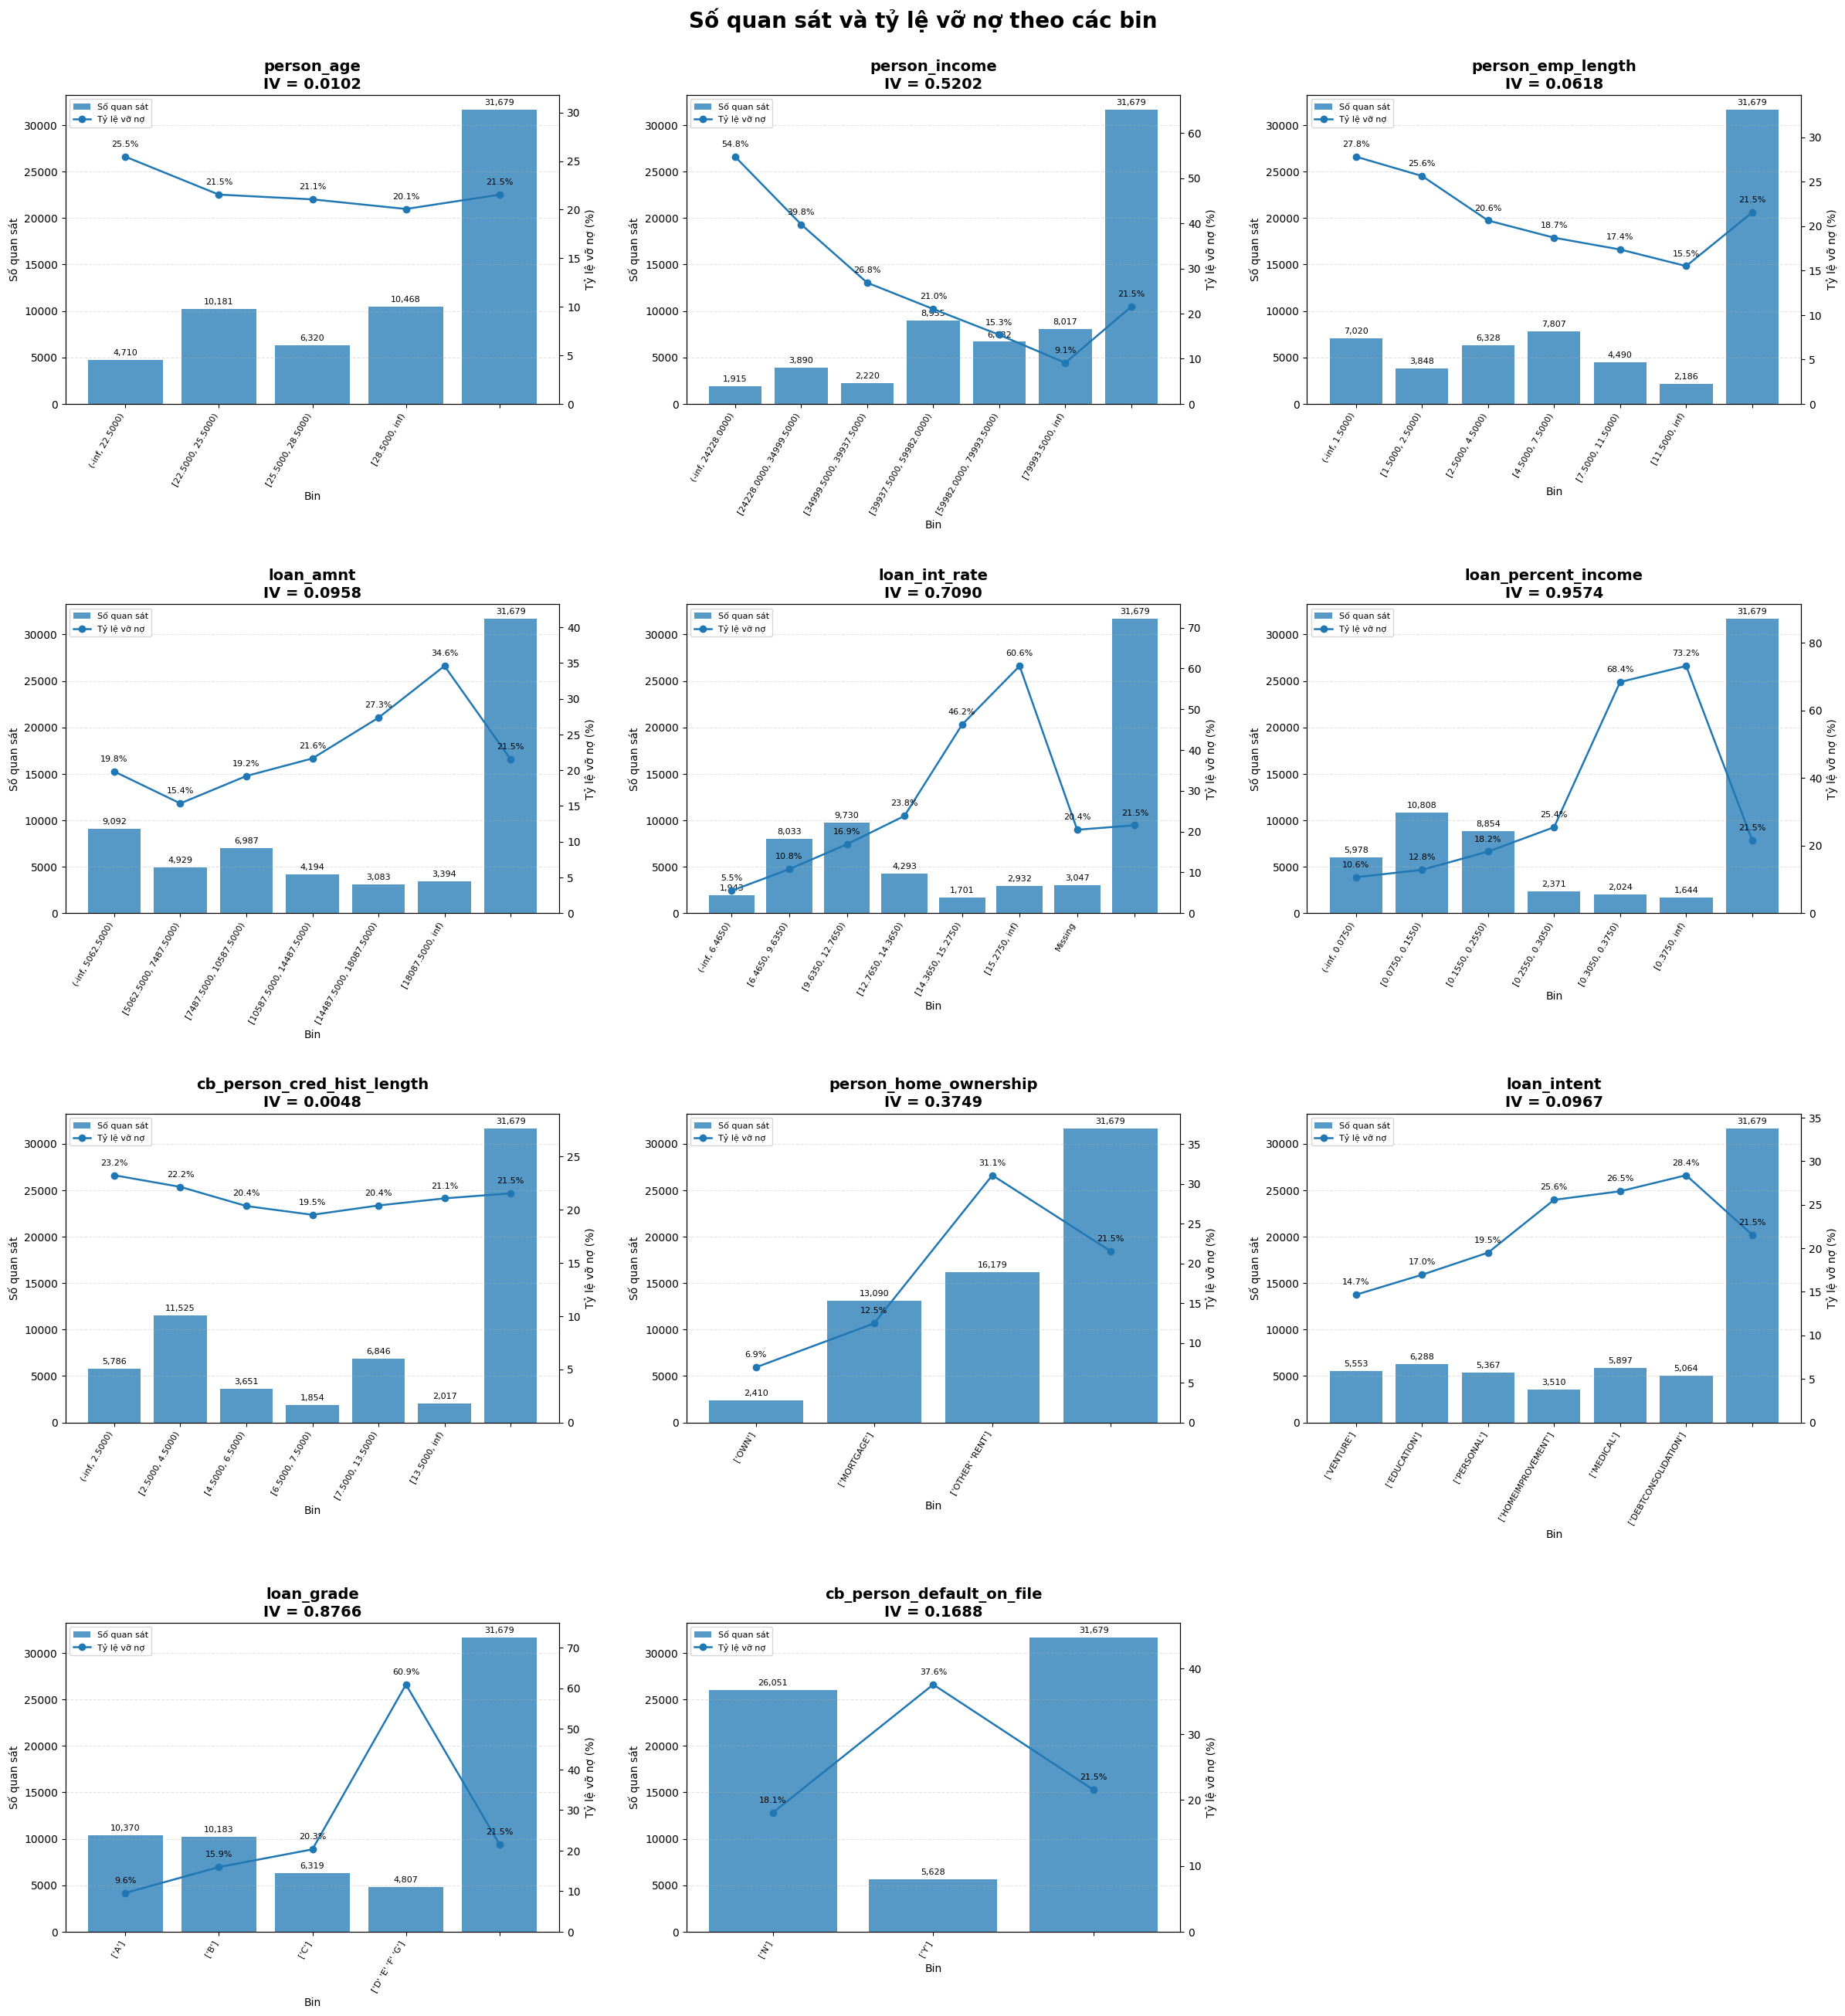

In [111]:
fig = plot_all_binning_charts(
    binning_tables=binning_tables,
    iv_df=IV_df,
    ncols=3,
    include_missing=True,
    include_special=False,
    save_path="all_binning_charts.pdf"
)

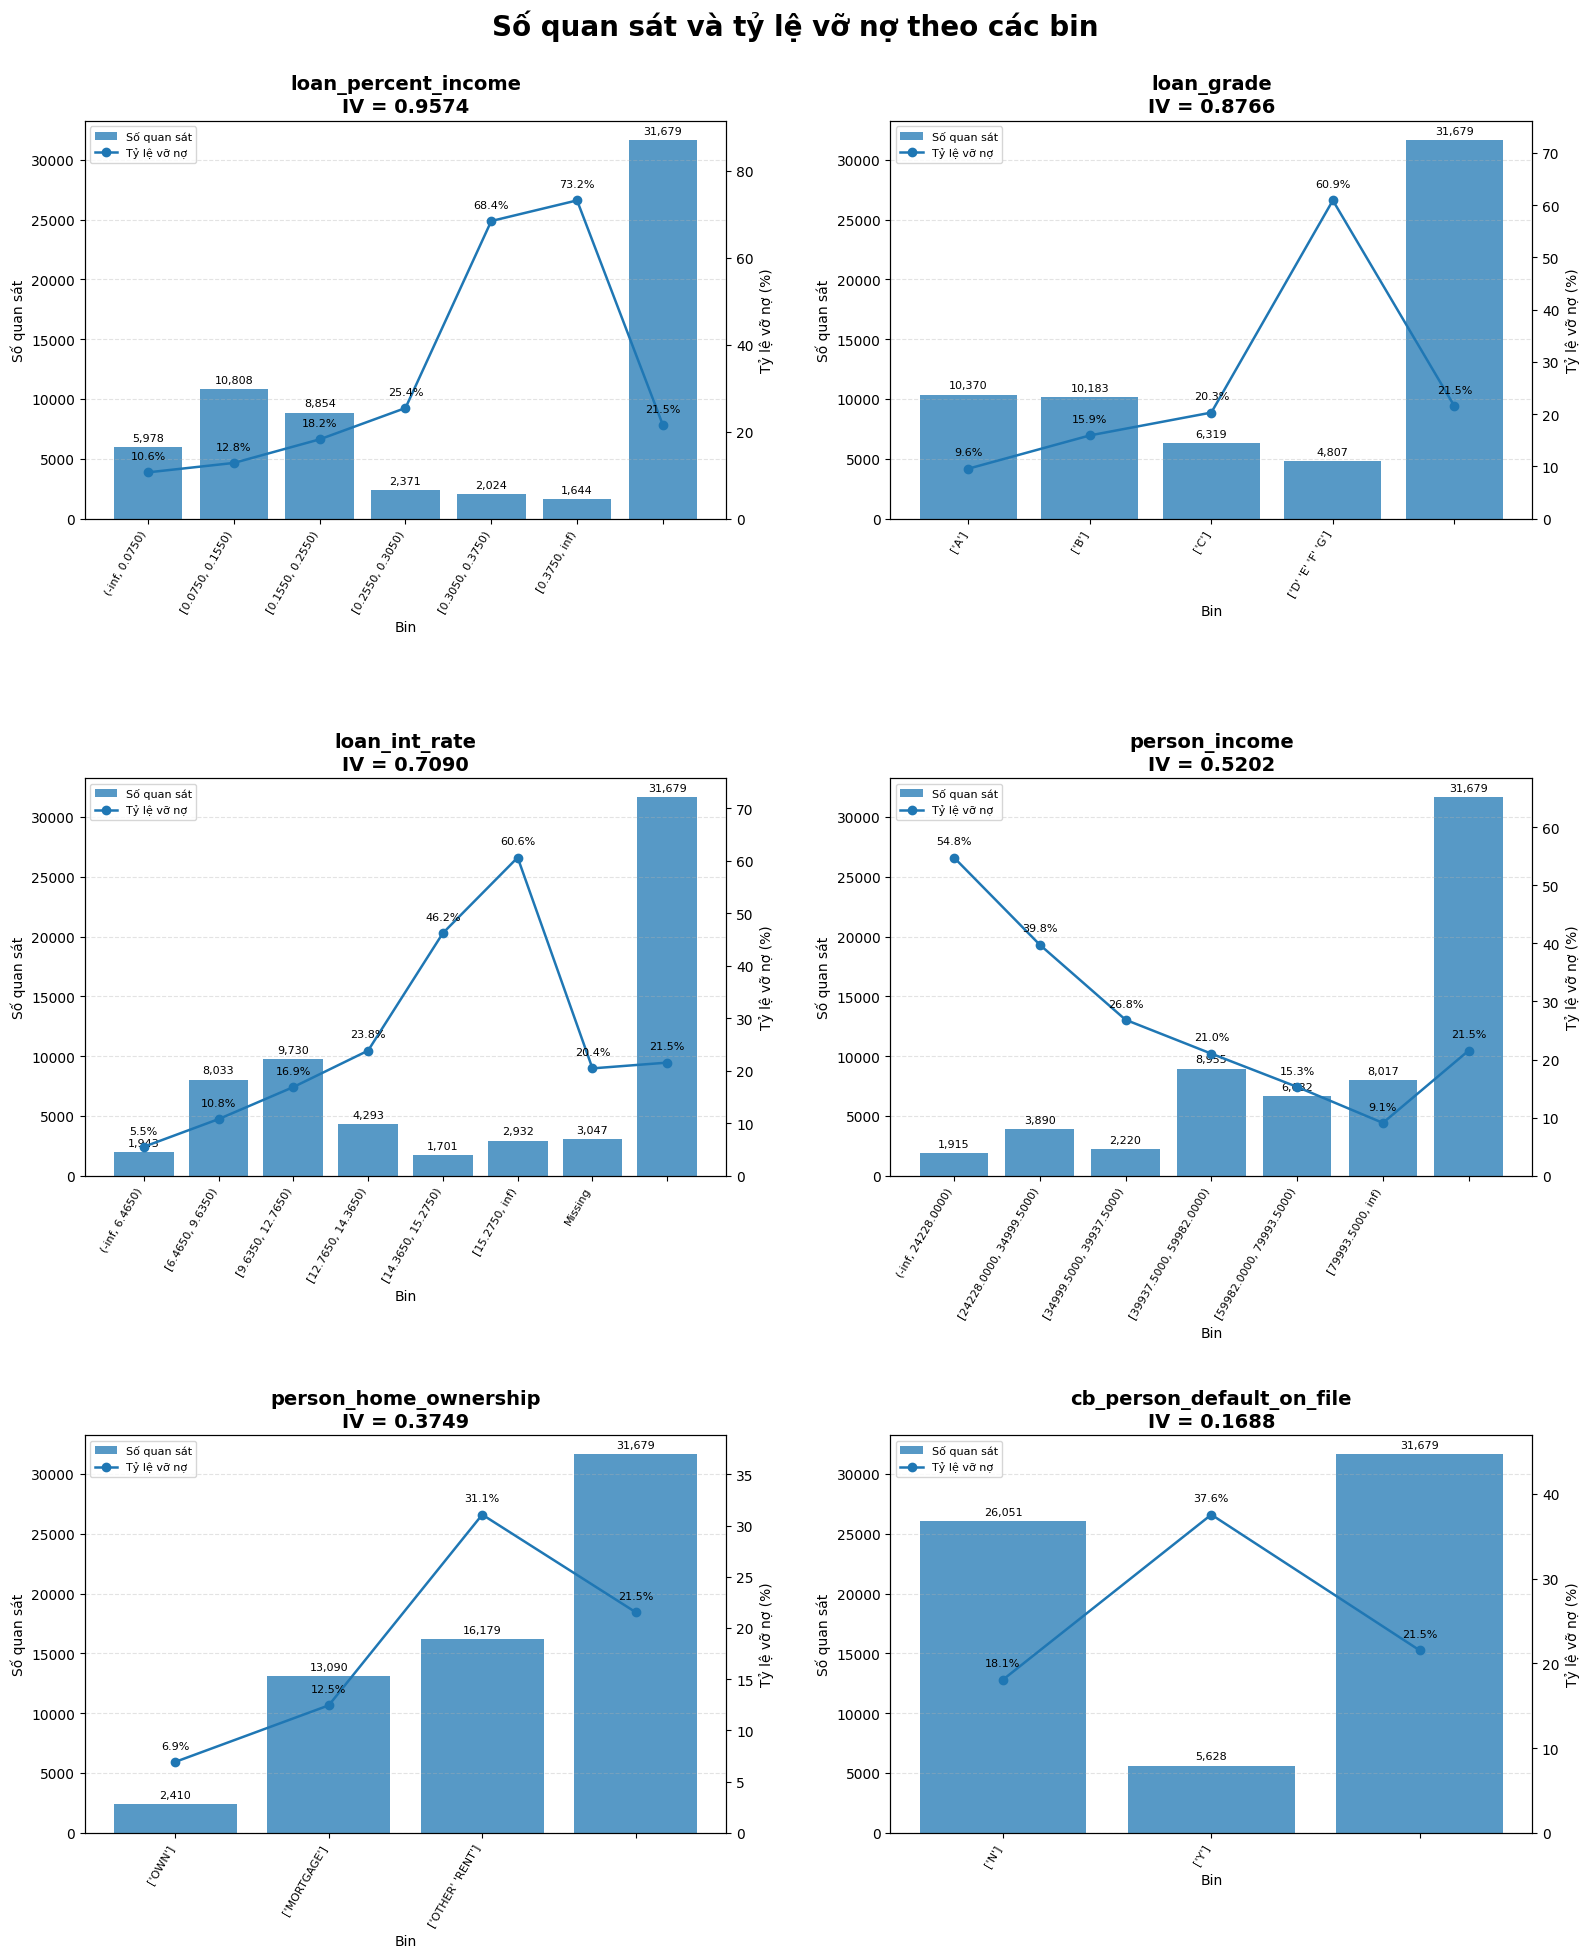

In [112]:
strong_features = [
    "loan_percent_income",
    "loan_grade",
    "loan_int_rate",
    "person_income",
    "person_home_ownership",
    "cb_person_default_on_file"
]

strong_binning_tables = {
    feature: binning_tables[feature]
    for feature in strong_features
}

fig = plot_all_binning_charts(
    binning_tables=strong_binning_tables,
    iv_df=IV_df,
    ncols=2,
    include_missing=True,
    save_path="strong_variables_binning.pdf"
)

## Diễn giải biểu đồ Optimal Binning

### Cách đọc biểu đồ

Mỗi biểu đồ trình bày đồng thời hai thông tin của từng bin:

- **Cột** biểu diễn số lượng quan sát thuộc bin;
- **Đường** biểu diễn tỷ lệ vỡ nợ trong bin;
- **Tiêu đề** trình bày tên biến và Information Value của biến đó;
- **Trục hoành** thể hiện các khoảng giá trị hoặc các nhóm phân loại sau
  optimal binning.

Tỷ lệ vỡ nợ trong bin thứ $j$ được xác định bởi:

$$
\operatorname{DefaultRate}_j
=
\frac{\operatorname{Event}_j}
{\operatorname{Count}_j}.
$$

Khi diễn giải biểu đồ, cần xem xét đồng thời:

1. Tỷ lệ vỡ nợ có khác biệt rõ ràng giữa các bin hay không;
2. Tỷ lệ vỡ nợ có thay đổi theo xu hướng hợp lý hay không;
3. Mỗi bin có đủ số lượng quan sát hay không;
4. Có bin nào có tỷ lệ vỡ nợ cực đoan do quá ít quan sát hay không;
5. Giá trị thiếu có tạo thành một nhóm rủi ro riêng hay không;
6. Các nhóm phân loại được gộp có hợp lý về mặt nghiệp vụ hay không.

Một biến có biểu đồ thể hiện tỷ lệ vỡ nợ khác biệt rõ ràng giữa các bin thường
có IV cao. Ngược lại, nếu đường tỷ lệ vỡ nợ gần như nằm ngang, biến thường có
khả năng phân biệt thấp.

---

### `loan_percent_income`

Biến `loan_percent_income` có IV cao nhất, bằng 0,9574. Tỷ lệ vỡ nợ tăng rõ
rệt theo tỷ lệ số tiền vay trên thu nhập:

$$
10,6\%
\rightarrow
12,8\%
\rightarrow
18,2\%
\rightarrow
25,4\%
\rightarrow
68,4\%
\rightarrow
73,2\%.
$$

Xu hướng tăng gần như đơn điệu cho thấy gánh nặng khoản vay so với thu nhập có
mối liên hệ rất mạnh với khả năng vỡ nợ.

Đặc biệt, tỷ lệ vỡ nợ tăng đột ngột khi:

$$
loan\_percent\_income \geq 0,305.
$$

Nhóm có tỷ lệ khoản vay trên thu nhập từ 30,5% trở lên có mức rủi ro lớn hơn
rõ rệt so với các nhóm còn lại. Đây là nguyên nhân chính làm cho IV của biến
đạt giá trị rất cao.

Mặc dù hai bin rủi ro cao nhất có số quan sát nhỏ hơn các bin còn lại, mỗi bin
vẫn chứa hơn 1.600 quan sát nên kết quả không chỉ xuất phát từ một nhóm quá
nhỏ. Tuy nhiên, ngưỡng 30,5% vẫn cần được kiểm tra về tính ổn định khi áp dụng
cho dữ liệu mới.

---

### `loan_grade`

Optimal binning đã gộp bảy hạng khoản vay ban đầu thành bốn bin:

$$
\{A\},\qquad
\{B\},\qquad
\{C\},\qquad
\{D,E,F,G\}.
$$

Tỷ lệ vỡ nợ tăng từ:

$$
9,6\%
\rightarrow
15,9\%
\rightarrow
20,3\%
\rightarrow
60,9\%.
$$

Kết quả cho thấy hạng khoản vay càng xấu thì rủi ro vỡ nợ càng cao. Việc gộp
D, E, F và G cho thấy bốn hạng này có thể được xem là một nhóm rủi ro cao so
với A, B và C.

Phương án gộp này cũng giúp hạn chế sự bất ổn do các hạng F và G riêng lẻ có
số lượng quan sát nhỏ. IV bằng 0,8766 cho thấy biến có khả năng phân biệt rất
mạnh.

Tuy nhiên, `loan_grade` có thể là kết quả của một quy trình thẩm định tín dụng
đã tồn tại trước đó. Do đó, cần xác định biến này có sẵn tại thời điểm mô hình
được sử dụng hay không.

---

### `loan_int_rate`

Tỷ lệ vỡ nợ tăng mạnh khi lãi suất tăng:

$$
5,5\%
\rightarrow
10,8\%
\rightarrow
16,9\%
\rightarrow
23,8\%
\rightarrow
46,2\%
\rightarrow
60,6\%.
$$

Biểu đồ thể hiện một xu hướng tăng rõ ràng và gần như đơn điệu. Đặc biệt, tỷ lệ
vỡ nợ tăng mạnh ở các nhóm có lãi suất cao, cho thấy lãi suất phản ánh đáng kể
mức độ rủi ro của khoản vay.

Nhóm `Missing` có tỷ lệ vỡ nợ khoảng 20,4%, gần với tỷ lệ vỡ nợ chung của dữ
liệu. Vì vậy, trạng thái thiếu lãi suất không tạo ra một nhóm rủi ro đặc biệt
mạnh nhưng vẫn có thể được giữ thành bin riêng khi chuyển đổi WOE.

IV của biến bằng 0,7090, thể hiện khả năng phân biệt rất mạnh. Tuy nhiên, lãi
suất thường được xác định dựa trên hạng và mức độ rủi ro của khoản vay, nên có
thể chứa nhiều thông tin trùng lặp với `loan_grade`.

---

### `person_income`

Tỷ lệ vỡ nợ giảm rõ rệt khi thu nhập tăng:

$$
54,8\%
\rightarrow
39,8\%
\rightarrow
26,8\%
\rightarrow
21,0\%
\rightarrow
15,3\%
\rightarrow
9,1\%.
$$

Đây là một xu hướng giảm đơn điệu và phù hợp với ý nghĩa nghiệp vụ: khách hàng
có thu nhập cao hơn thường có khả năng đáp ứng nghĩa vụ thanh toán tốt hơn.

Các bin thu nhập thấp có số quan sát ít hơn, nhưng mức chênh lệch tỷ lệ vỡ nợ
so với các nhóm thu nhập cao rất lớn. Vì vậy, biến đạt IV bằng 0,5202 và có khả
năng phân biệt rất mạnh.

Tuy nhiên, `person_income` là một thành phần của `loan_percent_income`:

$$
loan\_percent\_income
\approx
\frac{loan\_amnt}{person\_income}.
$$

Do đó, cần kiểm tra thông tin trùng lặp giữa hai biến trước khi đưa đồng thời
vào mô hình.

---

### `person_home_ownership`

Optimal binning đã tạo ba nhóm:

$$
\{OWN\},\qquad
\{MORTGAGE\},\qquad
\{OTHER,RENT\}.
$$

Tỷ lệ vỡ nợ tương ứng là:

$$
6,9\%,\qquad
12,5\%,\qquad
31,1\%.
$$

Khách hàng sở hữu nhà có tỷ lệ vỡ nợ thấp nhất, tiếp theo là nhóm đang trả thế
chấp. Nhóm thuê nhà và nhóm `OTHER` có mức rủi ro cao hơn đáng kể.

Việc gộp `OTHER` với `RENT` là hợp lý về mặt thống kê vì hai nhóm có tỷ lệ vỡ
nợ tương đối gần nhau. Đồng thời, việc gộp giúp hạn chế sự bất ổn của nhóm
`OTHER`, vốn có ít quan sát.

IV bằng 0,3749 cho thấy biến có khả năng phân biệt mạnh.

---

### `cb_person_default_on_file`

Biến được chia thành hai nhóm:

$$
\{N\}
\quad\text{và}\quad
\{Y\}.
$$

Nhóm chưa từng có lịch sử vỡ nợ có tỷ lệ vỡ nợ hiện tại khoảng 18,1%, trong
khi nhóm từng có lịch sử vỡ nợ có tỷ lệ khoảng 37,6%.

Sự chênh lệch gần 20 điểm phần trăm cho thấy lịch sử tín dụng trong quá khứ
cung cấp thông tin quan trọng về hành vi trả nợ trong tương lai.

IV bằng 0,1688, tương ứng khả năng phân biệt trung bình.

---

### `loan_intent`

Tỷ lệ vỡ nợ khác nhau giữa các mục đích vay, dao động từ khoảng 14,7% đến
28,4%.

Các khoản vay cho mục đích đầu tư kinh doanh có tỷ lệ vỡ nợ thấp nhất, trong
khi vay hợp nhất nợ và một số mục đích liên quan đến chi phí y tế hoặc cải
thiện nhà ở có tỷ lệ cao hơn.

Tuy nhiên, mức chênh lệch giữa các nhóm nhỏ hơn nhiều so với các biến như
`loan_grade`, `loan_int_rate` hoặc `loan_percent_income`. Vì vậy, IV chỉ đạt
0,0967, tương ứng khả năng phân biệt yếu nhưng nằm gần ngưỡng trung bình.

---

### `loan_amnt`

Tỷ lệ vỡ nợ theo số tiền vay không thay đổi hoàn toàn đơn điệu:

$$
19,8\%
\rightarrow
15,4\%
\rightarrow
19,2\%
\rightarrow
21,6\%
\rightarrow
27,3\%
\rightarrow
34,6\%.
$$

Nhóm khoản vay nhỏ nhất không có tỷ lệ vỡ nợ thấp nhất. Sau khi giảm ở bin thứ
hai, tỷ lệ vỡ nợ tăng dần theo số tiền vay.

Kết quả này cho thấy số tiền vay có mối quan hệ phi tuyến với rủi ro. Một khoản
vay nhỏ vẫn có thể rủi ro nếu được cấp cho khách hàng có thu nhập rất thấp,
trong khi một khoản vay lớn có thể phù hợp với khách hàng có khả năng tài chính
cao.

IV bằng 0,0958, cho thấy khả năng phân biệt đơn biến yếu. Khi phân tích rủi ro,
`loan_amnt` nên được xem xét cùng với `person_income` và
`loan_percent_income`.

---

### `person_emp_length`

Tỷ lệ vỡ nợ nhìn chung giảm khi thời gian làm việc tăng:

$$
27,8\%
\rightarrow
25,6\%
\rightarrow
20,6\%
\rightarrow
18,7\%
\rightarrow
17,4\%
\rightarrow
15,5\%.
$$

Xu hướng này phù hợp với giả định rằng khách hàng có thời gian làm việc dài hơn
thường có việc làm và nguồn thu nhập ổn định hơn.

Tuy nhiên, mức độ khác biệt giữa phần lớn các bin không quá lớn, nên IV chỉ đạt
0,0618. Biến có khả năng phân biệt yếu nhưng xu hướng rủi ro rõ ràng và dễ giải
thích về mặt nghiệp vụ.

---

### `person_age`

Tỷ lệ vỡ nợ giữa các nhóm tuổi lần lượt khoảng:

$$
25,5\%,\qquad
21,5\%,\qquad
21,1\%,\qquad
20,1\%.
$$

Nhóm khách hàng trẻ nhất có tỷ lệ vỡ nợ cao hơn, nhưng ba nhóm còn lại có tỷ lệ
rất gần nhau. Đường tỷ lệ vỡ nợ tương đối phẳng, cho thấy các bin tuổi không
tạo được sự phân biệt rõ ràng giữa Good và Bad.

Optimal binning chỉ giữ lại bốn bin mặc dù số bin tối đa được đặt bằng sáu.
Điều này cho thấy việc tạo thêm bin không cải thiện đáng kể hàm mục tiêu.

IV chỉ bằng 0,0102, vì vậy tuổi gần như không có khả năng phân biệt đơn biến
trong tập dữ liệu này.

---

### `cb_person_cred_hist_length`

Tỷ lệ vỡ nợ giữa các bin lịch sử tín dụng chỉ dao động trong khoảng hẹp:

$$
19,5\%\text{ đến }23,2\%.
$$

Đường tỷ lệ vỡ nợ gần như nằm ngang và không có xu hướng tăng hoặc giảm rõ
ràng. Phân phối Good và Bad vì vậy tương đối giống nhau giữa các bin.

IV bằng 0,0048, thấp nhất trong tất cả các biến. Kết quả cho thấy độ dài lịch
sử tín dụng gần như không có khả năng phân biệt đơn biến trong dữ liệu hiện
tại.

---

## Đánh giá chung từ các biểu đồ

Các biểu đồ cho thấy ba dạng quan hệ chính:

### Quan hệ đơn điệu rõ ràng

Các biến sau có tỷ lệ vỡ nợ thay đổi nhất quán theo giá trị của biến:

- `loan_percent_income`: tăng mạnh;
- `loan_int_rate`: tăng mạnh;
- `person_income`: giảm mạnh;
- `person_emp_length`: giảm tương đối;
- `loan_grade`: tăng theo mức độ rủi ro.

Những biến này phù hợp với phép chuyển đổi WOE và dễ giải thích trong scorecard.

### Quan hệ phi tuyến

`loan_amnt` có quan hệ không hoàn toàn đơn điệu. Rủi ro giảm ở nhóm khoản vay
thứ hai rồi tăng dần ở các nhóm khoản vay lớn hơn.

Việc optimal binning giữ quan hệ phi tuyến này là phù hợp hơn so với ép một xu
hướng tăng hoặc giảm hoàn toàn.

### Quan hệ yếu hoặc gần như phẳng

Các biến:

- `person_age`;
- `cb_person_cred_hist_length`;

có tỷ lệ vỡ nợ gần giống nhau giữa các bin. Vì vậy, chúng có IV rất thấp và là
các ứng viên để xem xét loại khỏi mô hình.

---

## Kết luận

Biểu đồ optimal binning xác nhận rằng khả năng phân biệt mạnh nhất tập trung ở
các biến liên quan đến:

- gánh nặng khoản vay trên thu nhập;
- hạng khoản vay;
- lãi suất;
- thu nhập;
- hình thức sở hữu nhà;
- lịch sử vỡ nợ.

Tuy nhiên, các biến có IV cao không nên được lựa chọn tự động. Việc lựa chọn
cuối cùng còn cần xem xét:

- tính ổn định của các bin;
- kích thước mỗi bin;
- xu hướng WOE;
- thông tin trùng lặp;
- tính sẵn có tại thời điểm chấm điểm;
- dấu và độ ổn định của hệ số hồi quy logistic.

In [127]:
#binning_tables

In [116]:
X_woe

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,-0.218013,-1.484134,0.177119,0.105180,0.301308,0.625855,-0.097941,1.305149,0.296541,0.371131,0.218257
1,-0.000338,-1.484134,-0.339044,0.414361,-0.130376,-2.295955,-0.035587,0.657856,-0.274283,0.074985,0.218257
2,-0.000338,0.419236,0.054433,-0.655336,-1.140459,-2.295955,-0.097941,-0.495919,-0.274283,0.074985,0.218257
3,-0.000338,0.031523,0.267067,-0.655336,-0.130376,-2.295955,-0.035587,-0.495919,-0.274283,0.074985,-0.784253
4,-0.218013,-1.484134,-0.228170,0.105180,0.820931,0.208479,-0.097941,1.305149,0.469195,0.955088,0.218257
...,...,...,...,...,...,...,...,...,...,...,...
31674,0.089456,0.031523,-0.339044,0.414361,-0.130376,0.625855,0.028231,0.657856,0.126087,0.074985,0.218257
31675,0.089456,1.009884,0.054433,-0.315162,0.820931,0.625855,0.028231,0.657856,0.126087,0.955088,0.218257
31676,0.089456,0.419236,0.054433,-0.655336,0.301308,-2.295955,0.028231,-0.495919,-0.223228,0.371131,0.218257
31677,0.089456,1.009884,0.177119,-0.315162,0.301308,0.625855,0.028231,0.657856,0.126087,0.371131,0.218257


# Lựa chọn biến bằng Logistic LASSO và Cross-Validation

## 1. Mục tiêu

Sau khi thực hiện optimal binning và chuyển đổi Weight of Evidence, tập dữ
liệu `woe_dataset` được sử dụng cho bước lựa chọn biến đa biến.

Quy trình được thực hiện như sau:

$$
\boxed{
\text{Sàng lọc bằng IV}
\rightarrow
\text{Logistic LASSO}
\rightarrow
\text{Cross-validation}
\rightarrow
\lambda_{\mathrm{best}},\lambda_{1SE}
\rightarrow
\text{Lựa chọn biến}
\rightarrow
\text{Fit lại GLM}
}
$$

Mục tiêu của bước này là lựa chọn một tập biến:

- có khả năng phân biệt khách hàng Good và Bad;
- có đóng góp trong mô hình đa biến;
- hạn chế thông tin trùng lặp;
- có cấu trúc gọn và dễ giải thích;
- phù hợp để xây dựng bảng điểm tín dụng.

---

## 2. Sàng lọc sơ bộ bằng Information Value

Các biến có:

$$
IV<0,02
$$

được xem là gần như không có khả năng phân biệt đơn biến và được loại trước
khi áp dụng LASSO.

Hai biến bị loại là:

- `person_age`;
- `cb_person_cred_hist_length`.

Chín biến WOE còn lại được đưa vào LASSO:

- `loan_percent_income`;
- `loan_grade`;
- `loan_int_rate`;
- `person_income`;
- `person_home_ownership`;
- `cb_person_default_on_file`;
- `loan_intent`;
- `loan_amnt`;
- `person_emp_length`.

---

## 3. Logistic LASSO

Mô hình hồi quy logistic thông thường có dạng:

$$
\log
\left(
\frac{p_i}{1-p_i}
\right)
=
\beta_0+
\sum_{j=1}^{p}\beta_jx_{ij},
$$

trong đó:

$$
p_i=P(Y_i=1\mid X_i)
$$

là xác suất khách hàng thứ $i$ vỡ nợ.

LASSO bổ sung hình phạt $L_1$ vào hàm mất mát:

$$
\widehat{\boldsymbol{\beta}}
=
\arg\min_{\boldsymbol{\beta}}
\left\{
-\ell(\boldsymbol{\beta})
+
\lambda\sum_{j=1}^{p}|\beta_j|
\right\}.
$$

Khi $\lambda$ tăng, mức phạt tăng và các hệ số bị co về 0. Biến thứ $j$ được
xem là bị loại khi:

$$
\widehat{\beta}_j=0.
$$

LASSO phù hợp với dữ liệu hiện tại vì một số biến có thể chứa thông tin trùng
lặp, chẳng hạn:

$$
loan\_grade
\longleftrightarrow
loan\_int\_rate,
$$

và:

$$
loan\_percent\_income
\approx
\frac{loan\_amnt}{person\_income}.
$$

---

## 4. Chuẩn hóa biến

Trước khi áp dụng LASSO, các biến WOE được chuẩn hóa:

$$
z_{ij}
=
\frac{x_{ij}-\bar{x}_j}{s_j}.
$$

Việc chuẩn hóa giúp hình phạt $L_1$ được áp dụng trên các biến có thang đo
tương đương.

Quá trình chuẩn hóa phải được thực hiện riêng trong từng training fold để tránh
việc thông tin của validation fold tham gia vào bước tiền xử lý.

---

## 5. Stratified K-fold Cross-Validation

Dữ liệu được chia thành $K=10$ fold:

$$
D_1,D_2,\ldots,D_{10}.
$$

Tại lần lặp thứ $k$:

1. Fold $D_k$ được sử dụng làm validation fold;
2. Chín fold còn lại được sử dụng để huấn luyện;
3. Mô hình được đánh giá trên validation fold;
4. Quá trình được lặp lại để mỗi fold được dùng làm validation một lần.

Stratified cross-validation được sử dụng để tỷ lệ khách hàng vỡ nợ và không
vỡ nợ trong mỗi fold gần với tỷ lệ của toàn bộ dữ liệu.

---

## 6. Đánh giá bằng AUC

Với mỗi giá trị $\lambda$, AUC được tính trên từng validation fold.

AUC trung bình là:

$$
\overline{AUC}(\lambda)
=
\frac{1}{K}
\sum_{k=1}^{K}
AUC_k(\lambda).
$$

Độ lệch chuẩn của AUC là:

$$
SD(\lambda)
=
\sqrt{
\frac{
\sum_{k=1}^{K}
\left[
AUC_k(\lambda)-\overline{AUC}(\lambda)
\right]^2
}{K-1}
}.
$$

Sai số chuẩn là:

$$
SE(\lambda)
=
\frac{SD(\lambda)}{\sqrt{K}}.
$$

Trong `scikit-learn`, tham số được sử dụng là:

$$
C=\frac{1}{\lambda}.
$$

Do đó:

- $C$ lớn tương ứng với mức phạt yếu;
- $C$ nhỏ tương ứng với mức phạt mạnh.

---

## 7. Giá trị lambda tốt nhất

Giá trị lambda tốt nhất, tương ứng với `lambda_min` trong cách gọi truyền
thống, là giá trị tạo ra AUC trung bình lớn nhất:

$$
\lambda_{\mathrm{best}}
=
\arg\max_{\lambda}
\overline{AUC}(\lambda).
$$

Mô hình tại $\lambda_{\mathrm{best}}$ thường có hiệu quả cross-validation cao
nhất nhưng có thể giữ lại nhiều biến.

---

## 8. Quy tắc một sai số chuẩn

Ngưỡng AUC theo quy tắc một sai số chuẩn được xác định bởi:

$$
AUC_{\mathrm{threshold}}
=
\overline{AUC}(\lambda_{\mathrm{best}})
-
SE(\lambda_{\mathrm{best}}).
$$

Sau đó lựa chọn giá trị lambda lớn nhất thỏa mãn:

$$
\overline{AUC}(\lambda)
\geq
AUC_{\mathrm{threshold}}.
$$

Giá trị này được gọi là:

$$
\lambda_{1SE}.
$$

Do $\lambda_{1SE}$ lớn hơn hoặc bằng $\lambda_{\mathrm{best}}$, mô hình tại
$\lambda_{1SE}$ chịu mức phạt mạnh hơn và thường giữ lại ít biến hơn.

Mô hình tại $\lambda_{1SE}$ được ưu tiên khi AUC chỉ giảm nhẹ nhưng số biến
giảm đáng kể.

---

## 9. Biểu đồ Cross-Validation

Biểu đồ thứ nhất trình bày:

- trục hoành: $\log(\lambda)$;
- trục tung: AUC cross-validation trung bình;
- vùng sai số: AUC trung bình cộng hoặc trừ một sai số chuẩn;
- đường đứt nét: $\lambda_{\mathrm{best}}$;
- đường liền: $\lambda_{1SE}$.

Khi đi từ trái sang phải, $\lambda$ tăng và mức phạt mạnh dần. Nếu phạt quá
mạnh, nhiều biến bị loại và AUC bắt đầu giảm rõ rệt.

---

## 10. Biểu đồ đường hệ số

Mỗi đường trong biểu đồ hệ số biểu diễn:

$$
\widehat{\beta}_j(\lambda).
$$

Khi $\lambda$ tăng, các hệ số bị co dần về 0.

Tại đường biểu diễn $\lambda_{1SE}$:

- biến có hệ số khác 0 được giữ lại;
- biến có hệ số bằng 0 bị loại.

Biểu đồ này cho biết biến nào bị loại sớm và biến nào tiếp tục đóng góp khi mức
phạt tăng.

---

## 11. Fit lại GLM không phạt

Các hệ số LASSO bị co lại có chủ đích nên không được sử dụng trực tiếp làm hệ
số của scorecard cuối cùng.

Sau khi xác định tập biến $S$ tại $\lambda_{1SE}$, mô hình logistic không phạt
được fit lại:

$$
\log
\left(
\frac{p_i}{1-p_i}
\right)
=
\beta_0+
\sum_{j\in S}\beta_jWOE_{ij}.
$$

Mô hình GLM được sử dụng để:

- ước lượng lại hệ số;
- tính sai số chuẩn;
- tính p-value;
- xây dựng khoảng tin cậy;
- kiểm tra dấu hệ số;
- xây dựng bảng điểm tín dụng.

Với quy ước:

$$
WOE
=
\ln
\left(
\frac{\operatorname{DistGood}}
{\operatorname{DistBad}}
\right),
$$

và `loan_status = 1` biểu thị vỡ nợ, hệ số của các biến WOE thường được kỳ
vọng mang dấu âm.

---

## 12. Lưu ý về Cross-Validation

Trong quy trình hiện tại, các điểm cắt và giá trị WOE đã được xác định trên
toàn bộ dữ liệu huấn luyện trước khi chạy LASSO cross-validation.

Do đó, cross-validation trong bước này đánh giá:

$$
\text{chuẩn hóa}
\rightarrow
\text{LASSO}
\rightarrow
\text{lựa chọn biến},
$$

sau khi các giá trị WOE đã được cố định.

Cross-validation này phù hợp cho lựa chọn lambda và lựa chọn biến trong phạm
vi tập huấn luyện. Nó chưa phải phép đánh giá hoàn toàn độc lập của toàn bộ
pipeline từ optimal binning đến mô hình cuối cùng.

In [139]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

In [140]:
target = "loan_status"

low_iv_features = [
    "person_age",
    "cb_person_cred_hist_length"
]

candidate_features = [
    column
    for column in woe_dataset.columns
    if column not in low_iv_features + [target]
]

print("Biến bị loại theo IV:")
for feature in low_iv_features:
    print(f"- {feature}")

print("\nBiến được đưa vào LASSO:")
for feature in candidate_features:
    print(f"- {feature}")

Biến bị loại theo IV:
- person_age
- cb_person_cred_hist_length

Biến được đưa vào LASSO:
- person_income
- person_emp_length
- loan_amnt
- loan_int_rate
- loan_percent_income
- person_home_ownership
- loan_intent
- loan_grade
- cb_person_default_on_file


In [141]:
X = (
    woe_dataset[candidate_features]
    .astype(float)
    .copy()
)

y = (
    woe_dataset[target]
    .astype(int)
    .copy()
)

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nPhân phối biến mục tiêu:")
display(
    y.value_counts()
    .rename_axis(target)
    .to_frame("Count")
)

print("\nSố giá trị thiếu:")
display(
    X.isna().sum()
    .to_frame("Missing")
)

print(
    "\nCó giá trị vô hạn:",
    np.isinf(X.to_numpy()).any()
)

Kích thước X: (31679, 9)
Kích thước y: (31679,)

Phân phối biến mục tiêu:


,Count
loan_status,
0,24854
1,6825



Số giá trị thiếu:


,Missing
person_income,0
person_emp_length,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
person_home_ownership,0
loan_intent,0
loan_grade,0
cb_person_default_on_file,0



Có giá trị vô hạn: False


In [142]:
random_state = 42
n_splits = 10

cv_object = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=random_state
)

# Cố định các fold để mọi giá trị lambda
# được đánh giá trên cùng những phần dữ liệu.
cv_splits = list(
    cv_object.split(X, y)
)

# scikit-learn sử dụng C = 1 / lambda.
C_grid = np.logspace(
    -4,
    4,
    60
)

lambda_grid = 1 / C_grid

In [143]:
def create_lasso_pipeline(
    C,
    random_state=42
):
    """
    Tạo pipeline:
        StandardScaler
        -> Logistic Regression với L1 penalty.
    """

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "lasso",
            LogisticRegression(
                penalty="l1",
                solver="saga",
                C=float(C),
                fit_intercept=True,
                max_iter=10000,
                tol=1e-4,
                random_state=random_state
            )
        )
    ])

In [144]:
cv_rows = []

for index, C_value in enumerate(
    C_grid,
    start=1
):
    pipeline = create_lasso_pipeline(
        C=C_value,
        random_state=random_state
    )

    auc_scores = cross_val_score(
        estimator=pipeline,
        X=X,
        y=y,
        cv=cv_splits,
        scoring="roc_auc",
        n_jobs=-1,
        error_score="raise"
    )

    mean_auc = auc_scores.mean()
    sd_auc = auc_scores.std(ddof=1)
    se_auc = sd_auc / np.sqrt(n_splits)

    cv_rows.append({
        "C": C_value,
        "Lambda": 1 / C_value,
        "Log Lambda": np.log(1 / C_value),
        "Mean CV AUC": mean_auc,
        "SD CV AUC": sd_auc,
        "SE CV AUC": se_auc,
        "Fold AUC": auc_scores
    })

    print(
        f"{index:02d}/{len(C_grid)} | "
        f"C={C_value:.6g} | "
        f"lambda={1 / C_value:.6g} | "
        f"AUC={mean_auc:.5f}"
    )

cv_results = pd.DataFrame(
    cv_rows
)

display(
    cv_results[
        [
            "C",
            "Lambda",
            "Mean CV AUC",
            "SD CV AUC",
            "SE CV AUC"
        ]
    ].head()
)

01/60 | C=0.0001 | lambda=10000 | AUC=0.50000
02/60 | C=0.000136645 | lambda=7318.24 | AUC=0.50000
03/60 | C=0.000186718 | lambda=5355.67 | AUC=0.50000
04/60 | C=0.000255141 | lambda=3919.41 | AUC=0.84436
05/60 | C=0.000348637 | lambda=2868.32 | AUC=0.84440
06/60 | C=0.000476394 | lambda=2099.1 | AUC=0.86566
07/60 | C=0.000650968 | lambda=1536.17 | AUC=0.87365
08/60 | C=0.000889513 | lambda=1124.21 | AUC=0.87848
09/60 | C=0.00121547 | lambda=822.724 | AUC=0.88136
10/60 | C=0.00166088 | lambda=602.089 | AUC=0.88269
11/60 | C=0.00226951 | lambda=440.624 | AUC=0.88336
12/60 | C=0.00310117 | lambda=322.459 | AUC=0.88369
13/60 | C=0.00423759 | lambda=235.983 | AUC=0.88393
14/60 | C=0.00579044 | lambda=172.698 | AUC=0.88405
15/60 | C=0.00791234 | lambda=126.385 | AUC=0.88421
16/60 | C=0.0108118 | lambda=92.4915 | AUC=0.88431
17/60 | C=0.0147738 | lambda=67.6875 | AUC=0.88438
18/60 | C=0.0201876 | lambda=49.5354 | AUC=0.88440
19/60 | C=0.0275853 | lambda=36.2512 | AUC=0.88442
20/60 | C=0.0376

,C,Lambda,Mean CV AUC,SD CV AUC,SE CV AUC
0,0.000100,10000.000000,0.500000,0.000000,0.000000
1,0.000137,7318.242219,0.500000,0.000000,0.000000
2,0.000187,5355.666918,0.500000,0.000000,0.000000
3,0.000255,3919.406775,0.844365,0.009085,0.002873
4,0.000349,2868.316813,0.844401,0.009156,0.002895


In [147]:
eligible_1se = cv_results.loc[
    cv_results["Mean CV AUC"]
    >= auc_threshold_1se
].copy()

one_se_index = (
    eligible_1se["Lambda"]
    .idxmax()
)

one_se_row = cv_results.loc[
    one_se_index
]

C_1se = float(
    one_se_row["C"]
)

lambda_1se = float(
    one_se_row["Lambda"]
)

auc_1se = float(
    one_se_row["Mean CV AUC"]
)

se_1se = float(
    one_se_row["SE CV AUC"]
)

print(f"C theo quy tắc 1 SE     : {C_1se:.8f}")
print(f"Lambda theo 1 SE        : {lambda_1se:.8f}")
print(f"Mean CV AUC tại 1 SE    : {auc_1se:.6f}")
print(f"SE CV AUC tại 1 SE      : {se_1se:.6f}")

C theo quy tắc 1 SE     : 0.00166088
Lambda theo 1 SE        : 602.08944933
Mean CV AUC tại 1 SE    : 0.882688
SE CV AUC tại 1 SE      : 0.002112


In [148]:
best_index = (
    cv_results["Mean CV AUC"]
    .idxmax()
)

best_row = cv_results.loc[
    best_index
]

C_best = float(
    best_row["C"]
)

lambda_best = float(
    best_row["Lambda"]
)

auc_best = float(
    best_row["Mean CV AUC"]
)

se_best = float(
    best_row["SE CV AUC"]
)

auc_threshold_1se = (
    auc_best - se_best
)

print(f"C tốt nhất              : {C_best:.8f}")
print(f"Lambda tốt nhất         : {lambda_best:.8f}")
print(f"Mean CV AUC tốt nhất    : {auc_best:.6f}")
print(f"SE tại lambda tốt nhất  : {se_best:.6f}")
print(f"Ngưỡng AUC theo 1 SE    : {auc_threshold_1se:.6f}")

C tốt nhất              : 0.03769391
Lambda tốt nhất         : 26.52948464
Mean CV AUC tốt nhất    : 0.884428
SE tại lambda tốt nhất  : 0.002082
Ngưỡng AUC theo 1 SE    : 0.882346


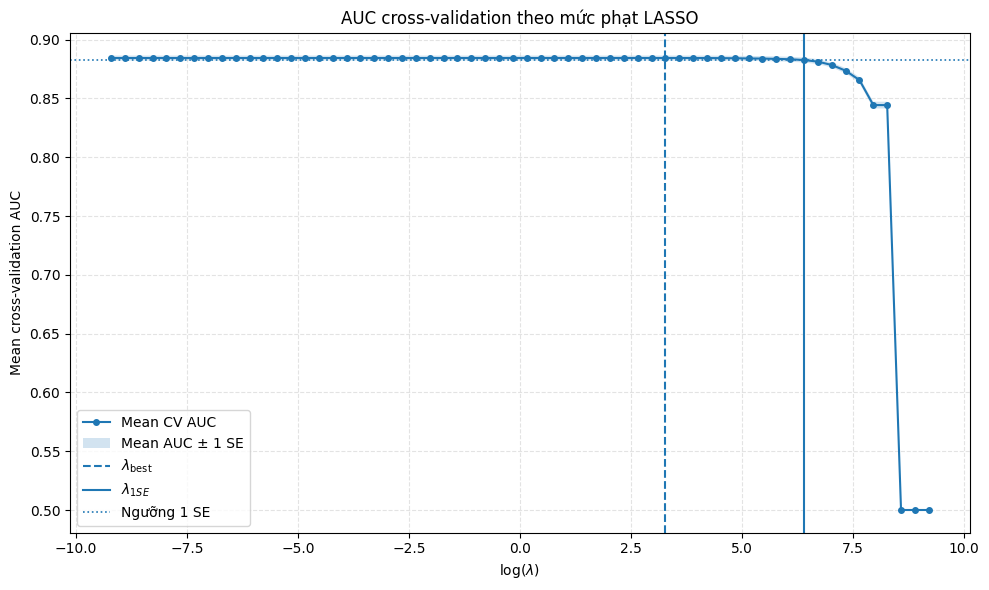

In [149]:
plot_cv = (
    cv_results
    .sort_values("Log Lambda")
    .reset_index(drop=True)
)

x_values = plot_cv["Log Lambda"].to_numpy()
mean_values = plot_cv["Mean CV AUC"].to_numpy()
se_values = plot_cv["SE CV AUC"].to_numpy()

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    x_values,
    mean_values,
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Mean CV AUC"
)

ax.fill_between(
    x_values,
    mean_values - se_values,
    mean_values + se_values,
    alpha=0.2,
    label="Mean AUC ± 1 SE"
)

ax.axvline(
    np.log(lambda_best),
    linestyle="--",
    linewidth=1.5,
    label=r"$\lambda_{\mathrm{best}}$"
)

ax.axvline(
    np.log(lambda_1se),
    linestyle="-",
    linewidth=1.5,
    label=r"$\lambda_{1SE}$"
)

ax.axhline(
    auc_threshold_1se,
    linestyle=":",
    linewidth=1.2,
    label="Ngưỡng 1 SE"
)

ax.set_title(
    "AUC cross-validation theo mức phạt LASSO"
)

ax.set_xlabel(
    r"$\log(\lambda)$"
)

ax.set_ylabel(
    "Mean cross-validation AUC"
)

ax.grid(
    linestyle="--",
    alpha=0.35
)

ax.legend()

plt.tight_layout()
plt.show()

In [151]:
scaler_path = StandardScaler()

X_scaled = scaler_path.fit_transform(
    X
)

coefficient_rows = []

for C_value in C_grid:
    path_model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(C_value),
        fit_intercept=True,
        max_iter=10000,
        tol=1e-4,
        random_state=random_state
    )

    path_model.fit(
        X_scaled,
        y
    )

    row = {
        "C": C_value,
        "Lambda": 1 / C_value,
        "Log Lambda": np.log(1 / C_value)
    }

    row.update({
        feature: coefficient
        for feature, coefficient in zip(
            candidate_features,
            path_model.coef_[0]
        )
    })

    coefficient_rows.append(
        row
    )

coefficient_path = pd.DataFrame(
    coefficient_rows
)

In [138]:
import statsmodels.api as sm

X_selected = (
    woe_dataset[selected_features_lasso]
    .astype(float)
)

X_selected = sm.add_constant(
    X_selected,
    has_constant="add"
)

final_logit_model = sm.Logit(
    y,
    X_selected
)

final_logit_result = (
    final_logit_model.fit()
)

print(
    final_logit_result.summary()
)

Optimization terminated successfully.
         Current function value: 0.316251
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                31679
Model:                          Logit   Df Residuals:                    31670
Method:                           MLE   Df Model:                            8
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                  0.3931
Time:                        08:43:02   Log-Likelihood:                -10019.
converged:                       True   LL-Null:                       -16507.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.3897      0.019    -72.506      0.000      -1.427      -1.

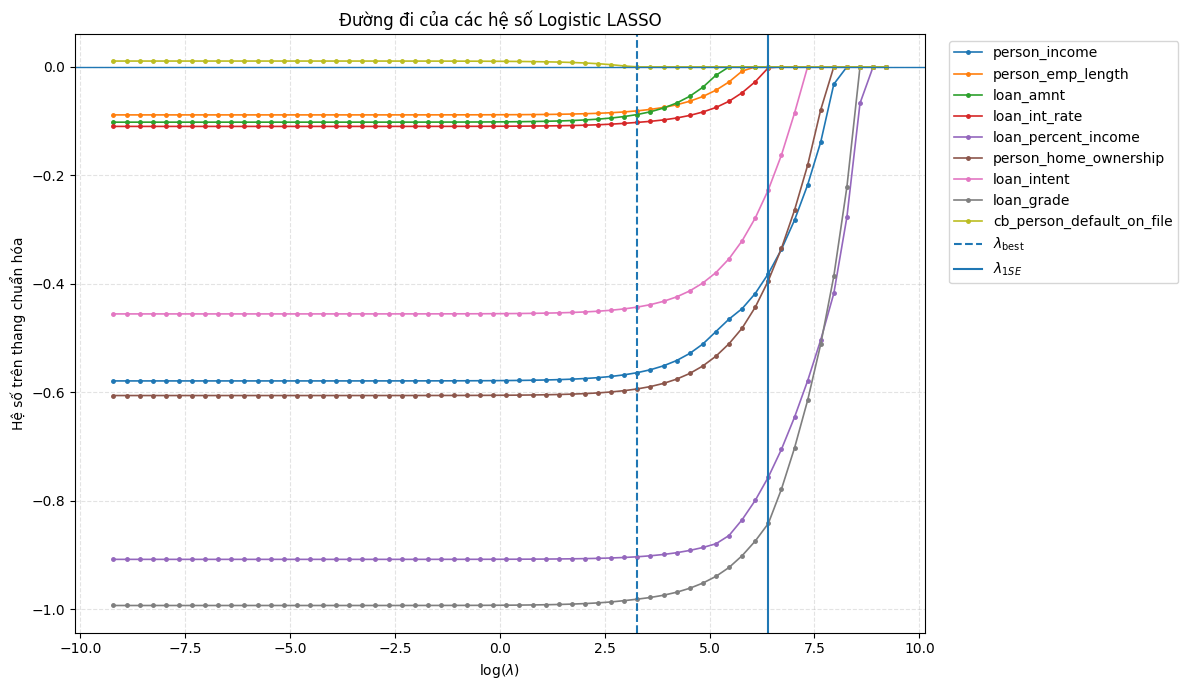

In [152]:
coefficient_plot = (
    coefficient_path
    .sort_values("Log Lambda")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

for feature in candidate_features:
    ax.plot(
        coefficient_plot["Log Lambda"],
        coefficient_plot[feature],
        marker="o",
        markersize=2.5,
        linewidth=1.2,
        label=feature
    )

ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    np.log(lambda_best),
    linestyle="--",
    linewidth=1.5,
    label=r"$\lambda_{\mathrm{best}}$"
)

ax.axvline(
    np.log(lambda_1se),
    linestyle="-",
    linewidth=1.5,
    label=r"$\lambda_{1SE}$"
)

ax.set_title(
    "Đường đi của các hệ số Logistic LASSO"
)

ax.set_xlabel(
    r"$\log(\lambda)$"
)

ax.set_ylabel(
    "Hệ số trên thang chuẩn hóa"
)

ax.grid(
    linestyle="--",
    alpha=0.35
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [153]:
def fit_lasso_at_C(
    X,
    y,
    C,
    random_state=42
):
    pipeline = create_lasso_pipeline(
        C=C,
        random_state=random_state
    )

    pipeline.fit(
        X,
        y
    )

    coefficients = (
        pipeline
        .named_steps["lasso"]
        .coef_[0]
    )

    intercept = float(
        pipeline
        .named_steps["lasso"]
        .intercept_[0]
    )

    return pipeline, coefficients, intercept

In [154]:
lasso_best, coefficients_best, intercept_best = (
    fit_lasso_at_C(
        X=X,
        y=y,
        C=C_best,
        random_state=random_state
    )
)

lasso_1se, coefficients_1se, intercept_1se = (
    fit_lasso_at_C(
        X=X,
        y=y,
        C=C_1se,
        random_state=random_state
    )
)

In [155]:
coefficient_tolerance = 1e-6

selection_table = pd.DataFrame({
    "Variable": candidate_features,
    "Coefficient at lambda_best": coefficients_best,
    "Coefficient at lambda_1se": coefficients_1se
})

selection_table["Selected at lambda_best"] = (
    selection_table[
        "Coefficient at lambda_best"
    ].abs() > coefficient_tolerance
)

selection_table["Selected at lambda_1se"] = (
    selection_table[
        "Coefficient at lambda_1se"
    ].abs() > coefficient_tolerance
)

selection_table["Absolute coefficient at lambda_1se"] = (
    selection_table[
        "Coefficient at lambda_1se"
    ].abs()
)

selection_table = (
    selection_table
    .sort_values(
        "Absolute coefficient at lambda_1se",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    selection_table.round(6)
)

,Variable,Coefficient at lambda_best,Coefficient at lambda_1se,Selected at lambda_best,Selected at lambda_1se,Absolute coefficient at lambda_1se
0,loan_grade,-0.980968,-0.841506,True,True,0.841506
1,loan_percent_income,-0.902878,-0.756075,True,True,0.756075
2,person_home_ownership,-0.593518,-0.394114,True,True,0.394114
3,person_income,-0.563535,-0.381173,True,True,0.381173
4,loan_intent,-0.442723,-0.226615,True,True,0.226615
5,loan_int_rate,-0.102341,-0.001627,True,True,0.001627
6,loan_amnt,-0.087814,0.000000,True,False,0.000000
7,person_emp_length,-0.081069,0.000000,True,False,0.000000
8,cb_person_default_on_file,0.000000,0.000000,False,False,0.000000


In [156]:
selected_features_best = (
    selection_table.loc[
        selection_table[
            "Selected at lambda_best"
        ],
        "Variable"
    ]
    .tolist()
)

selected_features_1se = (
    selection_table.loc[
        selection_table[
            "Selected at lambda_1se"
        ],
        "Variable"
    ]
    .tolist()
)

removed_features_1se = [
    feature
    for feature in candidate_features
    if feature not in selected_features_1se
]

print("Biến được chọn tại lambda_best:")
for feature in selected_features_best:
    print(f"- {feature}")

print("\nBiến được chọn tại lambda_1se:")
for feature in selected_features_1se:
    print(f"- {feature}")

print("\nBiến bị loại tại lambda_1se:")
for feature in removed_features_1se:
    print(f"- {feature}")

Biến được chọn tại lambda_best:
- loan_grade
- loan_percent_income
- person_home_ownership
- person_income
- loan_intent
- loan_int_rate
- loan_amnt
- person_emp_length

Biến được chọn tại lambda_1se:
- loan_grade
- loan_percent_income
- person_home_ownership
- person_income
- loan_intent
- loan_int_rate

Biến bị loại tại lambda_1se:
- person_emp_length
- loan_amnt
- cb_person_default_on_file


In [157]:
lasso_summary = pd.DataFrame({
    "Model": [
        "lambda_best",
        "lambda_1se"
    ],
    "Lambda": [
        lambda_best,
        lambda_1se
    ],
    "C": [
        C_best,
        C_1se
    ],
    "Mean CV AUC": [
        auc_best,
        auc_1se
    ],
    "SE CV AUC": [
        se_best,
        se_1se
    ],
    "Number of variables before LASSO": [
        len(candidate_features),
        len(candidate_features)
    ],
    "Number of variables after LASSO": [
        len(selected_features_best),
        len(selected_features_1se)
    ],
    "Number of variables removed": [
        (
            len(candidate_features)
            - len(selected_features_best)
        ),
        (
            len(candidate_features)
            - len(selected_features_1se)
        )
    ]
})

display(
    lasso_summary.round(6)
)

,Model,Lambda,C,Mean CV AUC,SE CV AUC,Number of variables before LASSO,Number of variables after LASSO,Number of variables removed
0,lambda_best,26.529485,0.037694,0.884428,0.002082,9,8,1
1,lambda_1se,602.089449,0.001661,0.882688,0.002112,9,6,3


In [158]:
if len(selected_features_1se) == 0:
    raise ValueError(
        "Không có biến nào được chọn tại lambda_1se."
    )

lasso_formula = (
    f"{target} ~ "
    + " + ".join(
        selected_features_1se
    )
)

print(
    "Công thức được LASSO lựa chọn:"
)

print(
    lasso_formula
)

Công thức được LASSO lựa chọn:
loan_status ~ loan_grade + loan_percent_income + person_home_ownership + person_income + loan_intent + loan_int_rate


In [159]:
X_final = (
    woe_dataset[
        selected_features_1se
    ]
    .astype(float)
    .copy()
)

X_final_constant = sm.add_constant(
    X_final,
    has_constant="add"
)

final_glm = sm.GLM(
    y,
    X_final_constant,
    family=sm.families.Binomial()
)

final_glm_result = final_glm.fit()

print(
    final_glm_result.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            loan_status   No. Observations:                31679
Model:                            GLM   Df Residuals:                    31672
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10039.
Date:                Sat, 18 Jul 2026   Deviance:                       20079.
Time:                        09:14:16   Pearson chi2:                 3.67e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3353
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.38

In [160]:
confidence_interval = (
    final_glm_result
    .conf_int()
)

glm_summary = pd.DataFrame({
    "Coefficient": final_glm_result.params,
    "Std. Error": final_glm_result.bse,
    "z-value": final_glm_result.tvalues,
    "p-value": final_glm_result.pvalues,
    "CI lower": confidence_interval[0],
    "CI upper": confidence_interval[1],
    "Odds Ratio": np.exp(
        final_glm_result.params
    )
})

display(
    glm_summary.round(6)
)

,Coefficient,Std. Error,z-value,p-value,CI lower,CI upper,Odds Ratio
const,-1.385856,0.019096,-72.572169,0.000000,-1.423284,-1.348428,0.250110
loan_grade,-1.134187,0.036562,-31.020547,0.000000,-1.205848,-1.062526,0.321684
loan_percent_income,-1.064888,0.018751,-56.790954,0.000000,-1.101639,-1.028136,0.344767
person_home_ownership,-0.947819,0.030749,-30.824192,0.000000,-1.008087,-0.887552,0.387585
person_income,-0.759106,0.025955,-29.246578,0.000000,-0.809977,-0.708234,0.468085
loan_intent,-1.447662,0.059555,-24.308087,0.000000,-1.564387,-1.330936,0.235119
loan_int_rate,-0.137219,0.040773,-3.365444,0.000764,-0.217133,-0.057306,0.871779


In [161]:
coefficient_sign_check = (
    glm_summary
    .drop(index="const")
    .assign(
        Expected_sign="Negative",
        Sign_is_expected=lambda table:
        table["Coefficient"] < 0
    )
)

display(
    coefficient_sign_check[
        [
            "Coefficient",
            "p-value",
            "Expected_sign",
            "Sign_is_expected"
        ]
    ].round(6)
)

,Coefficient,p-value,Expected_sign,Sign_is_expected
loan_grade,-1.134187,0.000000,Negative,True
loan_percent_income,-1.064888,0.000000,Negative,True
person_home_ownership,-0.947819,0.000000,Negative,True
person_income,-0.759106,0.000000,Negative,True
loan_intent,-1.447662,0.000000,Negative,True
loan_int_rate,-0.137219,0.000764,Negative,True


In [162]:
predicted_probability = (
    final_glm_result.predict(
        X_final_constant
    )
)

apparent_auc = roc_auc_score(
    y,
    predicted_probability
)

print(
    f"Apparent AUC của GLM cuối: "
    f"{apparent_auc:.4f}"
)

Apparent AUC của GLM cuối: 0.8844


## Kết quả Logistic LASSO

Sau bước sàng lọc bằng Information Value, chín biến WOE được đưa vào hồi quy
Logistic LASSO.

Cross-validation được thực hiện bằng stratified 10-fold cross-validation và
AUC được sử dụng làm tiêu chí đánh giá.

Giá trị lambda tạo ra AUC trung bình lớn nhất là:

$$
\lambda_{\mathrm{best}}=\cdots
$$

với:

$$
\overline{AUC}_{\mathrm{best}}=\cdots.
$$

Theo quy tắc một sai số chuẩn, giá trị lambda được lựa chọn là:

$$
\lambda_{1SE}=\cdots,
$$

với AUC cross-validation trung bình:

$$
\overline{AUC}_{1SE}=\cdots.
$$

Tại $\lambda_{\mathrm{best}}$, mô hình giữ lại ... trong tổng số 9 biến.

Tại $\lambda_{1SE}$, mô hình giữ lại ... biến và loại ... biến.

Các biến được lựa chọn tại $\lambda_{1SE}$ gồm:

- `...`;
- `...`;
- `...`.

Mặc dù AUC tại $\lambda_{1SE}$ thấp hơn nhẹ so với AUC tốt nhất, sự khác biệt
nằm trong phạm vi một sai số chuẩn. Vì vậy, mô hình tại $\lambda_{1SE}$ được
ưu tiên do có cấu trúc đơn giản hơn trong khi vẫn duy trì khả năng phân biệt
gần với mô hình tốt nhất.

Sau bước LASSO, mô hình GLM logistic không phạt được fit lại trên các biến WOE
được lựa chọn. Hệ số của mô hình GLM, thay vì hệ số đã bị co của LASSO, được
sử dụng cho bước xây dựng bảng điểm tín dụng.